# Dynamical_Systems — part 1 of 4

This notebook was automatically split from a larger notebook.

# Lyapunov Spectrum Heatmap Visualization for Multi-Channel Embedding Trajectories

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block renders a heatmap of the Lyapunov spectrum estimated per EEG channel (or per file representing a channel/segment).
            It assumes the spectrum has already been computed upstream and stored in a CSV where each row corresponds to a channel/file and each
            column corresponds to one exponent in the spectrum (e.g., <code>Exp1</code>, <code>Exp2</code>, <code>Exp3</code>, …).
            The heatmap provides an at-a-glance comparison of dynamical stability/instability across channels.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            For a dynamical system evolving in a reconstructed state space of dimension <code>D</code>, the Lyapunov spectrum contains
            <code>D</code> exponents <code>{λ₁, …, λ_D}</code>. Each exponent measures the asymptotic exponential rate of separation of nearby trajectories
            along an associated tangent-space direction:
        </p>
        \[
            \lambda_i =
            \lim_{t \to \infty}
            \frac{1}{t}\ln\left(\frac{\|\delta \mathbf{x}_i(t)\|}{\|\delta \mathbf{x}_i(0)\|}\right),
            \quad i=1,\dots,D
        \]
        <p>
            Interpretation is standard in nonlinear dynamics:
            <ul>
                <li><b>λ₁ &gt; 0</b>: sensitivity to initial conditions (chaotic/unstable direction).</li>
                <li><b>λ_i &lt; 0</b>: contracting directions (dissipation/stability).</li>
                <li><b>λ_i ≈ 0</b>: neutral directions (often associated with flow/time invariance).</li>
            </ul>
            By visualizing multiple exponents per channel, the heatmap represents the <b>full spectrum</b> available for the chosen embedding dimension,
            not just the largest Lyapunov exponent (LLE).
        </p>
        <h2>Data Model and Dimensionality</h2>
        <p>
            The CSV is expected to contain:
            <ul>
                <li><code>stem</code>: a channel/file identifier used as the y-axis label.</li>
                <li><code>status</code>: quality-control flag (only <code>ok</code> rows are plotted).</li>
                <li><code>Expk</code>: exponent columns where <code>k</code> is an integer index (e.g., <code>Exp1</code>, <code>Exp2</code>, …).</li>
            </ul>
            The code automatically discovers all exponent columns by prefix matching (<code>startswith("Exp")</code>) and sorts them numerically,
            ensuring the x-axis follows exponent index order rather than lexical order (so <code>Exp10</code> correctly follows <code>Exp9</code>).
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Load</b> the results table (<code>pd.read_csv</code>).</li>
                <li><b>Filter</b> to successful computations (<code>status == "ok"</code>).</li>
                <li><b>Select</b> exponent columns (<code>Exp*</code>) and order them by exponent index.</li>
                <li><b>Assemble</b> a matrix <code>Z</code> of shape <code>(n_channels, n_exponents)</code>.</li>
                <li><b>Render</b> a heatmap using <code>matplotlib.imshow</code>.</li>
            </ol>
        </p>
        <h2>Color Scaling and Why It Matters</h2>
        <p>
            A diverging colormap (<code>RdBu_r</code>) is used with symmetric limits <code>[-v, +v]</code>, where
            <code>v = max(|Z|)</code>. This makes <code>0</code> a natural visual midpoint:
            positive exponents appear on one side of the color scale and negative exponents on the other.
            Symmetric scaling is critical when comparing stability vs. instability across channels, but note that if one exponent
            has much larger magnitude (often strongly negative), it can dominate the scale and visually compress variation in smaller-magnitude exponents.
        </p>
        <h2>Axis Semantics</h2>
        <p>
            <ul>
                <li><b>Rows (y-axis)</b>: channels/files (from <code>stem</code>), sorted alphabetically for reproducibility.</li>
                <li><b>Columns (x-axis)</b>: exponent index (<code>Exp1</code>, <code>Exp2</code>, …), representing the available Lyapunov spectrum.</li>
                <li><b>Cell value</b>: the estimated exponent value for that channel and index.</li>
            </ul>
        </p>
        <h2>Readability for Large Channel Counts</h2>
        <p>
            For many channels, plotting every y-tick label becomes illegible and slow. The code dynamically down-samples labels
            (<code>step = 5</code> if &gt; 200 rows, <code>step = 10</code> if &gt; 500), preserving orientation while maintaining readability.
            The figure height also scales with the number of rows to keep row separation visually meaningful.
        </p>
        <h2>Practical Interpretation</h2>
        <p>
            This visualization is most useful for:
            <ul>
                <li>Identifying channels with consistently positive <code>Exp1</code> (potentially stronger chaos/instability).</li>
                <li>Comparing the “shape” of the spectrum across channels (relative contraction vs. expansion).</li>
                <li>Spotting outliers where the spectrum differs materially from the rest (data quality issues or true physiological differences).</li>
            </ul>
            For rigorous inference, exponents should be validated for stability across time windows/bootstraps; the heatmap is a high-level diagnostic view.
        </p>
    </div>
</div>

Using embedding directories:
  /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/2dembedding_data
  /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/3dembedding_data
  /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/embeddings_4to10

Found 289 embedding files total.
Output CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/lyap_spectrum_20260604_140620.csv
Analysis dir: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/analysis_20260604_140620
FAST_MODE: True
K_NEIGHBORS: 12
THEILER: 10
STRIDE: 20
MAX_STEPS_PER_FILE: 500
FAST_MAX_POINTS: 5000
SHOW_PLOTS_IN_NOTEBOOK: True
SAVE_PLOTS_TO_DISK: True
IPython display available: True
cKDTree available: True

[1/289] Processing: 2dembedded_C3.npy
    original_shape=(106940, 2) | used_shape=(4861, 2) | dim=2 | channel=C3 | subsample_step=22
    done | steps_used=243 | first exponents=[0.075632 0.031251]
    file_time=0.02 sec

[2/289] Processing: 2dem

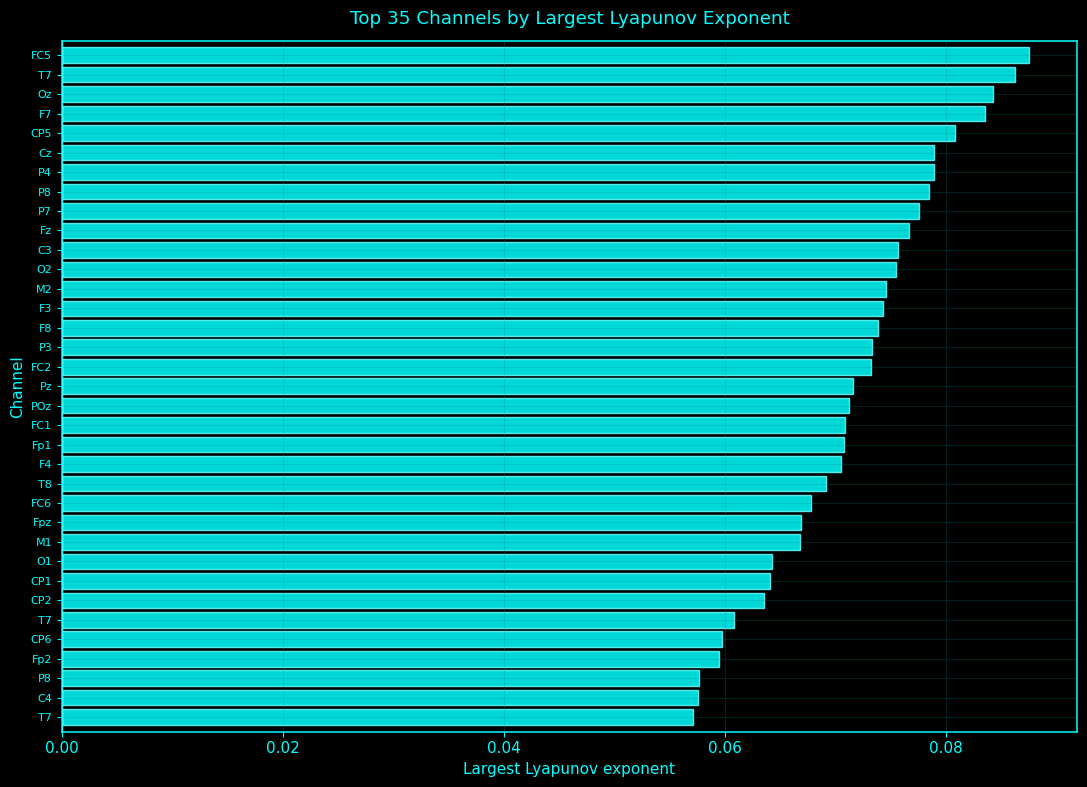

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/analysis_20260604_140620/plots_black_cyan/01_top_lle_ranking_fixed_height_black_cyan.png


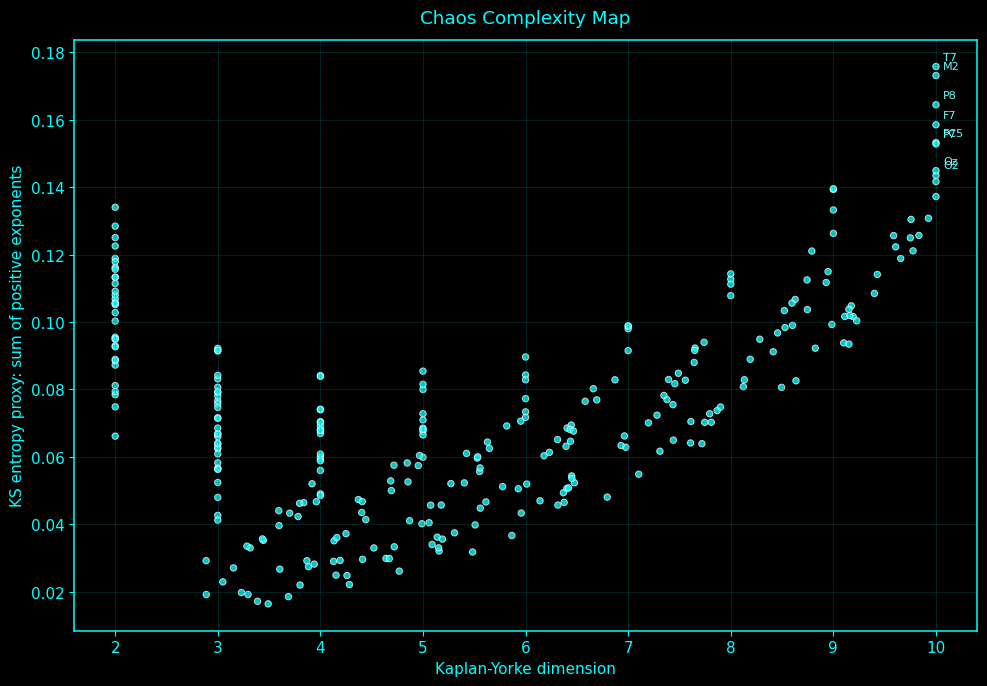

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/analysis_20260604_140620/plots_black_cyan/02_complexity_map_ks_vs_ky_black_cyan.png


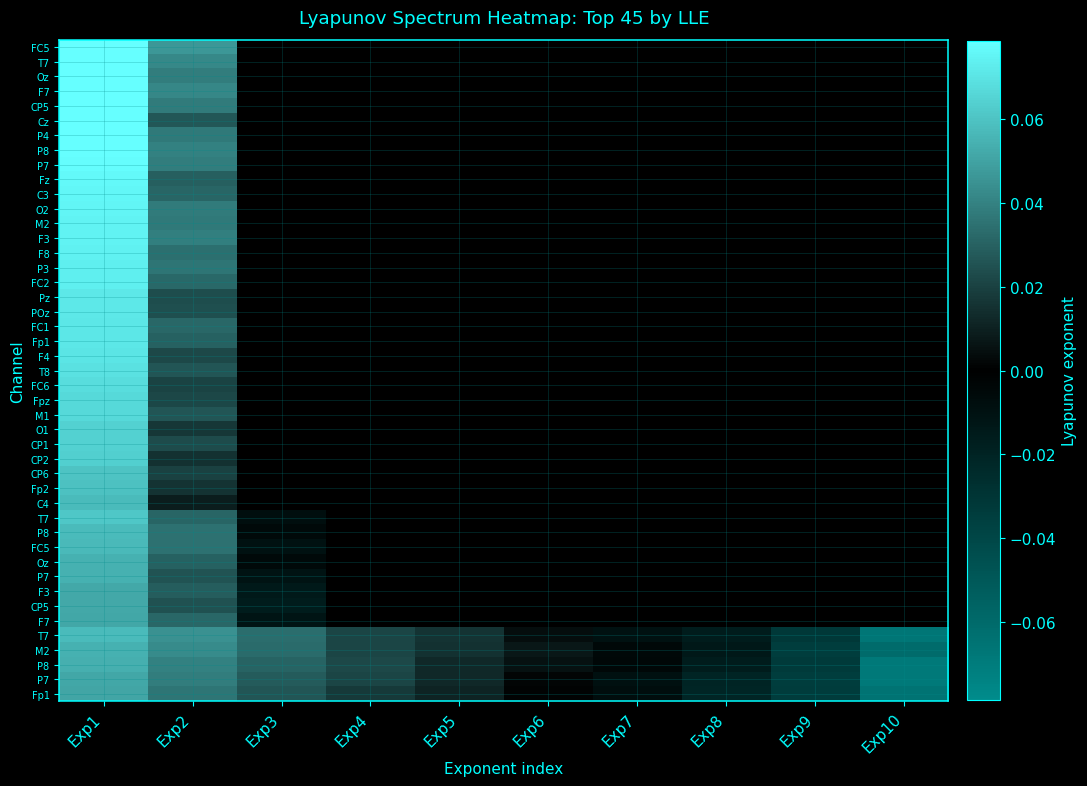

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/analysis_20260604_140620/plots_black_cyan/03_spectrum_heatmap_fixed_height_black_cyan.png


/tmp/ipykernel_639951/360815293.py:688: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(M, axis=0)
/tmp/ipykernel_639951/360815293.py:688: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(M, axis=0)
/tmp/ipykernel_639951/360815293.py:688: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(M, axis=0)
/tmp/ipykernel_639951/360815293.py:688: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(M, axis=0)
/tmp/ipykernel_639951/360815293.py:688: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(M, axis=0)
/tmp/ipykernel_639951/360815293.py:688: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(M, axis=0)
/tmp/ipykernel_639951/360815293.py:688: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(M, axis=0)
/tmp/ipykernel_639951/360815293.py:688: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(M, axis=0)


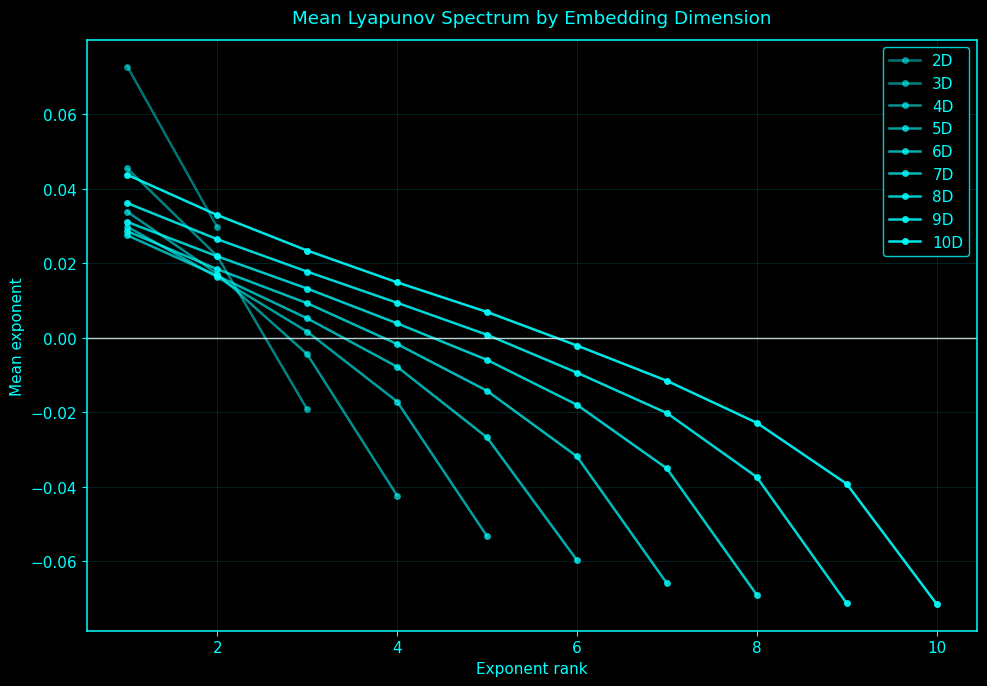

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/analysis_20260604_140620/plots_black_cyan/04_mean_spectrum_by_embedding_dim_black_cyan.png


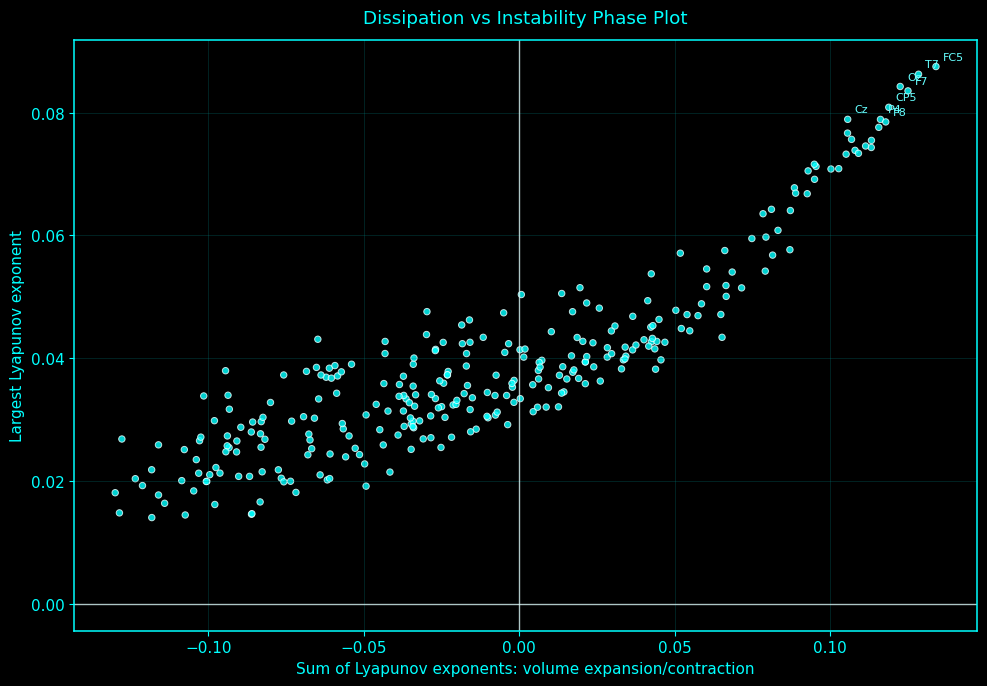

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/analysis_20260604_140620/plots_black_cyan/05_dissipation_vs_instability_black_cyan.png


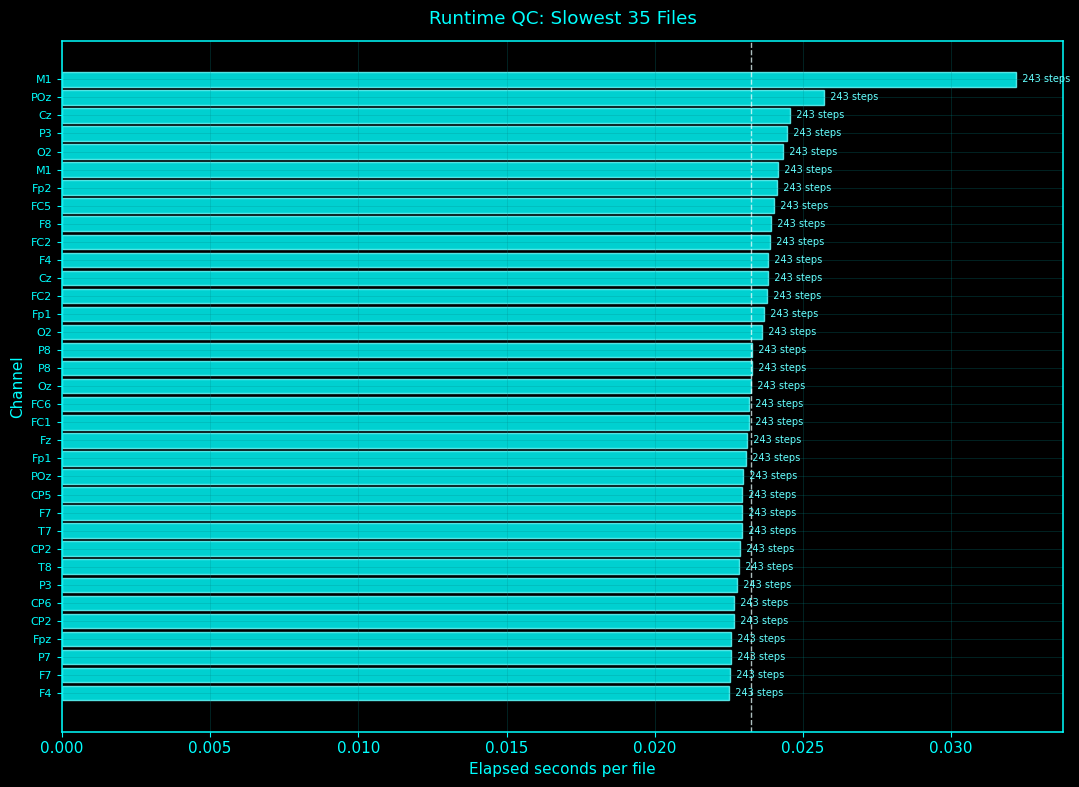

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/analysis_20260604_140620/plots_black_cyan/06_runtime_qc_slowest_files_fixed_black_cyan.png


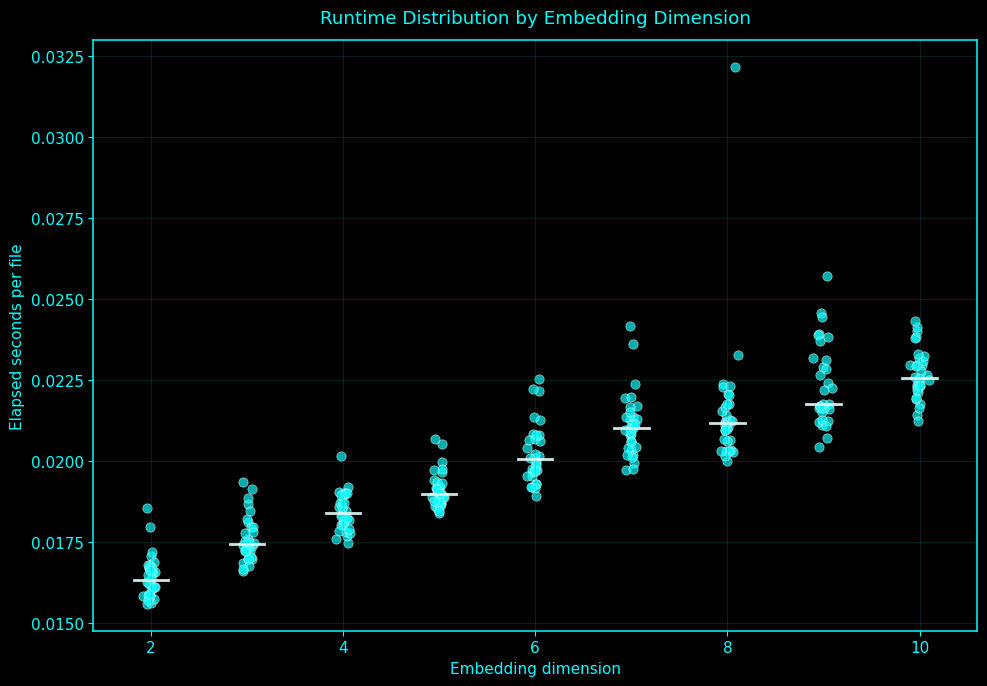

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/analysis_20260604_140620/plots_black_cyan/07_runtime_distribution_by_dimension_black_cyan.png


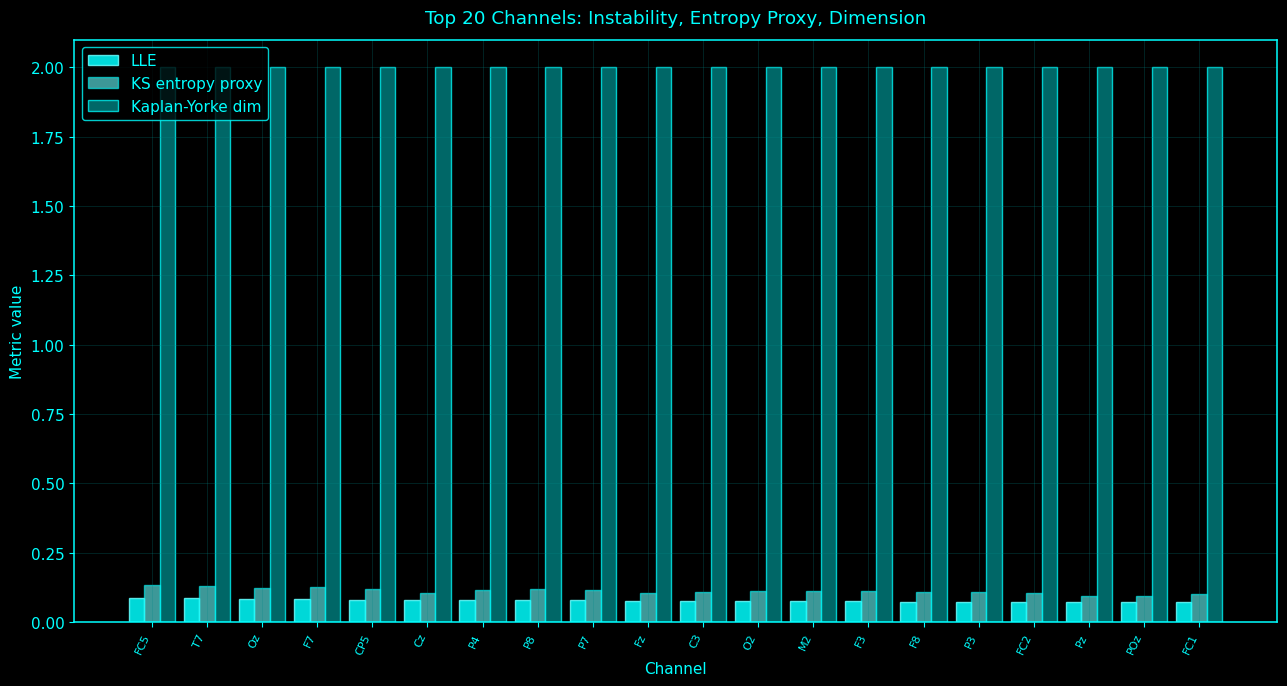

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/analysis_20260604_140620/plots_black_cyan/08_top_channels_expert_summary_black_cyan.png


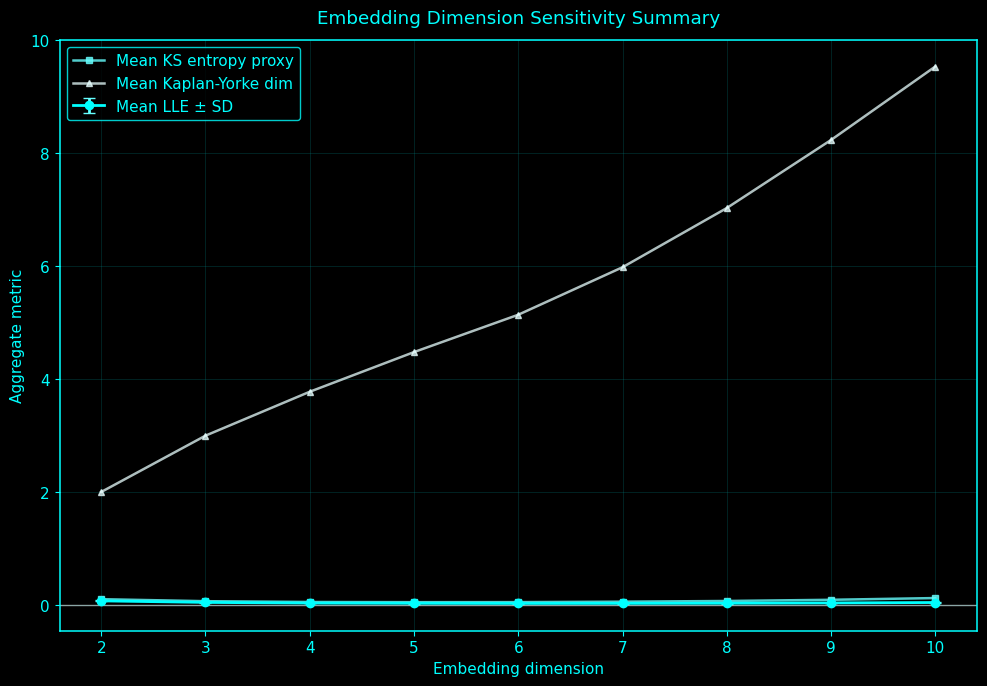

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/analysis_20260604_140620/plots_black_cyan/09_embedding_dimension_summary_black_cyan.png


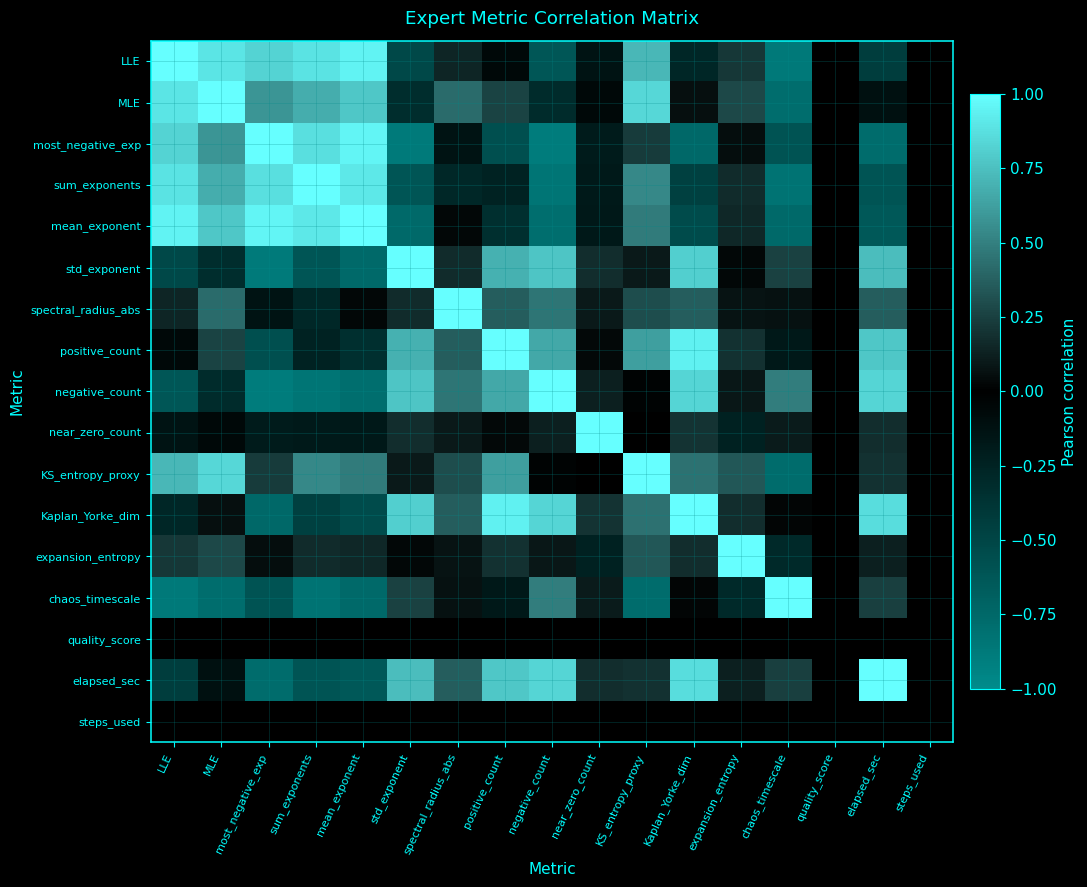

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/analysis_20260604_140620/plots_black_cyan/10_metric_correlation_matrix_black_cyan.png


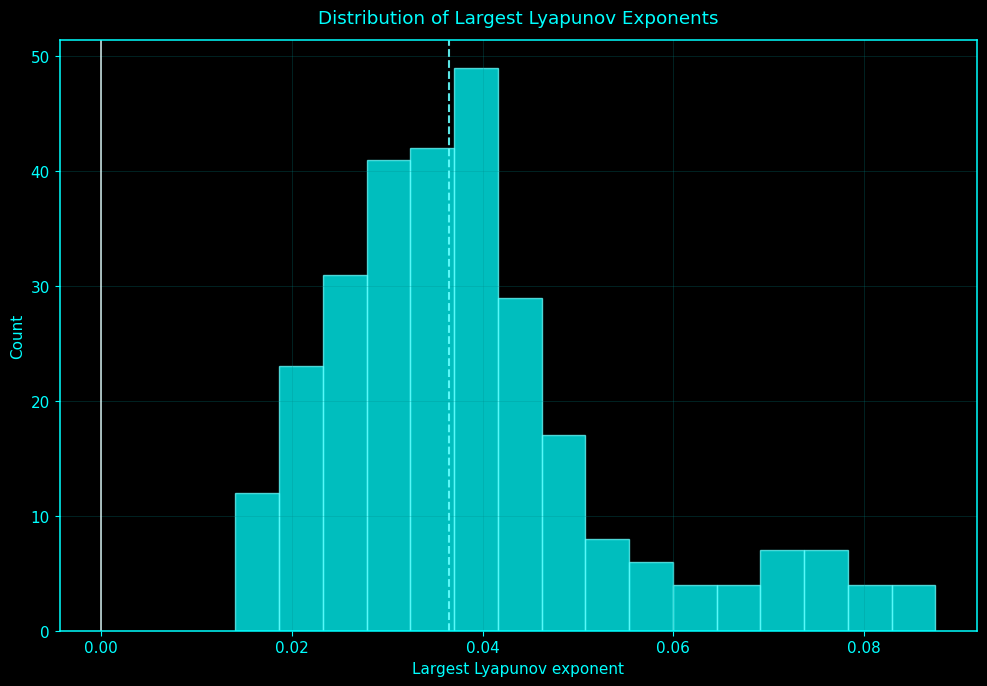

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/analysis_20260604_140620/plots_black_cyan/11_lle_distribution_black_cyan.png


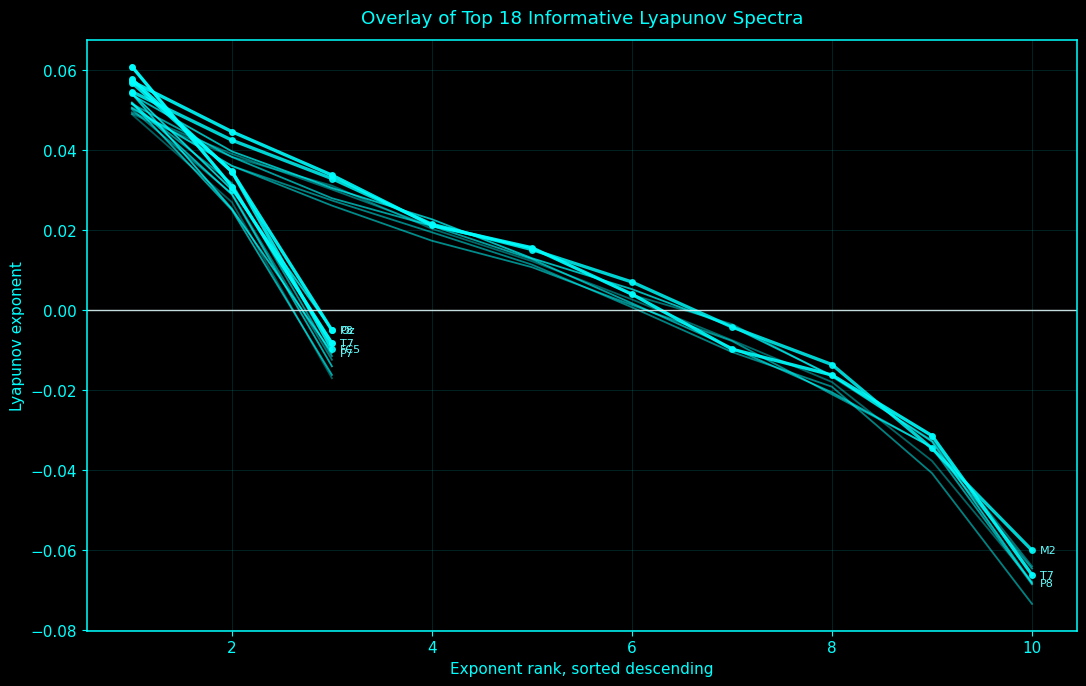

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/analysis_20260604_140620/plots_black_cyan/12_top_spectra_overlay_no_duplicate_individual_lines_black_cyan.png


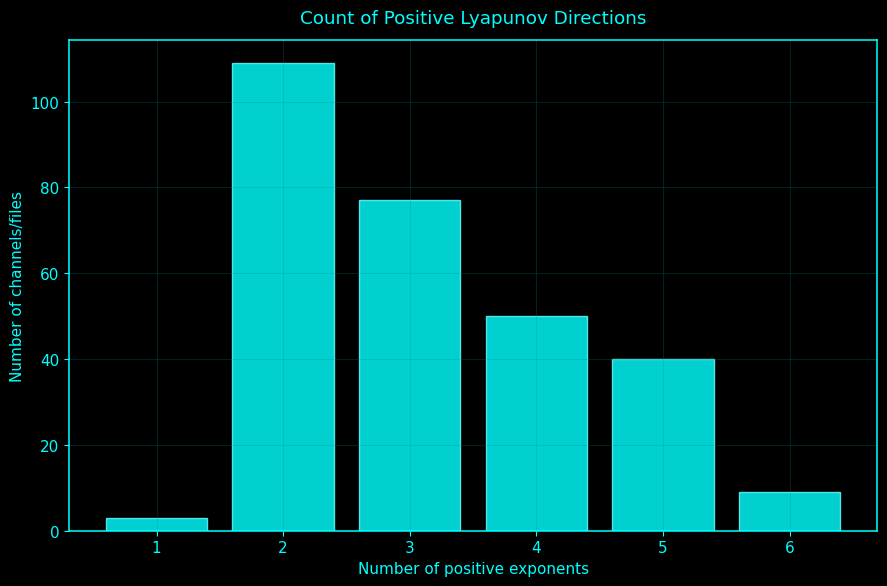

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/analysis_20260604_140620/plots_black_cyan/13_positive_exponent_count_black_cyan.png

EXPERT LYAPUNOV ANALYSIS SUMMARY
Successful files: 288
Errored files: 1

Top 10 by Largest Lyapunov Exponent:
channel  embedding_dimension      LLE  KS_entropy_proxy  Kaplan_Yorke_dim  positive_count  sum_exponents  quality_score
    FC5                  2.0 0.087490          0.134036               2.0             2.0       0.134036      21.320072
     T7                  2.0 0.086236          0.128436               2.0             2.0       0.128436      21.320072
     Oz                  2.0 0.084242          0.122535               2.0             2.0       0.122535      21.320072
     F7                  2.0 0.083525          0.125044               2.0             2.0       0.125044      21.320072
    CP5                  2.0 0.080853          0.118862               2.0             2.0       0.118862      21.320072


In [6]:
import os
import glob
import re
import time
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

try:
    from IPython.display import display
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    _HAVE_IPYTHON_DISPLAY = False

try:
    from scipy.spatial import cKDTree as KDTree
    _HAVE_KDTREE = True
except Exception:
    KDTree = None
    _HAVE_KDTREE = False


CYAN = "#00FFFF"
CYAN_SOFT = "#66FFFF"
CYAN_DIM = "#008B8B"
WHITE = "#E8FFFF"
GRAY = "#445555"
BLACK = "#000000"

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [CYAN_DIM, BLACK, CYAN_SOFT],
    N=256,
)

SHOW_PLOTS_IN_NOTEBOOK = True
SAVE_PLOTS_TO_DISK = True

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "axes.edgecolor": CYAN,
    "axes.labelcolor": CYAN,
    "xtick.color": CYAN,
    "ytick.color": CYAN,
    "text.color": CYAN,
    "grid.color": CYAN_DIM,
    "grid.alpha": 0.25,
    "axes.titlecolor": CYAN,
    "legend.facecolor": BLACK,
    "legend.edgecolor": CYAN,
    "legend.labelcolor": CYAN,
    "font.size": 11,
})


def _delay_embed_1d(x: np.ndarray, emb_dim: int, tau: int) -> np.ndarray:
    x = np.asarray(x, dtype=float).reshape(-1)
    n = x.shape[0]
    n_eff = n - (emb_dim - 1) * tau

    if n_eff <= 1:
        raise ValueError("Time series too short for requested embedding.")

    return np.column_stack([x[i:i + n_eff] for i in range(0, emb_dim * tau, tau)])


def _maybe_fast_subsample(X, dt, max_points=None):
    if max_points is None or X.shape[0] <= max_points:
        return X, dt, 1

    step = int(np.ceil(X.shape[0] / max_points))
    return X[::step], dt * step, step


def lyapunov_spectrum_from_trajectory(
    X: np.ndarray,
    k_neighbors: int = 25,
    theiler: int = 10,
    stride: int = 1,
    dt: float = 1.0,
    rcond=None,
    max_steps=None,
    query_extra: int = 80,
    chunk_size: int = 1024,
    random_seed: int = 0,
):
    X = np.asarray(X, dtype=float)

    if X.ndim != 2:
        raise ValueError("X must be 2D: (N, D).")

    n, d = X.shape

    if n < 5:
        raise ValueError("Trajectory too short.")

    X0 = X[:-1]
    X1 = X[1:]
    n0 = X0.shape[0]

    if n0 < max(d + 2, k_neighbors + 2):
        raise ValueError(
            f"Trajectory too short for dimension={d} and k_neighbors={k_neighbors}."
        )

    anchor_idx = np.arange(0, n0 - 1, stride)

    if anchor_idx.size == 0:
        raise ValueError("No anchor points available. Try lowering stride.")

    if max_steps is not None and anchor_idx.size > max_steps:
        rng = np.random.default_rng(random_seed)
        anchor_idx = np.sort(rng.choice(anchor_idx, size=max_steps, replace=False))

    Q = np.eye(d)
    sums = np.zeros(d, dtype=float)
    used = 0

    tree = KDTree(X0) if _HAVE_KDTREE else None

    if tree is not None:
        qk = min(
            n0,
            max(
                k_neighbors + query_extra,
                k_neighbors * 4 + 2 * theiler + 5,
                d + query_extra,
            ),
        )

        for start in range(0, anchor_idx.size, chunk_size):
            inds = anchor_idx[start:start + chunk_size]
            points = X0[inds]

            try:
                _, all_nbrs = tree.query(points, k=qk, workers=-1)
            except TypeError:
                _, all_nbrs = tree.query(points, k=qk)

            all_nbrs = np.asarray(all_nbrs)

            if all_nbrs.ndim == 1:
                all_nbrs = all_nbrs[:, None]

            for row, i in zip(all_nbrs, inds):
                row = np.asarray(row)

                nbrs = row[
                    (row >= 0)
                    & (row < n0 - 1)
                    & (np.abs(row - i) > theiler)
                ]

                if nbrs.size < max(d + 1, k_neighbors):
                    continue

                nbrs = nbrs[:k_neighbors]

                A = X0[nbrs] - X0[i]
                B = X1[nbrs] - X1[i]

                try:
                    JT, *_ = np.linalg.lstsq(A, B, rcond=rcond)
                    J = JT.T
                except np.linalg.LinAlgError:
                    continue

                Z = J @ Q
                Q, R = np.linalg.qr(Z)

                diag = np.abs(np.diag(R))
                diag[diag == 0] = np.finfo(float).tiny

                sums += np.log(diag)
                used += 1

    else:
        print("WARNING: scipy cKDTree not available. Using slower numpy fallback.", flush=True)

        for i in anchor_idx:
            diffs = X0 - X0[i]
            d2 = np.einsum("ij,ij->i", diffs, diffs)

            lo = max(0, i - theiler)
            hi = min(n0, i + theiler + 1)
            d2[lo:hi] = np.inf
            d2[n0 - 1:] = np.inf

            kk = min(
                n0,
                max(
                    k_neighbors + query_extra,
                    k_neighbors * 4 + 2 * theiler + 5,
                    d + query_extra,
                ),
            )

            cand = np.argpartition(d2, kk - 1)[:kk]
            cand = cand[np.argsort(d2[cand])]

            nbrs = cand[np.isfinite(d2[cand])][:k_neighbors]

            if nbrs.size < max(d + 1, k_neighbors):
                continue

            A = X0[nbrs] - X0[i]
            B = X1[nbrs] - X1[i]

            try:
                JT, *_ = np.linalg.lstsq(A, B, rcond=rcond)
                J = JT.T
            except np.linalg.LinAlgError:
                continue

            Z = J @ Q
            Q, R = np.linalg.qr(Z)

            diag = np.abs(np.diag(R))
            diag[diag == 0] = np.finfo(float).tiny

            sums += np.log(diag)
            used += 1

    if used == 0:
        raise ValueError(
            "No usable steps. Try lowering theiler, lowering k_neighbors, "
            "lowering stride, increasing MAX_STEPS_PER_FILE, or inspecting the data."
        )

    exps = sums / (used * dt)
    return exps, used


def infer_embedding_dim_from_name(stem: str, X: np.ndarray) -> int:
    m = re.match(r"^(\d+)dembedded_", stem)

    if m:
        return int(m.group(1))

    if X.ndim == 2:
        return int(X.shape[1])

    return np.nan


def infer_channel_name_from_stem(stem: str) -> str:
    if "dembedded_" in stem:
        return stem.split("dembedded_", 1)[1]

    return stem


def gather_embedding_files(base_dir: str):
    search_dirs = [
        os.path.join(base_dir, "embedding_data", "2dembedding_data"),
        os.path.join(base_dir, "embedding_data", "3dembedding_data"),
        os.path.join(base_dir, "embedding_data", "embeddings_4to10"),
    ]

    all_files = []
    existing_dirs = []

    for d in search_dirs:
        if os.path.isdir(d):
            existing_dirs.append(d)
            all_files.extend(sorted(glob.glob(os.path.join(d, "*.npy"))))

    return existing_dirs, sorted(all_files)


def save_checkpoint(records, out_csv):
    base_columns = [
        "file",
        "stem",
        "path",
        "source_dir",
        "channel",
        "embedding_dimension",
        "status",
        "error",
        "n_samples_original",
        "n_samples_used",
        "state_dim",
        "subsample_step",
        "dt_used",
        "steps_used",
        "elapsed_sec",
    ]

    df = pd.DataFrame(records)

    for col in base_columns:
        if col not in df.columns:
            df[col] = np.nan

    other_cols = [c for c in df.columns if c not in base_columns]

    exp_cols = sorted(
        [c for c in other_cols if c.startswith("Exp")],
        key=lambda x: int(x.replace("Exp", "")) if x.replace("Exp", "").isdigit() else 10**9,
    )

    non_exp_other_cols = [c for c in other_cols if c not in exp_cols]

    df = df[base_columns + non_exp_other_cols + exp_cols]
    df.to_csv(out_csv, index=False)

    return df


def get_exp_cols(df):
    return sorted(
        [c for c in df.columns if c.startswith("Exp")],
        key=lambda x: int(x.replace("Exp", "")) if x.replace("Exp", "").isdigit() else 10**9,
    )


def kaplan_yorke_dimension(exps):
    exps = np.asarray(exps, dtype=float)
    exps = exps[np.isfinite(exps)]

    if exps.size == 0:
        return np.nan

    lam = np.sort(exps)[::-1]
    csum = np.cumsum(lam)

    if csum[0] < 0:
        return 0.0

    nonneg = np.where(csum >= 0)[0]

    if nonneg.size == 0:
        return np.nan

    j_idx = nonneg[-1]
    j = j_idx + 1

    if j >= lam.size:
        return float(lam.size)

    denom = abs(lam[j])

    if denom == 0 or not np.isfinite(denom):
        return float(j)

    return float(j + csum[j_idx] / denom)


def spectral_entropy_from_positive_exps(exps):
    exps = np.asarray(exps, dtype=float)
    pos = exps[np.isfinite(exps) & (exps > 0)]

    if pos.size <= 1:
        return 0.0

    p = pos / np.sum(pos)
    return float(-np.sum(p * np.log(p)) / np.log(pos.size))


def add_expert_metrics(df):
    df = df.copy()
    exp_cols = get_exp_cols(df)

    metric_rows = []

    for _, row in df.iterrows():
        exps = row[exp_cols].to_numpy(dtype=float) if len(exp_cols) else np.array([])
        exps = exps[np.isfinite(exps)]

        if row.get("status", "") != "ok" or exps.size == 0:
            metric_rows.append({
                "LLE": np.nan,
                "MLE": np.nan,
                "most_negative_exp": np.nan,
                "sum_exponents": np.nan,
                "mean_exponent": np.nan,
                "std_exponent": np.nan,
                "spectral_radius_abs": np.nan,
                "positive_count": np.nan,
                "negative_count": np.nan,
                "near_zero_count": np.nan,
                "KS_entropy_proxy": np.nan,
                "Kaplan_Yorke_dim": np.nan,
                "expansion_entropy": np.nan,
                "chaos_timescale": np.nan,
                "hyperchaos_flag": False,
                "dissipative_flag": False,
                "reliable_steps_flag": False,
                "quality_score": np.nan,
            })
            continue

        sorted_exps = np.sort(exps)[::-1]

        lle = float(np.max(exps))
        mle = float(np.mean(sorted_exps[:min(3, len(sorted_exps))]))
        most_negative = float(np.min(exps))
        sum_exps = float(np.sum(exps))
        mean_exp = float(np.mean(exps))
        std_exp = float(np.std(exps))
        spectral_radius_abs = float(np.max(np.abs(exps)))

        eps_zero = 1e-3
        positive_count = int(np.sum(exps > eps_zero))
        negative_count = int(np.sum(exps < -eps_zero))
        near_zero_count = int(np.sum(np.abs(exps) <= eps_zero))

        ks_entropy_proxy = float(np.sum(exps[exps > 0])) if np.any(exps > 0) else 0.0
        ky_dim = kaplan_yorke_dimension(exps)
        expansion_entropy = spectral_entropy_from_positive_exps(exps)

        chaos_timescale = float(1.0 / lle) if lle > 0 else np.nan

        hyperchaos_flag = positive_count >= 2
        dissipative_flag = sum_exps < 0

        steps_used = row.get("steps_used", np.nan)
        state_dim = row.get("state_dim", np.nan)

        reliable_steps_flag = (
            np.isfinite(steps_used)
            and np.isfinite(state_dim)
            and steps_used >= max(100, 20 * state_dim)
        )

        subsample_step = row.get("subsample_step", 1)

        if not np.isfinite(subsample_step) or subsample_step <= 0:
            subsample_step = 1

        if np.isfinite(steps_used) and np.isfinite(state_dim):
            step_component = min(1.0, steps_used / max(100, 20 * state_dim))
            subsample_component = 1.0 / np.sqrt(subsample_step)
            quality_score = float(100 * step_component * subsample_component)
        else:
            quality_score = np.nan

        metric_rows.append({
            "LLE": lle,
            "MLE": mle,
            "most_negative_exp": most_negative,
            "sum_exponents": sum_exps,
            "mean_exponent": mean_exp,
            "std_exponent": std_exp,
            "spectral_radius_abs": spectral_radius_abs,
            "positive_count": positive_count,
            "negative_count": negative_count,
            "near_zero_count": near_zero_count,
            "KS_entropy_proxy": ks_entropy_proxy,
            "Kaplan_Yorke_dim": ky_dim,
            "expansion_entropy": expansion_entropy,
            "chaos_timescale": chaos_timescale,
            "hyperchaos_flag": hyperchaos_flag,
            "dissipative_flag": dissipative_flag,
            "reliable_steps_flag": reliable_steps_flag,
            "quality_score": quality_score,
        })

    metrics = pd.DataFrame(metric_rows, index=df.index)
    return pd.concat([df, metrics], axis=1)


def style_axis(ax, title=None, xlabel=None, ylabel=None):
    ax.set_facecolor(BLACK)

    for spine in ax.spines.values():
        spine.set_color(CYAN)
        spine.set_linewidth(1.1)

    ax.tick_params(axis="x", colors=CYAN, labelcolor=CYAN)
    ax.tick_params(axis="y", colors=CYAN, labelcolor=CYAN)

    ax.xaxis.label.set_color(CYAN)
    ax.yaxis.label.set_color(CYAN)

    if title is not None:
        ax.set_title(title, color=CYAN, pad=12)

    if xlabel is not None:
        ax.set_xlabel(xlabel, color=CYAN)

    if ylabel is not None:
        ax.set_ylabel(ylabel, color=CYAN)

    ax.grid(True, color=CYAN_DIM, alpha=0.25, linewidth=0.7)


def save_fig(fig, path):
    fig.tight_layout()

    if SAVE_PLOTS_TO_DISK:
        fig.savefig(path, dpi=220, facecolor=BLACK, bbox_inches="tight")

    if SHOW_PLOTS_IN_NOTEBOOK and _HAVE_IPYTHON_DISPLAY:
        display(fig)

    plt.close(fig)


def _safe_filename(s):
    s = str(s)
    s = re.sub(r"[^a-zA-Z0-9_\-\.]+", "_", s)
    return s[:180]


def _short_labels(series, max_len=22):
    labels = []
    for s in series.astype(str).to_numpy():
        labels.append(s if len(s) <= max_len else s[:max_len - 1] + "…")
    return np.array(labels)


def plot_lle_rank(df, out_dir, top_n=35):
    ok = df[df["status"] == "ok"].copy()
    ok = ok[np.isfinite(ok["LLE"])]

    if ok.empty:
        return None

    ok = ok.sort_values("LLE", ascending=False).head(top_n)
    ok = ok.sort_values("LLE", ascending=True)

    labels = _short_labels(ok["channel"], max_len=24)
    values = ok["LLE"].to_numpy()

    fig, ax = plt.subplots(figsize=(11, 8))

    y = np.arange(len(ok))
    ax.barh(y, values, color=CYAN, edgecolor=CYAN_SOFT, alpha=0.85)
    ax.axvline(0, color=WHITE, linewidth=1.0, alpha=0.8)

    ax.set_yticks(y)
    ax.set_yticklabels(labels, color=CYAN, fontsize=8)

    title = f"Top {len(ok)} Channels by Largest Lyapunov Exponent"

    style_axis(
        ax,
        title=title,
        xlabel="Largest Lyapunov exponent",
        ylabel="Channel",
    )

    ax.margins(y=0.01)

    path = os.path.join(out_dir, "01_top_lle_ranking_fixed_height_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_ks_entropy_vs_dimension(df, out_dir):
    ok = df[df["status"] == "ok"].copy()
    ok = ok[
        np.isfinite(ok["KS_entropy_proxy"])
        & np.isfinite(ok["Kaplan_Yorke_dim"])
        & np.isfinite(ok["quality_score"])
    ]

    if ok.empty:
        return None

    fig, ax = plt.subplots(figsize=(10, 7))

    sizes = np.clip(ok["quality_score"].to_numpy(), 18, 180)

    ax.scatter(
        ok["Kaplan_Yorke_dim"],
        ok["KS_entropy_proxy"],
        s=sizes,
        c=CYAN,
        edgecolors=WHITE,
        linewidths=0.7,
        alpha=0.78,
    )

    for _, r in ok.sort_values("KS_entropy_proxy", ascending=False).head(8).iterrows():
        ax.annotate(
            str(r["channel"])[:22],
            (r["Kaplan_Yorke_dim"], r["KS_entropy_proxy"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
            color=CYAN_SOFT,
        )

    style_axis(
        ax,
        title="Chaos Complexity Map",
        xlabel="Kaplan-Yorke dimension",
        ylabel="KS entropy proxy: sum of positive exponents",
    )

    path = os.path.join(out_dir, "02_complexity_map_ks_vs_ky_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_spectrum_heatmap(df, out_dir, max_rows=45):
    ok = df[df["status"] == "ok"].copy()
    exp_cols = get_exp_cols(ok)

    if ok.empty or len(exp_cols) == 0:
        return None

    ok = ok[np.isfinite(ok["LLE"])].copy()

    if ok.empty:
        return None

    ok = ok.sort_values("LLE", ascending=False).head(max_rows)
    ok = ok.sort_values(["embedding_dimension", "LLE"], ascending=[True, False])

    M = ok[exp_cols].to_numpy(dtype=float)

    if M.size == 0 or np.all(~np.isfinite(M)):
        return None

    labels = _short_labels(ok["channel"], max_len=24)

    finite_abs = np.abs(M[np.isfinite(M)])
    vmax = np.percentile(finite_abs, 95) if finite_abs.size else 1.0
    vmax = max(vmax, 1e-9)

    fig, ax = plt.subplots(figsize=(11, 8))

    im = ax.imshow(
        M,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_DIVERGING_CMAP,
        vmin=-vmax,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(exp_cols)))
    ax.set_xticklabels(exp_cols, rotation=45, ha="right", color=CYAN)

    ax.set_yticks(np.arange(len(ok)))
    ax.set_yticklabels(labels, color=CYAN, fontsize=7)

    style_axis(
        ax,
        title=f"Lyapunov Spectrum Heatmap: Top {len(ok)} by LLE",
        xlabel="Exponent index",
        ylabel="Channel",
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=CYAN)
    plt.setp(cbar.ax.get_yticklabels(), color=CYAN)
    cbar.outline.set_edgecolor(CYAN)
    cbar.set_label("Lyapunov exponent", color=CYAN)

    path = os.path.join(out_dir, "03_spectrum_heatmap_fixed_height_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_mean_spectrum_by_embedding_dim(df, out_dir):
    ok = df[df["status"] == "ok"].copy()
    exp_cols = get_exp_cols(ok)

    if ok.empty or len(exp_cols) == 0:
        return None

    dims = sorted([d for d in ok["embedding_dimension"].dropna().unique()])

    if len(dims) == 0:
        return None

    fig, ax = plt.subplots(figsize=(10, 7))

    max_dim = max(dims)

    for dim in dims:
        sub = ok[ok["embedding_dimension"] == dim]
        M = sub[exp_cols].to_numpy(dtype=float)

        if M.size == 0:
            continue

        mean = np.nanmean(M, axis=0)
        x = np.arange(1, len(mean) + 1)

        valid = np.isfinite(mean)
        if valid.sum() < 2:
            continue

        ax.plot(
            x[valid],
            mean[valid],
            marker="o",
            linewidth=1.8,
            markersize=4,
            color=CYAN,
            alpha=0.35 + 0.55 * (dim / max_dim),
            label=f"{int(dim)}D",
        )

    ax.axhline(0, color=WHITE, linewidth=1.0, alpha=0.8)

    style_axis(
        ax,
        title="Mean Lyapunov Spectrum by Embedding Dimension",
        xlabel="Exponent rank",
        ylabel="Mean exponent",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(CYAN)

    path = os.path.join(out_dir, "04_mean_spectrum_by_embedding_dim_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_dissipation_vs_instability(df, out_dir):
    ok = df[df["status"] == "ok"].copy()
    ok = ok[np.isfinite(ok["sum_exponents"]) & np.isfinite(ok["LLE"])]

    if ok.empty:
        return None

    fig, ax = plt.subplots(figsize=(10, 7))

    ax.scatter(
        ok["sum_exponents"],
        ok["LLE"],
        s=np.clip(ok["quality_score"].fillna(40).to_numpy(), 20, 180),
        c=CYAN,
        edgecolors=WHITE,
        linewidths=0.7,
        alpha=0.82,
    )

    ax.axhline(0, color=WHITE, linewidth=1.0, alpha=0.75)
    ax.axvline(0, color=WHITE, linewidth=1.0, alpha=0.75)

    for _, r in ok.sort_values("LLE", ascending=False).head(8).iterrows():
        ax.annotate(
            str(r["channel"])[:22],
            (r["sum_exponents"], r["LLE"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
            color=CYAN_SOFT,
        )

    style_axis(
        ax,
        title="Dissipation vs Instability Phase Plot",
        xlabel="Sum of Lyapunov exponents: volume expansion/contraction",
        ylabel="Largest Lyapunov exponent",
    )

    path = os.path.join(out_dir, "05_dissipation_vs_instability_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_runtime_qc_sorted(df, out_dir, top_n=35):
    ok = df[df["status"] == "ok"].copy()
    ok = ok[np.isfinite(ok["elapsed_sec"])]

    if ok.empty:
        return None

    ok = ok.sort_values("elapsed_sec", ascending=False).head(top_n)
    ok = ok.sort_values("elapsed_sec", ascending=True)

    labels = _short_labels(ok["channel"], max_len=24)
    y = np.arange(len(ok))

    fig, ax = plt.subplots(figsize=(11, 8))

    ax.barh(
        y,
        ok["elapsed_sec"].to_numpy(),
        color=CYAN,
        edgecolor=CYAN_SOFT,
        alpha=0.82,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(labels, color=CYAN, fontsize=8)

    median_time = ok["elapsed_sec"].median()
    ax.axvline(median_time, color=WHITE, linewidth=1.0, alpha=0.75, linestyle="--")

    for yi, (_, r) in zip(y, ok.iterrows()):
        steps = r.get("steps_used", np.nan)
        if np.isfinite(steps):
            ax.text(
                r["elapsed_sec"],
                yi,
                f"  {int(steps)} steps",
                va="center",
                ha="left",
                color=CYAN_SOFT,
                fontsize=7,
            )

    style_axis(
        ax,
        title=f"Runtime QC: Slowest {len(ok)} Files",
        xlabel="Elapsed seconds per file",
        ylabel="Channel",
    )

    path = os.path.join(out_dir, "06_runtime_qc_slowest_files_fixed_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_runtime_distribution_by_dimension(df, out_dir):
    ok = df[df["status"] == "ok"].copy()
    ok = ok[
        np.isfinite(ok["elapsed_sec"])
        & np.isfinite(ok["embedding_dimension"])
    ]

    if ok.empty:
        return None

    dims = sorted(ok["embedding_dimension"].dropna().unique())
    fig, ax = plt.subplots(figsize=(10, 7))

    rng = np.random.default_rng(0)

    for dim in dims:
        sub = ok[ok["embedding_dimension"] == dim]
        x = np.full(len(sub), dim, dtype=float)
        jitter = rng.normal(0, 0.035, size=len(sub))
        ax.scatter(
            x + jitter,
            sub["elapsed_sec"],
            s=45,
            c=CYAN,
            edgecolors=WHITE,
            linewidths=0.5,
            alpha=0.68,
        )

        median_val = sub["elapsed_sec"].median()
        ax.plot(
            [dim - 0.18, dim + 0.18],
            [median_val, median_val],
            color=WHITE,
            linewidth=2.0,
            alpha=0.9,
        )

    style_axis(
        ax,
        title="Runtime Distribution by Embedding Dimension",
        xlabel="Embedding dimension",
        ylabel="Elapsed seconds per file",
    )

    path = os.path.join(out_dir, "07_runtime_distribution_by_dimension_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_channel_expert_summary(df, out_dir, top_n=20):
    ok = df[df["status"] == "ok"].copy()
    ok = ok[np.isfinite(ok["LLE"])]

    if ok.empty:
        return None

    top = ok.sort_values("LLE", ascending=False).head(top_n).copy()
    labels = _short_labels(top["channel"], max_len=18)

    x = np.arange(len(top))
    width = 0.28

    fig, ax = plt.subplots(figsize=(13, 7))

    ax.bar(
        x - width,
        top["LLE"],
        width,
        label="LLE",
        color=CYAN,
        edgecolor=CYAN_SOFT,
        alpha=0.85,
    )

    ax.bar(
        x,
        top["KS_entropy_proxy"],
        width,
        label="KS entropy proxy",
        color=CYAN_SOFT,
        edgecolor=CYAN,
        alpha=0.60,
    )

    ax.bar(
        x + width,
        top["Kaplan_Yorke_dim"],
        width,
        label="Kaplan-Yorke dim",
        color=CYAN_DIM,
        edgecolor=CYAN,
        alpha=0.75,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=65, ha="right", color=CYAN, fontsize=8)

    style_axis(
        ax,
        title=f"Top {top_n} Channels: Instability, Entropy Proxy, Dimension",
        xlabel="Channel",
        ylabel="Metric value",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(CYAN)

    path = os.path.join(out_dir, "08_top_channels_expert_summary_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_embedding_dimension_summary(df, out_dir):
    ok = df[df["status"] == "ok"].copy()

    needed = ["embedding_dimension", "LLE", "KS_entropy_proxy", "Kaplan_Yorke_dim"]

    for col in needed:
        if col not in ok.columns:
            return None
        ok = ok[pd.to_numeric(ok[col], errors="coerce").notna()]

    if ok.empty:
        return None

    grouped = (
        ok.groupby("embedding_dimension")
        .agg(
            LLE_mean=("LLE", "mean"),
            LLE_std=("LLE", "std"),
            KS_mean=("KS_entropy_proxy", "mean"),
            KY_mean=("Kaplan_Yorke_dim", "mean"),
            n=("file", "count"),
        )
        .reset_index()
        .sort_values("embedding_dimension")
    )

    fig, ax = plt.subplots(figsize=(10, 7))

    ax.errorbar(
        grouped["embedding_dimension"],
        grouped["LLE_mean"],
        yerr=grouped["LLE_std"].fillna(0),
        marker="o",
        linewidth=2,
        markersize=6,
        color=CYAN,
        ecolor=CYAN_SOFT,
        capsize=4,
        label="Mean LLE ± SD",
    )

    ax.plot(
        grouped["embedding_dimension"],
        grouped["KS_mean"],
        marker="s",
        linewidth=1.8,
        markersize=5,
        color=CYAN_SOFT,
        alpha=0.8,
        label="Mean KS entropy proxy",
    )

    ax.plot(
        grouped["embedding_dimension"],
        grouped["KY_mean"],
        marker="^",
        linewidth=1.8,
        markersize=5,
        color=WHITE,
        alpha=0.75,
        label="Mean Kaplan-Yorke dim",
    )

    ax.axhline(0, color=WHITE, linewidth=1.0, alpha=0.6)

    style_axis(
        ax,
        title="Embedding Dimension Sensitivity Summary",
        xlabel="Embedding dimension",
        ylabel="Aggregate metric",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(CYAN)

    path = os.path.join(out_dir, "09_embedding_dimension_summary_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_metric_correlation_matrix(df, out_dir):
    ok = df[df["status"] == "ok"].copy()

    metric_cols = [
        "LLE",
        "MLE",
        "most_negative_exp",
        "sum_exponents",
        "mean_exponent",
        "std_exponent",
        "spectral_radius_abs",
        "positive_count",
        "negative_count",
        "near_zero_count",
        "KS_entropy_proxy",
        "Kaplan_Yorke_dim",
        "expansion_entropy",
        "chaos_timescale",
        "quality_score",
        "elapsed_sec",
        "steps_used",
    ]

    metric_cols = [c for c in metric_cols if c in ok.columns]

    if len(metric_cols) < 3:
        return None

    M = ok[metric_cols].apply(pd.to_numeric, errors="coerce")
    corr = M.corr()

    if corr.empty:
        return None

    fig, ax = plt.subplots(figsize=(11, 9))

    im = ax.imshow(
        corr.to_numpy(),
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_DIVERGING_CMAP,
        vmin=-1,
        vmax=1,
    )

    ax.set_xticks(np.arange(len(metric_cols)))
    ax.set_yticks(np.arange(len(metric_cols)))
    ax.set_xticklabels(metric_cols, rotation=65, ha="right", color=CYAN, fontsize=8)
    ax.set_yticklabels(metric_cols, color=CYAN, fontsize=8)

    style_axis(
        ax,
        title="Expert Metric Correlation Matrix",
        xlabel="Metric",
        ylabel="Metric",
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=CYAN)
    plt.setp(cbar.ax.get_yticklabels(), color=CYAN)
    cbar.outline.set_edgecolor(CYAN)
    cbar.set_label("Pearson correlation", color=CYAN)

    path = os.path.join(out_dir, "10_metric_correlation_matrix_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_lle_distribution(df, out_dir):
    ok = df[df["status"] == "ok"].copy()
    ok = ok[np.isfinite(ok["LLE"])]

    if ok.empty:
        return None

    fig, ax = plt.subplots(figsize=(10, 7))

    ax.hist(
        ok["LLE"].to_numpy(),
        bins=min(40, max(8, int(np.sqrt(len(ok))))),
        color=CYAN,
        edgecolor=CYAN_SOFT,
        alpha=0.75,
    )

    ax.axvline(0, color=WHITE, linewidth=1.2, alpha=0.85)
    ax.axvline(ok["LLE"].median(), color=CYAN_SOFT, linewidth=1.5, linestyle="--", alpha=0.9)

    style_axis(
        ax,
        title="Distribution of Largest Lyapunov Exponents",
        xlabel="Largest Lyapunov exponent",
        ylabel="Count",
    )

    path = os.path.join(out_dir, "11_lle_distribution_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_top_spectra_overlay(df, out_dir, top_n=18, min_exponents=3):
    ok = df[df["status"] == "ok"].copy()
    exp_cols = get_exp_cols(ok)

    if ok.empty or len(exp_cols) == 0:
        return None

    ok = ok[np.isfinite(ok["LLE"])].sort_values("LLE", ascending=False)

    selected_rows = []

    for _, row in ok.iterrows():
        exps = row[exp_cols].to_numpy(dtype=float)
        exps = exps[np.isfinite(exps)]

        if exps.size >= min_exponents:
            selected_rows.append(row)

        if len(selected_rows) >= top_n:
            break

    if len(selected_rows) == 0:
        print(
            "Skipping top spectra overlay: all successful spectra have fewer than "
            f"{min_exponents} exponents, so individual line spectra would be uninformative.",
            flush=True,
        )
        return None

    selected = pd.DataFrame(selected_rows)

    fig, ax = plt.subplots(figsize=(11, 7))

    for rank, (_, row) in enumerate(selected.iterrows(), start=1):
        exps = row[exp_cols].to_numpy(dtype=float)
        exps = exps[np.isfinite(exps)]
        exps_sorted = np.sort(exps)[::-1]
        x = np.arange(1, len(exps_sorted) + 1)

        alpha = max(0.25, 1.0 - 0.035 * rank)
        lw = 2.4 if rank <= 5 else 1.3

        ax.plot(
            x,
            exps_sorted,
            marker="o" if rank <= 6 else None,
            linewidth=lw,
            markersize=4,
            color=CYAN,
            alpha=alpha,
        )

        if rank <= 8:
            ax.text(
                x[-1] + 0.08,
                exps_sorted[-1],
                str(row["channel"])[:18],
                color=CYAN_SOFT,
                fontsize=8,
                va="center",
            )

    ax.axhline(0, color=WHITE, linewidth=1.0, alpha=0.85)

    style_axis(
        ax,
        title=f"Overlay of Top {len(selected)} Informative Lyapunov Spectra",
        xlabel="Exponent rank, sorted descending",
        ylabel="Lyapunov exponent",
    )

    path = os.path.join(out_dir, "12_top_spectra_overlay_no_duplicate_individual_lines_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_positive_exponent_count(df, out_dir):
    ok = df[df["status"] == "ok"].copy()
    ok = ok[np.isfinite(ok["positive_count"])]

    if ok.empty:
        return None

    counts = ok["positive_count"].astype(int).value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.bar(
        counts.index.astype(str),
        counts.values,
        color=CYAN,
        edgecolor=CYAN_SOFT,
        alpha=0.82,
    )

    style_axis(
        ax,
        title="Count of Positive Lyapunov Directions",
        xlabel="Number of positive exponents",
        ylabel="Number of channels/files",
    )

    path = os.path.join(out_dir, "13_positive_exponent_count_black_cyan.png")
    save_fig(fig, path)
    return path


def make_expert_plots(df, analysis_dir):
    plots_dir = os.path.join(analysis_dir, "plots_black_cyan")
    os.makedirs(plots_dir, exist_ok=True)

    paths = []

    plot_functions = [
        plot_lle_rank,
        plot_ks_entropy_vs_dimension,
        plot_spectrum_heatmap,
        plot_mean_spectrum_by_embedding_dim,
        plot_dissipation_vs_instability,
        plot_runtime_qc_sorted,
        plot_runtime_distribution_by_dimension,
        plot_channel_expert_summary,
        plot_embedding_dimension_summary,
        plot_metric_correlation_matrix,
        plot_lle_distribution,
        plot_top_spectra_overlay,
        plot_positive_exponent_count,
    ]

    for fn in plot_functions:
        try:
            p = fn(df, plots_dir)
            if p is not None:
                paths.append(p)
                print(f"Saved plot: {p}", flush=True)
        except Exception as e:
            print(f"Plot failed: {fn.__name__} | {type(e).__name__}: {e}", flush=True)

    return paths


def save_expert_tables(df, analysis_dir):
    os.makedirs(analysis_dir, exist_ok=True)

    enriched_csv = os.path.join(analysis_dir, "lyap_spectrum_with_expert_metrics.csv")
    df.to_csv(enriched_csv, index=False)

    ok = df[df["status"] == "ok"].copy()

    top_lle_csv = os.path.join(analysis_dir, "top_channels_by_LLE.csv")
    top_complexity_csv = os.path.join(analysis_dir, "top_channels_by_KS_entropy_proxy.csv")
    hyperchaos_csv = os.path.join(analysis_dir, "hyperchaotic_candidates.csv")
    qc_csv = os.path.join(analysis_dir, "quality_control_flags.csv")
    dim_summary_csv = os.path.join(analysis_dir, "embedding_dimension_summary.csv")

    if not ok.empty:
        ok.sort_values("LLE", ascending=False).to_csv(top_lle_csv, index=False)
        ok.sort_values("KS_entropy_proxy", ascending=False).to_csv(top_complexity_csv, index=False)
        ok[ok["hyperchaos_flag"] == True].sort_values("positive_count", ascending=False).to_csv(
            hyperchaos_csv,
            index=False,
        )

        qc_cols = [
            "file",
            "channel",
            "embedding_dimension",
            "n_samples_original",
            "n_samples_used",
            "subsample_step",
            "steps_used",
            "elapsed_sec",
            "quality_score",
            "reliable_steps_flag",
            "status",
            "error",
        ]
        qc_cols = [c for c in qc_cols if c in ok.columns]
        ok[qc_cols].sort_values("quality_score", ascending=True).to_csv(qc_csv, index=False)

        summary = (
            ok.groupby("embedding_dimension")
            .agg(
                n_files=("file", "count"),
                LLE_mean=("LLE", "mean"),
                LLE_median=("LLE", "median"),
                LLE_std=("LLE", "std"),
                KS_entropy_mean=("KS_entropy_proxy", "mean"),
                KY_dim_mean=("Kaplan_Yorke_dim", "mean"),
                positive_count_mean=("positive_count", "mean"),
                sum_exponents_mean=("sum_exponents", "mean"),
                quality_score_mean=("quality_score", "mean"),
                elapsed_sec_mean=("elapsed_sec", "mean"),
            )
            .reset_index()
            .sort_values("embedding_dimension")
        )
        summary.to_csv(dim_summary_csv, index=False)

    return {
        "enriched_csv": enriched_csv,
        "top_lle_csv": top_lle_csv,
        "top_complexity_csv": top_complexity_csv,
        "hyperchaos_csv": hyperchaos_csv,
        "qc_csv": qc_csv,
        "dim_summary_csv": dim_summary_csv,
    }


def print_expert_console_summary(df):
    ok = df[df["status"] == "ok"].copy()

    print("\n" + "=" * 80, flush=True)
    print("EXPERT LYAPUNOV ANALYSIS SUMMARY", flush=True)
    print("=" * 80, flush=True)

    if ok.empty:
        print("No successful files to summarize.", flush=True)
        return

    print(f"Successful files: {len(ok)}", flush=True)
    print(f"Errored files: {int((df['status'] == 'error').sum())}", flush=True)

    print("\nTop 10 by Largest Lyapunov Exponent:", flush=True)
    cols = [
        "channel",
        "embedding_dimension",
        "LLE",
        "KS_entropy_proxy",
        "Kaplan_Yorke_dim",
        "positive_count",
        "sum_exponents",
        "quality_score",
    ]
    cols = [c for c in cols if c in ok.columns]
    print(ok.sort_values("LLE", ascending=False)[cols].head(10).to_string(index=False), flush=True)

    print("\nTop 10 by KS Entropy Proxy:", flush=True)
    print(ok.sort_values("KS_entropy_proxy", ascending=False)[cols].head(10).to_string(index=False), flush=True)

    n_hyper = int(ok["hyperchaos_flag"].sum()) if "hyperchaos_flag" in ok.columns else 0
    n_dissip = int(ok["dissipative_flag"].sum()) if "dissipative_flag" in ok.columns else 0
    n_unreliable = int((ok["reliable_steps_flag"] == False).sum()) if "reliable_steps_flag" in ok.columns else 0

    print(f"\nHyperchaotic candidates, positive_count >= 2: {n_hyper}", flush=True)
    print(f"Dissipative candidates, sum_exponents < 0: {n_dissip}", flush=True)
    print(f"Potentially low-reliability estimates: {n_unreliable}", flush=True)

    if "embedding_dimension" in ok.columns:
        print("\nEmbedding dimension summary:", flush=True)
        summary = (
            ok.groupby("embedding_dimension")
            .agg(
                n_files=("file", "count"),
                LLE_mean=("LLE", "mean"),
                LLE_std=("LLE", "std"),
                KS_mean=("KS_entropy_proxy", "mean"),
                KY_mean=("Kaplan_Yorke_dim", "mean"),
                quality_mean=("quality_score", "mean"),
            )
            .reset_index()
            .sort_values("embedding_dimension")
        )
        print(summary.to_string(index=False), flush=True)


base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
results_dir = os.path.join(base_dir, "results", "lyapunov_custom")
os.makedirs(results_dir, exist_ok=True)

run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_CSV = os.path.join(results_dir, f"lyap_spectrum_{run_tag}.csv")

analysis_dir = os.path.join(results_dir, f"analysis_{run_tag}")
os.makedirs(analysis_dir, exist_ok=True)

FAST_MODE = True

if FAST_MODE:
    K_NEIGHBORS = 12
    THEILER = 10
    STRIDE = 20
    MAX_STEPS_PER_FILE = 500
    FAST_MAX_POINTS = 5000
    QUERY_EXTRA = 80
    CHUNK_SIZE = 1024
else:
    K_NEIGHBORS = 25
    THEILER = 10
    STRIDE = 5
    MAX_STEPS_PER_FILE = None
    FAST_MAX_POINTS = None
    QUERY_EXTRA = 80
    CHUNK_SIZE = 1024

DT = 1.0
MAX_FILES = None
CHECKPOINT_EVERY = 5

existing_dirs, file_paths = gather_embedding_files(base_dir)

if len(file_paths) == 0:
    raise FileNotFoundError(
        "No embedding .npy files found in any expected directory:\n"
        f"  {os.path.join(base_dir, 'embedding_data', '2dembedding_data')}\n"
        f"  {os.path.join(base_dir, 'embedding_data', '3dembedding_data')}\n"
        f"  {os.path.join(base_dir, 'embedding_data', 'embeddings_4to10')}"
    )

if MAX_FILES is not None:
    file_paths = file_paths[:MAX_FILES]

print("Using embedding directories:", flush=True)
for d in existing_dirs:
    print(" ", d, flush=True)

print(f"\nFound {len(file_paths)} embedding files total.", flush=True)
print(f"Output CSV: {OUT_CSV}", flush=True)
print(f"Analysis dir: {analysis_dir}", flush=True)
print(f"FAST_MODE: {FAST_MODE}", flush=True)
print(f"K_NEIGHBORS: {K_NEIGHBORS}", flush=True)
print(f"THEILER: {THEILER}", flush=True)
print(f"STRIDE: {STRIDE}", flush=True)
print(f"MAX_STEPS_PER_FILE: {MAX_STEPS_PER_FILE}", flush=True)
print(f"FAST_MAX_POINTS: {FAST_MAX_POINTS}", flush=True)
print(f"SHOW_PLOTS_IN_NOTEBOOK: {SHOW_PLOTS_IN_NOTEBOOK}", flush=True)
print(f"SAVE_PLOTS_TO_DISK: {SAVE_PLOTS_TO_DISK}", flush=True)
print(f"IPython display available: {_HAVE_IPYTHON_DISPLAY}", flush=True)
print(f"cKDTree available: {_HAVE_KDTREE}", flush=True)

records = []
run_start = time.time()

for idx, fp in enumerate(file_paths, start=1):
    file_start = time.time()

    file_name = os.path.basename(fp)
    stem = os.path.splitext(file_name)[0]

    rec = {
        "file": file_name,
        "stem": stem,
        "path": fp,
        "source_dir": os.path.basename(os.path.dirname(fp)),
        "channel": None,
        "embedding_dimension": None,
        "status": "ok",
        "error": "",
        "n_samples_original": None,
        "n_samples_used": None,
        "state_dim": None,
        "subsample_step": 1,
        "dt_used": DT,
        "steps_used": None,
        "elapsed_sec": None,
    }

    print(f"\n[{idx}/{len(file_paths)}] Processing: {file_name}", flush=True)

    try:
        data = np.load(fp, allow_pickle=True)

        if data.ndim == 2:
            X = np.asarray(data, dtype=float)
        else:
            x = np.asarray(data, dtype=float).reshape(-1)
            X = _delay_embed_1d(x, emb_dim=7, tau=1)

        rec["n_samples_original"] = int(X.shape[0])

        X, local_dt, subsample_step = _maybe_fast_subsample(
            X,
            DT,
            max_points=FAST_MAX_POINTS,
        )

        rec["n_samples_used"] = int(X.shape[0])
        rec["state_dim"] = int(X.shape[1])
        rec["subsample_step"] = int(subsample_step)
        rec["dt_used"] = float(local_dt)
        rec["embedding_dimension"] = infer_embedding_dim_from_name(stem, X)
        rec["channel"] = infer_channel_name_from_stem(stem)

        print(
            f"    original_shape=({rec['n_samples_original']}, {rec['state_dim']}) "
            f"| used_shape={X.shape} "
            f"| dim={rec['embedding_dimension']} "
            f"| channel={rec['channel']} "
            f"| subsample_step={subsample_step}",
            flush=True,
        )

        exps, used = lyapunov_spectrum_from_trajectory(
            X,
            k_neighbors=K_NEIGHBORS,
            theiler=THEILER,
            stride=STRIDE,
            dt=local_dt,
            max_steps=MAX_STEPS_PER_FILE,
            query_extra=QUERY_EXTRA,
            chunk_size=CHUNK_SIZE,
        )

        rec["steps_used"] = int(used)

        for i, val in enumerate(exps, start=1):
            rec[f"Exp{i}"] = float(val)

        print(
            f"    done | steps_used={used} "
            f"| first exponents={np.array2string(exps[:min(5, len(exps))], precision=6)}",
            flush=True,
        )

    except Exception as e:
        rec["status"] = "error"
        rec["error"] = f"{type(e).__name__}: {e}"
        print(f"    ERROR: {rec['error']}", flush=True)

    rec["elapsed_sec"] = time.time() - file_start
    records.append(rec)

    print(f"    file_time={rec['elapsed_sec']:.2f} sec", flush=True)

    if (idx % CHECKPOINT_EVERY == 0) or (idx == len(file_paths)):
        df_checkpoint = save_checkpoint(records, OUT_CSV)

        total_elapsed = time.time() - run_start
        n_done = len(records)
        avg_time = total_elapsed / max(n_done, 1)
        remaining = len(file_paths) - n_done
        est_remaining = remaining * avg_time

        print(
            f"    checkpoint saved | completed={n_done}/{len(file_paths)} "
            f"| total_elapsed={total_elapsed / 60:.2f} min "
            f"| est_remaining={est_remaining / 60:.2f} min",
            flush=True,
        )

df = save_checkpoint(records, OUT_CSV)

print("\nSaved raw spectrum CSV:", OUT_CSV, flush=True)
print("\nRaw head:", flush=True)
print(df.head(), flush=True)

n_errors = int((df["status"] == "error").sum()) if "status" in df.columns else 0
print(f"\nErrors: {n_errors} of {len(df)}", flush=True)

print("\nComputing expert chaos metrics...", flush=True)
df_expert = add_expert_metrics(df)

table_paths = save_expert_tables(df_expert, analysis_dir)

print("\nSaved expert tables:", flush=True)
for name, path in table_paths.items():
    print(f"  {name}: {path}", flush=True)

print("\nGenerating fixed black-background cyan expert plots...", flush=True)
plot_paths = make_expert_plots(df_expert, analysis_dir)

print_expert_console_summary(df_expert)

print("\nSaved plots:", flush=True)
for p in plot_paths:
    print(" ", p, flush=True)

print("\nDone.", flush=True)
print(f"Raw CSV: {OUT_CSV}", flush=True)
print(f"Expert analysis folder: {analysis_dir}", flush=True)

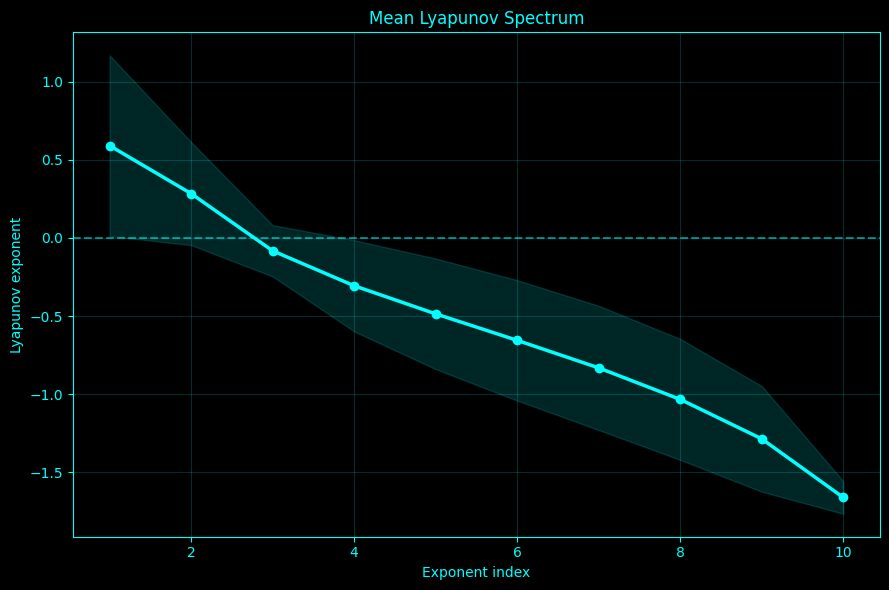

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/plots/mean_lyapunov_spectrum.png


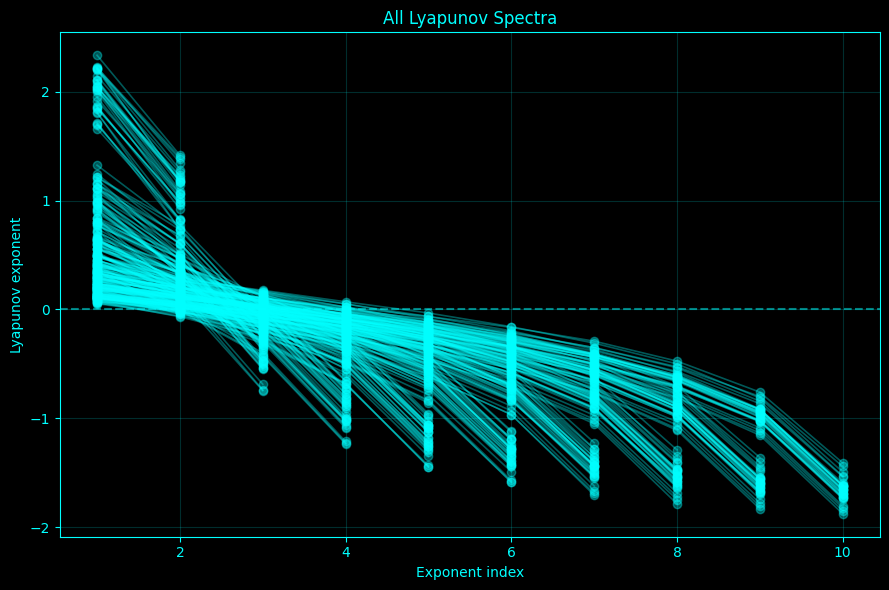

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/plots/all_lyapunov_spectra.png


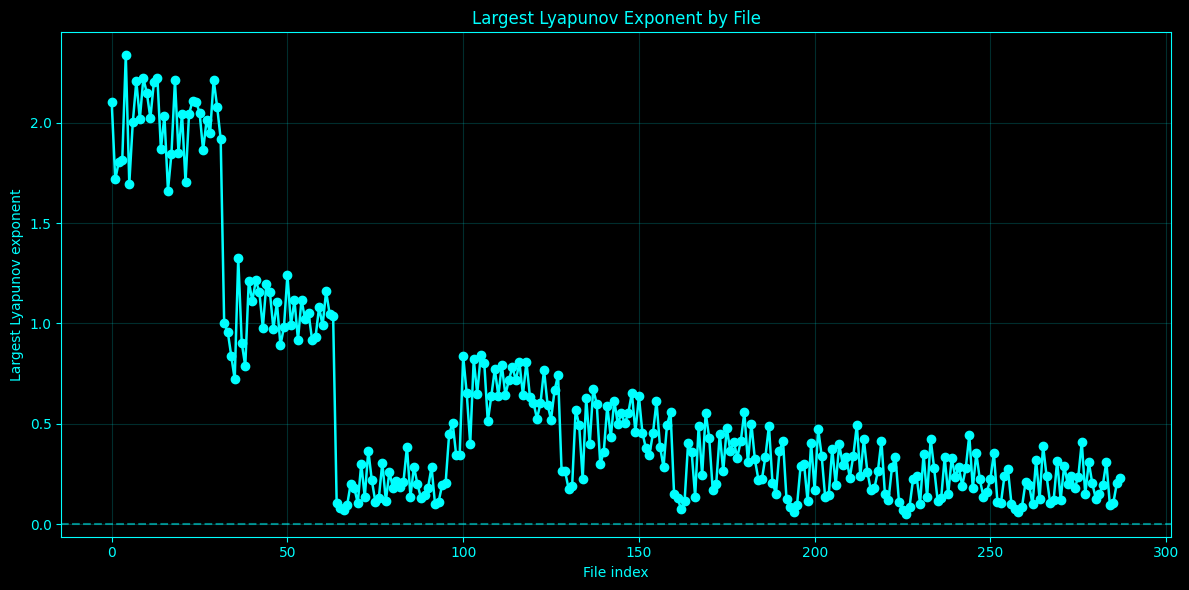

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/plots/largest_lyapunov_exponent_by_file.png


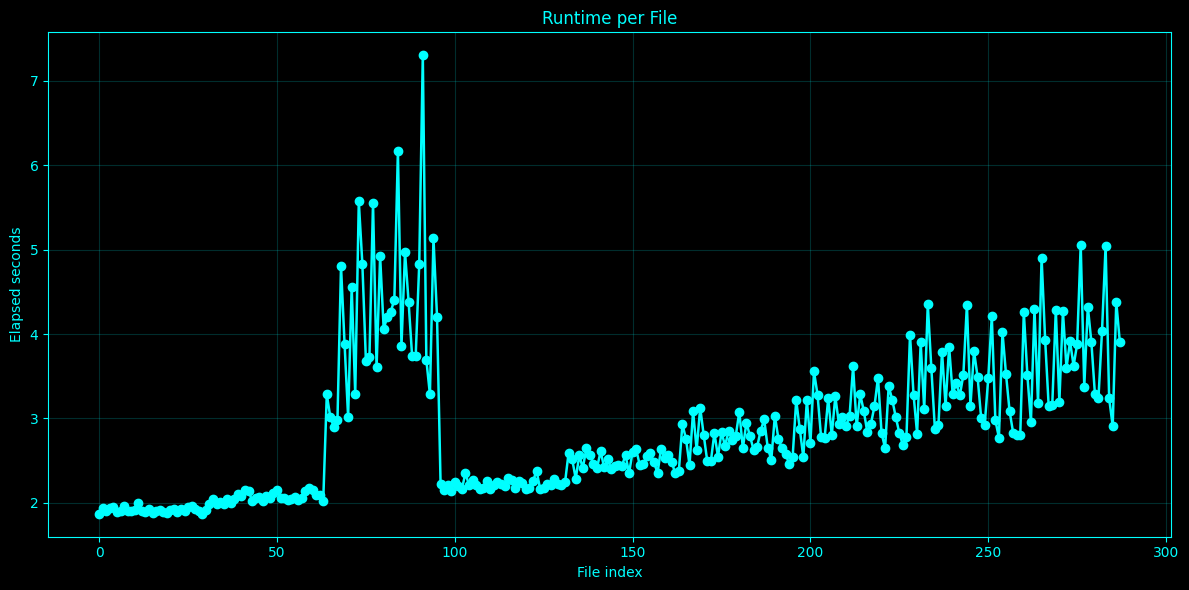

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/plots/runtime_per_file.png


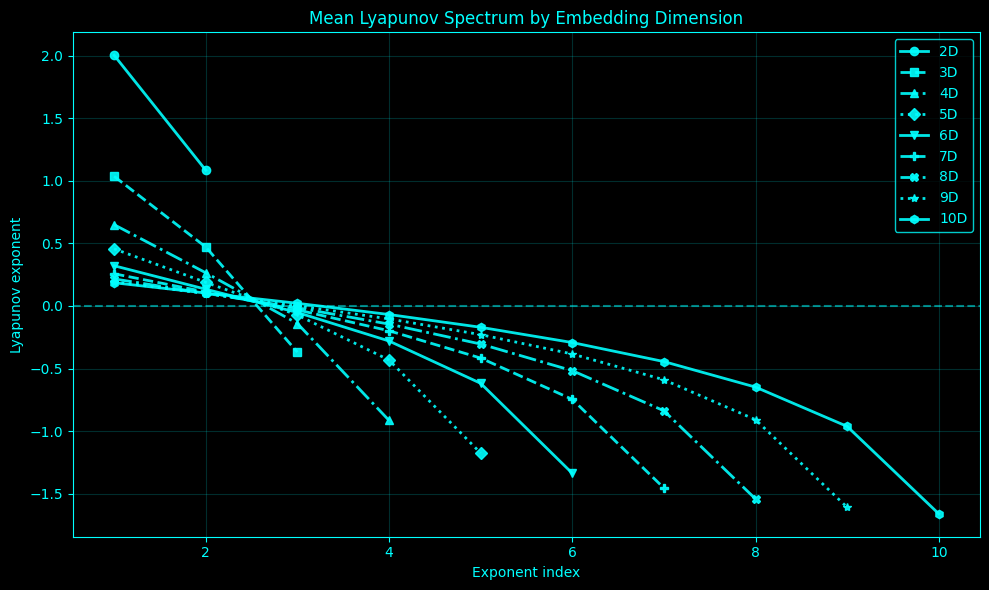

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/plots/mean_lyapunov_spectrum_by_dimension.png


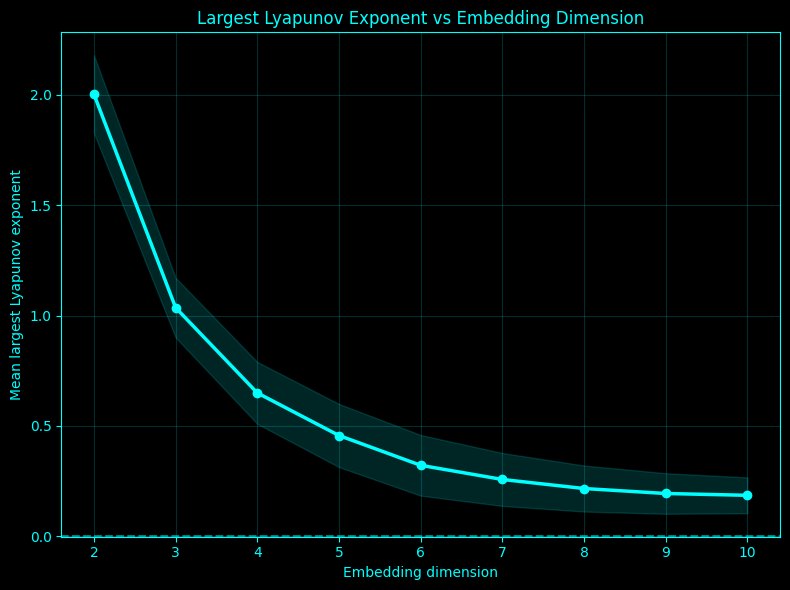

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/plots/largest_exponent_vs_embedding_dimension.png

Files per embedding dimension:
embedding_dimension
2.0     32
3.0     32
4.0     32
5.0     32
6.0     32
7.0     32
8.0     32
9.0     32
10.0    32
dtype: int64

All plots saved in:
/home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/plots


In [4]:
# -------------------------------------------------------
# PLOT + SAVE RESULTS
# Black background + cyan ticks/lines
# Works even if results_dir or df are not already defined
# -------------------------------------------------------
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Recover results_dir if it was not already defined
# -------------------------------------------------------
try:
    results_dir
except NameError:
    try:
        OUT_CSV
        results_dir = os.path.dirname(OUT_CSV)
    except NameError:
        base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
        results_dir = os.path.join(base_dir, "results", "lyapunov_custom")

os.makedirs(results_dir, exist_ok=True)

# -------------------------------------------------------
# Recover df if it was not already defined
# -------------------------------------------------------
try:
    df
except NameError:
    csv_files = sorted(glob.glob(os.path.join(results_dir, "lyap_spectrum_*.csv")))

    if len(csv_files) == 0:
        raise FileNotFoundError(
            "No Lyapunov CSV found. Run the Lyapunov calculation first, "
            "or manually set OUT_CSV to the path of your results CSV."
        )

    OUT_CSV = csv_files[-1]
    print("Loading latest CSV:", OUT_CSV)
    df = pd.read_csv(OUT_CSV)

# -------------------------------------------------------
# Create plot output directory
# -------------------------------------------------------
plot_dir = os.path.join(results_dir, "plots")
os.makedirs(plot_dir, exist_ok=True)

# -------------------------------------------------------
# Keep only successful rows
# -------------------------------------------------------
df_ok = df[df["status"] == "ok"].copy()

# Find exponent columns automatically: Exp1, Exp2, ...
exp_cols = sorted(
    [c for c in df_ok.columns if c.startswith("Exp")],
    key=lambda x: int(x.replace("Exp", "")) if x.replace("Exp", "").isdigit() else 10**9
)

if len(df_ok) == 0 or len(exp_cols) == 0:
    print("No successful Lyapunov exponent rows to plot.")

else:
    cyan = "cyan"
    black = "black"

    def style_ax(ax):
        ax.set_facecolor(black)
        ax.tick_params(axis="both", colors=cyan)

        ax.xaxis.label.set_color(cyan)
        ax.yaxis.label.set_color(cyan)
        ax.title.set_color(cyan)

        for spine in ax.spines.values():
            spine.set_color(cyan)

        ax.grid(True, color=cyan, alpha=0.18)

    spectra = df_ok[exp_cols].to_numpy(dtype=float)
    x = np.arange(1, len(exp_cols) + 1)

    # ---------------------------------------------------
    # 1. Mean Lyapunov spectrum across all files
    # ---------------------------------------------------
    mean_spectrum = np.nanmean(spectra, axis=0)
    std_spectrum = np.nanstd(spectra, axis=0)

    fig, ax = plt.subplots(figsize=(9, 6), facecolor=black)
    style_ax(ax)

    ax.plot(x, mean_spectrum, marker="o", linewidth=2.5, color=cyan)

    ax.fill_between(
        x,
        mean_spectrum - std_spectrum,
        mean_spectrum + std_spectrum,
        color=cyan,
        alpha=0.15
    )

    ax.axhline(0, color=cyan, linestyle="--", alpha=0.5)

    ax.set_title("Mean Lyapunov Spectrum")
    ax.set_xlabel("Exponent index")
    ax.set_ylabel("Lyapunov exponent")

    plt.tight_layout()
    out_path = os.path.join(plot_dir, "mean_lyapunov_spectrum.png")
    plt.savefig(out_path, dpi=300, facecolor=black)
    plt.show()

    print("Saved:", out_path)

    # ---------------------------------------------------
    # 2. All spectra overlaid
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(9, 6), facecolor=black)
    style_ax(ax)

    for row in spectra:
        ax.plot(x, row, marker="o", linewidth=1.2, alpha=0.35, color=cyan)

    ax.axhline(0, color=cyan, linestyle="--", alpha=0.5)

    ax.set_title("All Lyapunov Spectra")
    ax.set_xlabel("Exponent index")
    ax.set_ylabel("Lyapunov exponent")

    plt.tight_layout()
    out_path = os.path.join(plot_dir, "all_lyapunov_spectra.png")
    plt.savefig(out_path, dpi=300, facecolor=black)
    plt.show()

    print("Saved:", out_path)

    # ---------------------------------------------------
    # 3. Largest Lyapunov exponent per file
    # ---------------------------------------------------
    largest_exp = np.nanmax(spectra, axis=1)

    fig, ax = plt.subplots(figsize=(12, 6), facecolor=black)
    style_ax(ax)

    ax.plot(
        np.arange(len(largest_exp)),
        largest_exp,
        marker="o",
        linewidth=1.8,
        color=cyan
    )

    ax.axhline(0, color=cyan, linestyle="--", alpha=0.5)

    ax.set_title("Largest Lyapunov Exponent by File")
    ax.set_xlabel("File index")
    ax.set_ylabel("Largest Lyapunov exponent")

    plt.tight_layout()
    out_path = os.path.join(plot_dir, "largest_lyapunov_exponent_by_file.png")
    plt.savefig(out_path, dpi=300, facecolor=black)
    plt.show()

    print("Saved:", out_path)

    # ---------------------------------------------------
    # 4. Runtime per file
    # ---------------------------------------------------
    if "elapsed_sec" in df_ok.columns:
        fig, ax = plt.subplots(figsize=(12, 6), facecolor=black)
        style_ax(ax)

        ax.plot(
            np.arange(len(df_ok)),
            df_ok["elapsed_sec"].to_numpy(dtype=float),
            marker="o",
            linewidth=1.8,
            color=cyan
        )

        ax.set_title("Runtime per File")
        ax.set_xlabel("File index")
        ax.set_ylabel("Elapsed seconds")

        plt.tight_layout()
        out_path = os.path.join(plot_dir, "runtime_per_file.png")
        plt.savefig(out_path, dpi=300, facecolor=black)
        plt.show()

        print("Saved:", out_path)

    # ---------------------------------------------------
    # 5. Mean Lyapunov spectrum by embedding dimension
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6), facecolor=black)
    style_ax(ax)

    line_styles = ["-", "--", "-.", ":"]
    markers = ["o", "s", "^", "D", "v", "P", "X", "*", "h"]

    for j, dim in enumerate(sorted(df_ok["embedding_dimension"].dropna().unique())):
        sub = df_ok[df_ok["embedding_dimension"] == dim].copy()

        dim_exp_cols = sorted(
            [c for c in exp_cols if sub[c].notna().any()],
            key=lambda x: int(x.replace("Exp", ""))
        )

        if len(dim_exp_cols) == 0:
            continue

        sub_spectra = sub[dim_exp_cols].to_numpy(dtype=float)
        mean_spec = np.nanmean(sub_spectra, axis=0)
        x_dim = np.arange(1, len(dim_exp_cols) + 1)

        ax.plot(
            x_dim,
            mean_spec,
            marker=markers[j % len(markers)],
            linestyle=line_styles[j % len(line_styles)],
            linewidth=2,
            alpha=0.9,
            color=cyan,
            label=f"{int(dim)}D"
        )

    ax.axhline(0, color=cyan, linestyle="--", alpha=0.5)

    ax.set_title("Mean Lyapunov Spectrum by Embedding Dimension")
    ax.set_xlabel("Exponent index")
    ax.set_ylabel("Lyapunov exponent")

    leg = ax.legend(facecolor=black, edgecolor=cyan)
    for text in leg.get_texts():
        text.set_color(cyan)

    plt.tight_layout()
    out_path = os.path.join(plot_dir, "mean_lyapunov_spectrum_by_dimension.png")
    plt.savefig(out_path, dpi=300, facecolor=black)
    plt.show()

    print("Saved:", out_path)

    # ---------------------------------------------------
    # 6. Largest Lyapunov exponent vs embedding dimension
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 6), facecolor=black)
    style_ax(ax)

    dims = []
    largest_means = []
    largest_stds = []

    for dim in sorted(df_ok["embedding_dimension"].dropna().unique()):
        sub = df_ok[df_ok["embedding_dimension"] == dim].copy()

        dim_exp_cols = sorted(
            [c for c in exp_cols if sub[c].notna().any()],
            key=lambda x: int(x.replace("Exp", ""))
        )

        if len(dim_exp_cols) == 0:
            continue

        sub_spectra = sub[dim_exp_cols].to_numpy(dtype=float)
        vals = np.nanmax(sub_spectra, axis=1)

        dims.append(dim)
        largest_means.append(np.nanmean(vals))
        largest_stds.append(np.nanstd(vals))

    dims = np.array(dims, dtype=float)
    largest_means = np.array(largest_means, dtype=float)
    largest_stds = np.array(largest_stds, dtype=float)

    ax.plot(dims, largest_means, marker="o", linewidth=2.5, color=cyan)

    ax.fill_between(
        dims,
        largest_means - largest_stds,
        largest_means + largest_stds,
        color=cyan,
        alpha=0.15
    )

    ax.axhline(0, color=cyan, linestyle="--", alpha=0.5)

    ax.set_title("Largest Lyapunov Exponent vs Embedding Dimension")
    ax.set_xlabel("Embedding dimension")
    ax.set_ylabel("Mean largest Lyapunov exponent")

    plt.tight_layout()
    out_path = os.path.join(plot_dir, "largest_exponent_vs_embedding_dimension.png")
    plt.savefig(out_path, dpi=300, facecolor=black)
    plt.show()

    print("Saved:", out_path)

    # ---------------------------------------------------
    # 7. Print counts per embedding dimension
    # ---------------------------------------------------
    print("\nFiles per embedding dimension:")
    print(df_ok.groupby("embedding_dimension").size())

    print("\nAll plots saved in:")
    print(plot_dir)

# Arnold Tongue


Kuramoto speed profile
Selected speed: ultra
Very fast preview.
  grid_n: 12
  t_end: 8.0
  n_t_eval: 120
  rtol: 0.001
  atol: 1e-05
  solver_method: RK45
  dpi: 140
  contours: False

Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec

Estimated dominant frequencies (Hz) per channel:
  Fp1: 1.2530 Hz
  Fpz: 1.1875 Hz
  Fp2: 1.1875 Hz
  F7: 1.2156 Hz
  F3: 1.2530 Hz
  Fz: 1.1127 Hz
  F4: 1.1127 Hz
  F8: 1.6644 Hz
  FC5: 1.2062 Hz
  FC1: 1.1782 Hz
  FC2: 1.1127 Hz
  FC6: 1.1782 Hz
  M1: 1.2623 Hz
  T7: 1.5896 Hz
  C3: 1.1127 Hz
  Cz: 1.3091 Hz
  C4: 1.1782 Hz
  T8: 1.0099 Hz
  M2: 1.2623 Hz
  CP5: 1.2062 Hz
  CP1: 1.1969 Hz
  CP2: 1.1501 Hz
  CP6: 1.0099 Hz
  P7: 21.0110 Hz
  P3: 1.1782 Hz
  Pz: 1.1969 Hz
  P4: 1.0660 Hz
  P8: 1.2623 Hz
  POz: 10.3232 Hz
  O1: 1.1501 Hz
  Oz: 1.2623 Hz
  O2: 1.2623 Hz

Dimensionless natural frequencies used in Kuramoto model:
  Fp1: -0.229847
  Fpz: -0.247312
  Fp2: -0.247312
  F7: -0.239827
  F3: -0.229847
  Fz: -0.26727

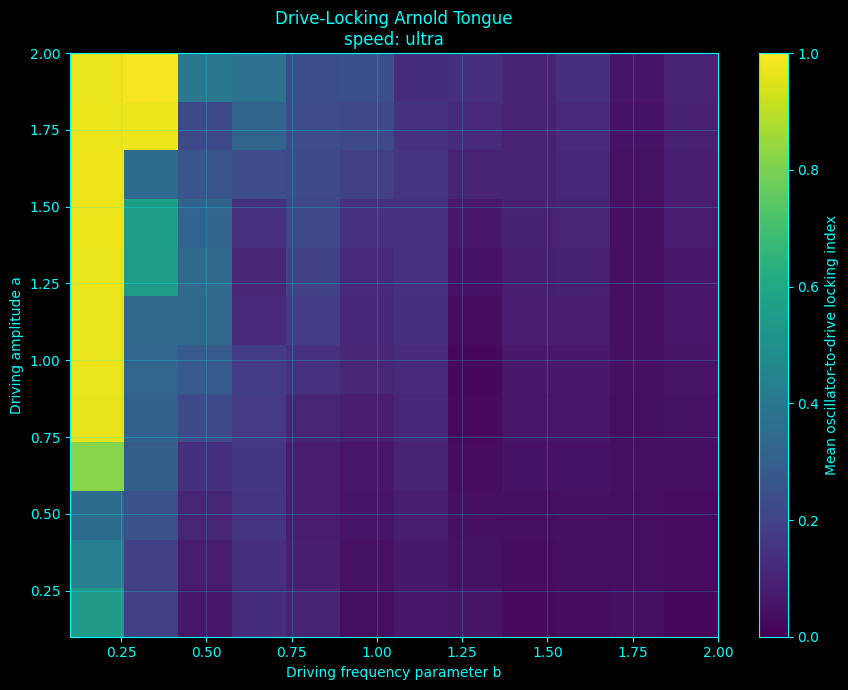

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/kuramoto_drive_locking_arnold_tongue.png


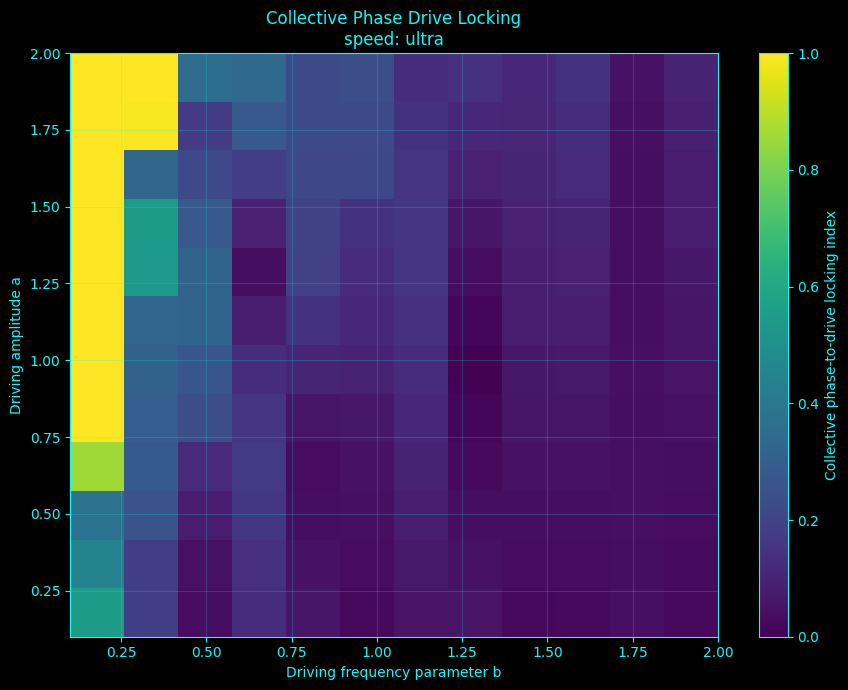

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/kuramoto_collective_drive_locking.png


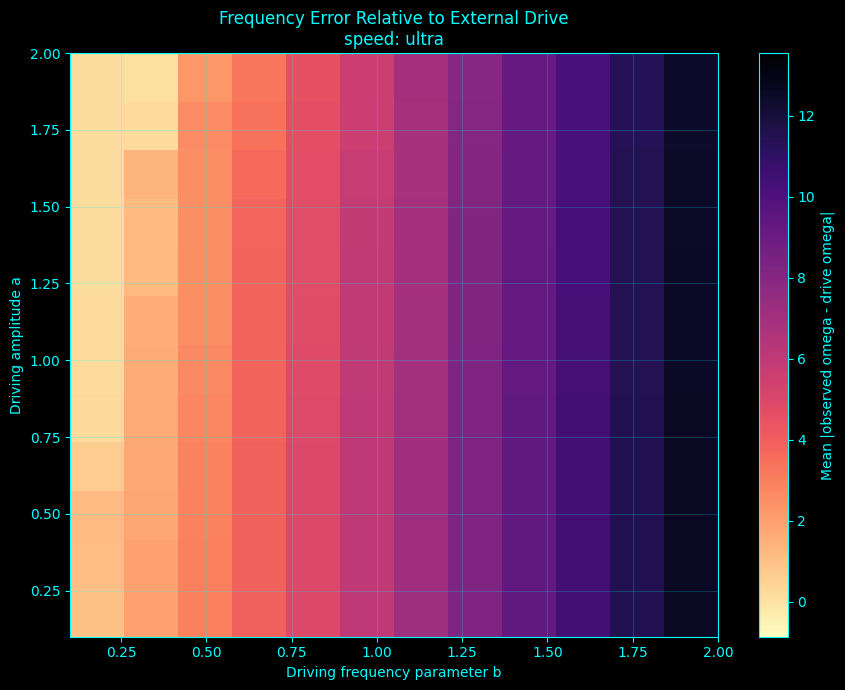

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/kuramoto_drive_frequency_error.png


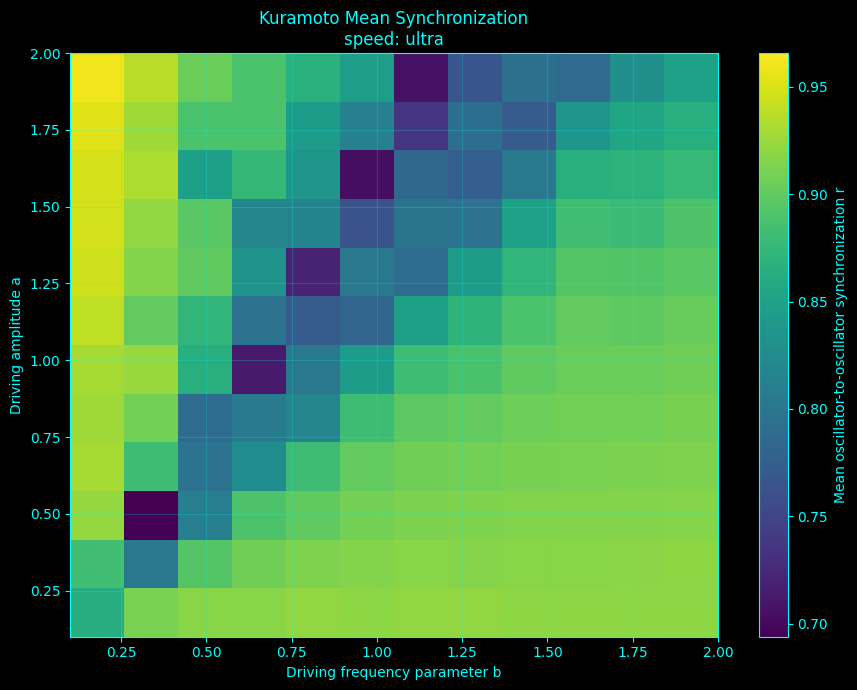

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/kuramoto_mean_sync_visible_scale.png


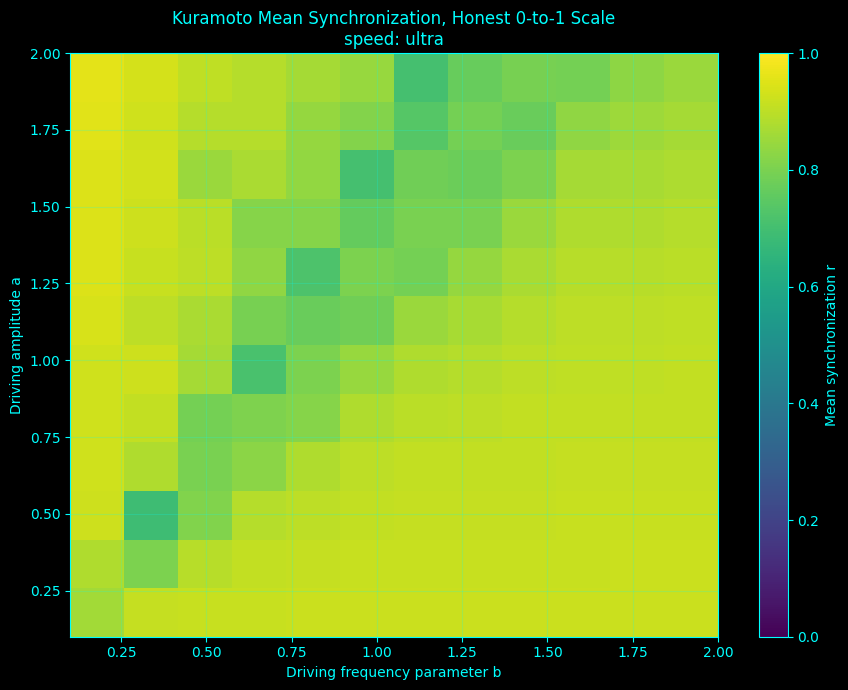

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/kuramoto_mean_sync_honest_scale.png


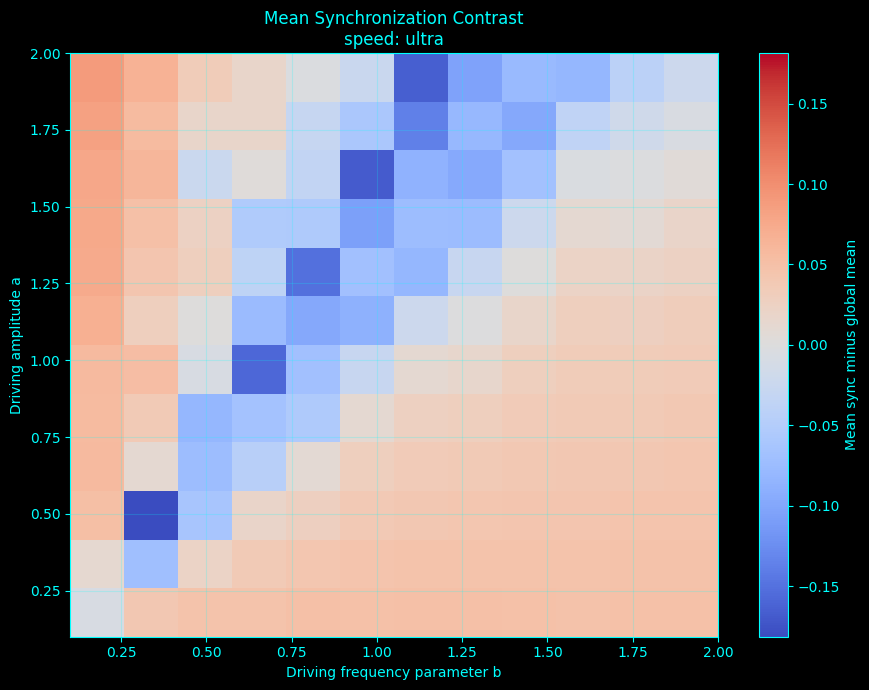

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/kuramoto_mean_sync_contrast.png


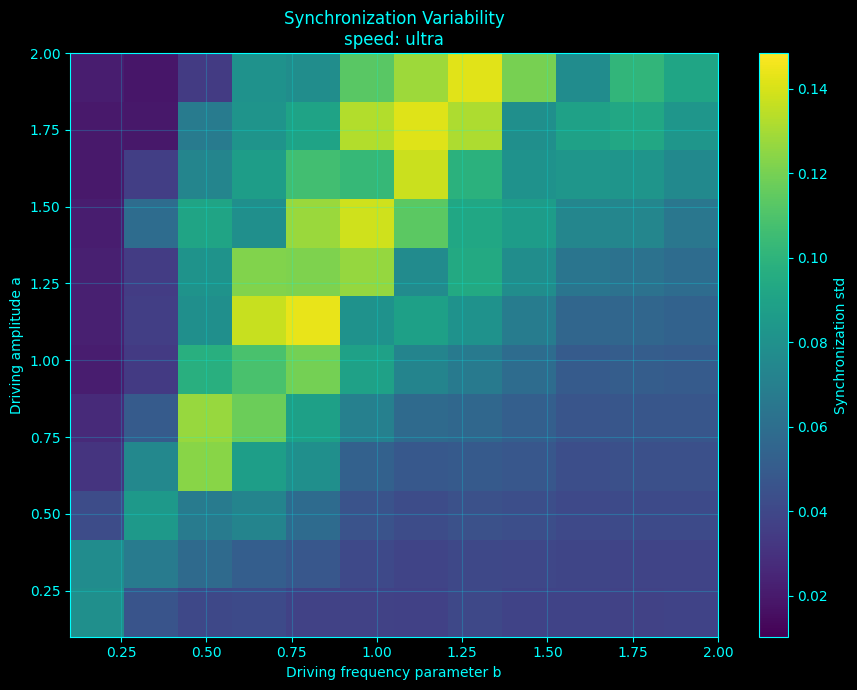

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/kuramoto_sync_std_heatmap.png


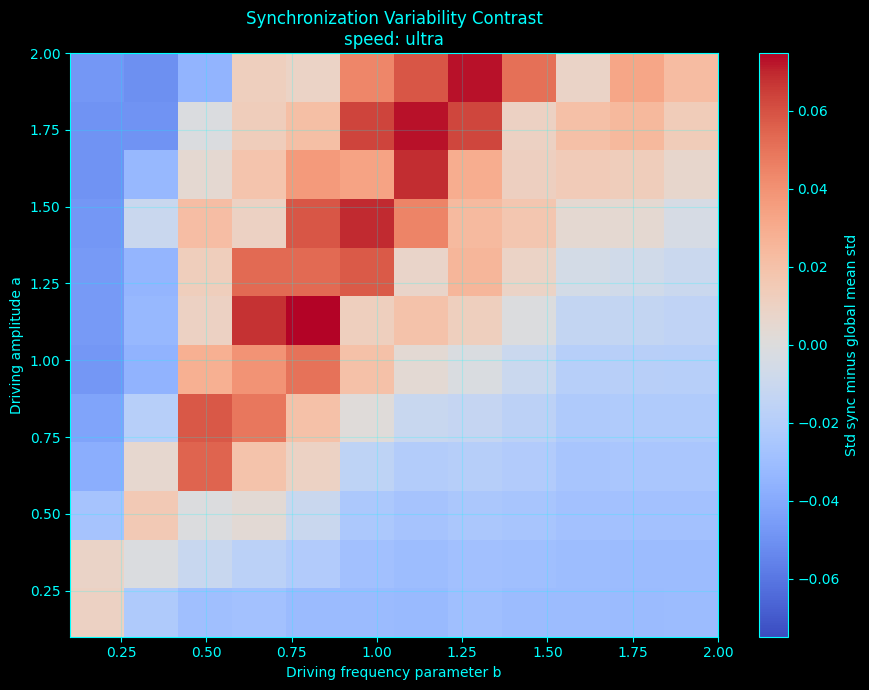

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/kuramoto_sync_std_contrast.png


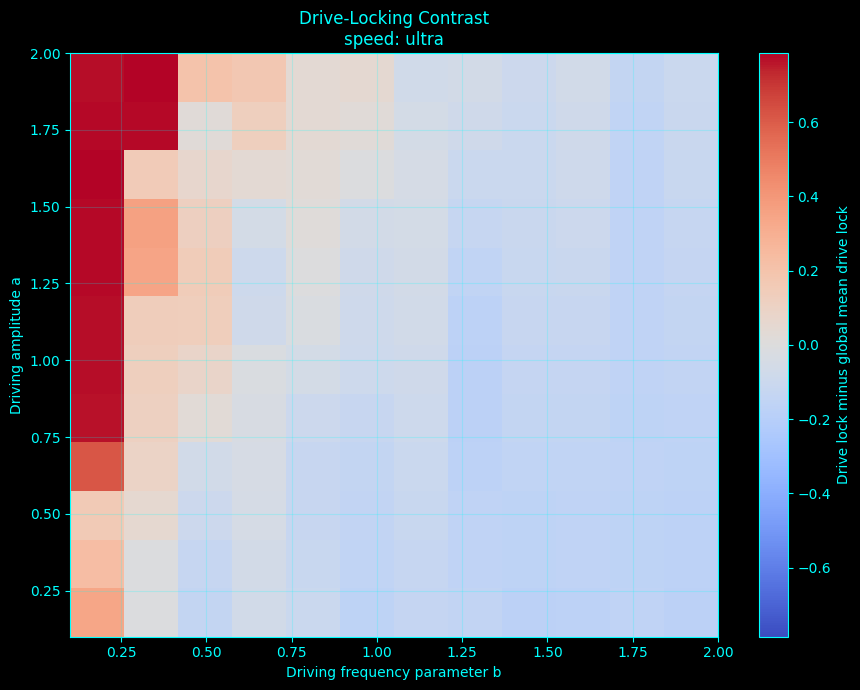

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/kuramoto_drive_locking_contrast.png


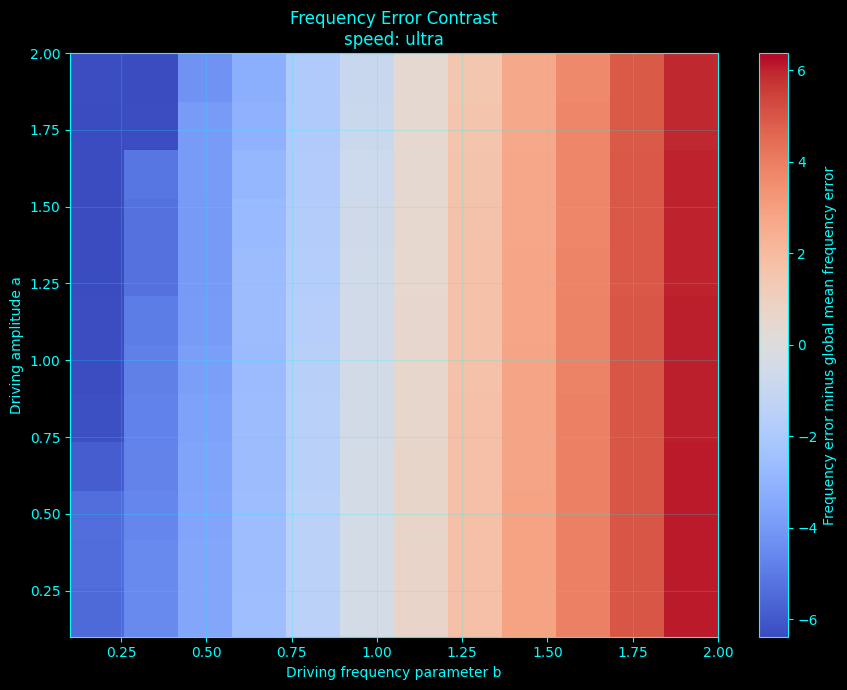

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/kuramoto_frequency_error_contrast.png


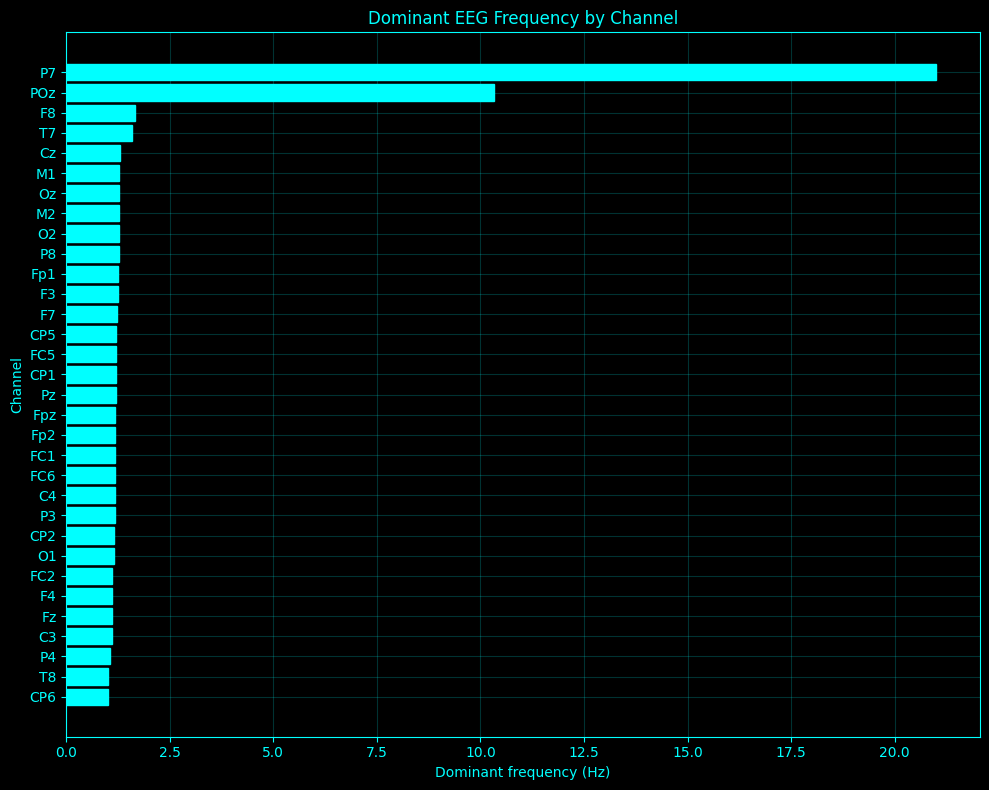

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/dominant_eeg_frequencies_by_channel.png


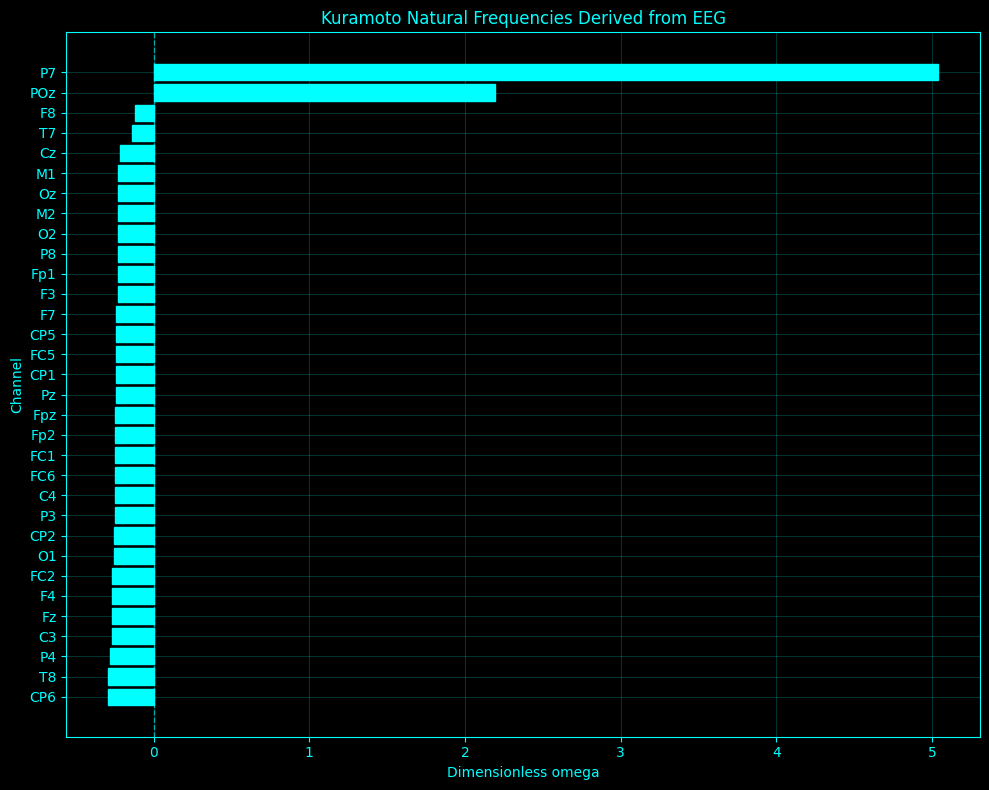

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/kuramoto_omega_by_channel.png


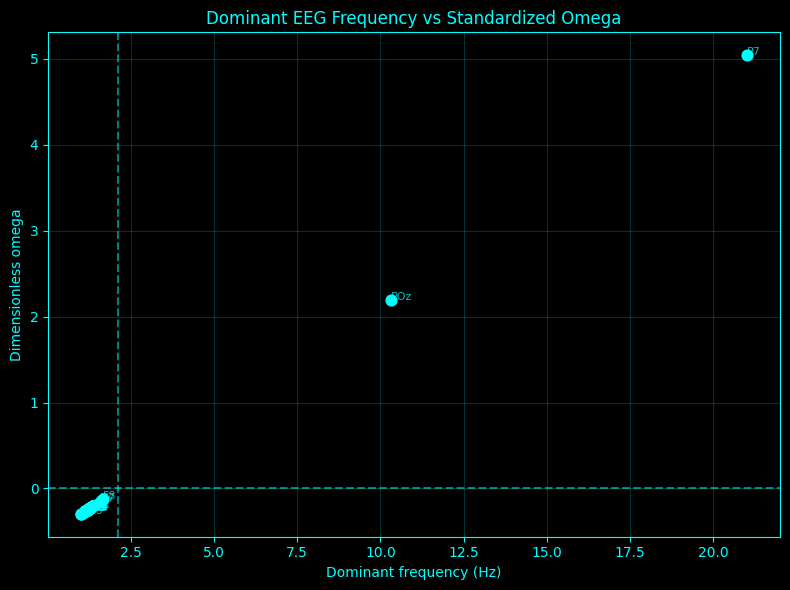

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/dominant_frequency_vs_omega.png


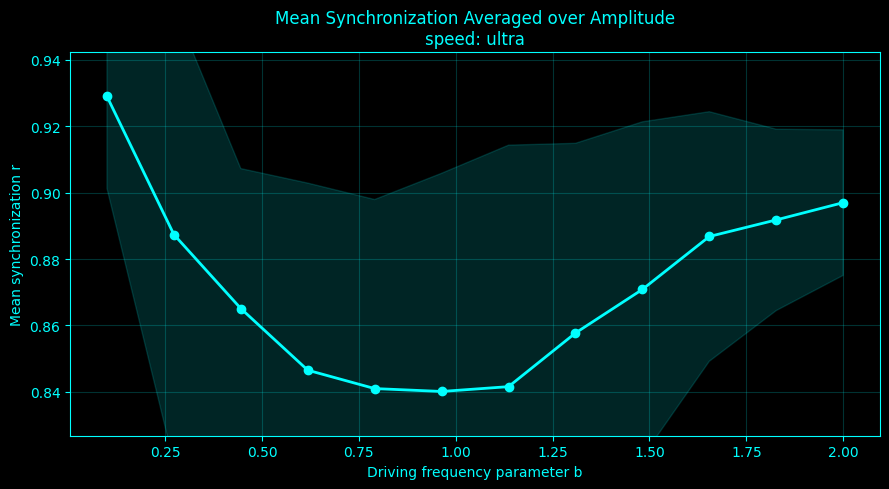

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/mean_sync_vs_b.png


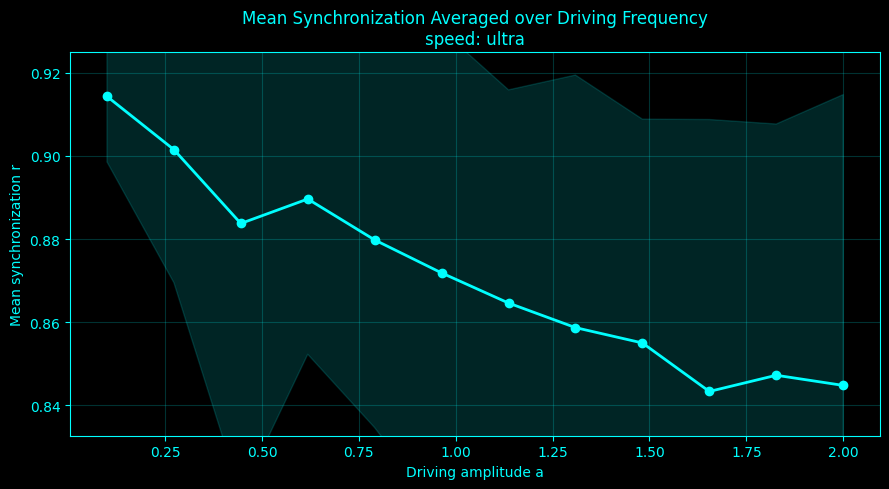

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/mean_sync_vs_a.png


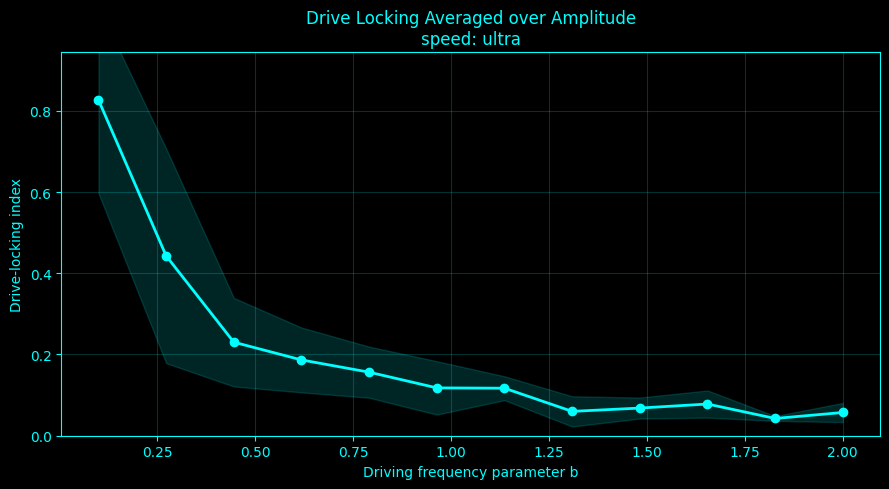

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/drive_lock_vs_b.png


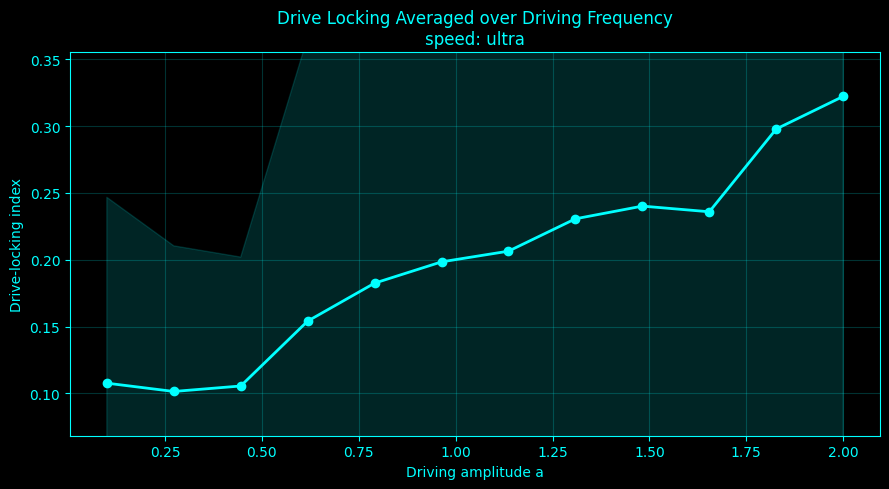

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/drive_lock_vs_a.png


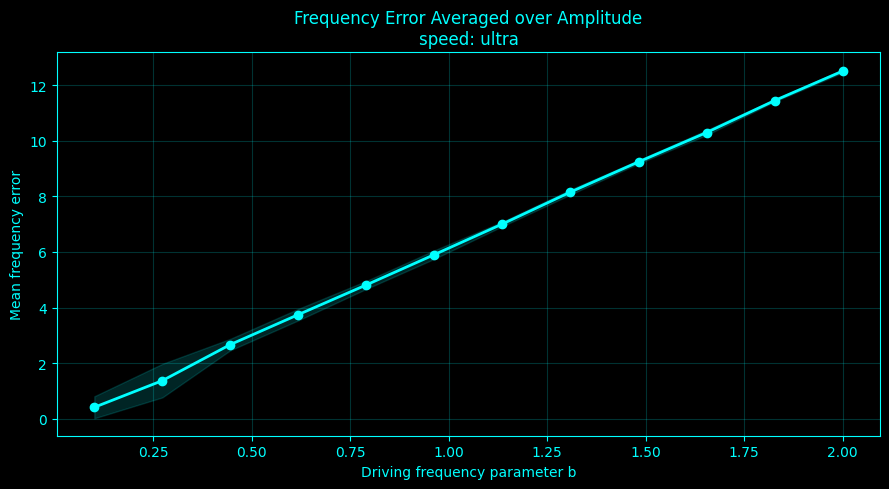

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/frequency_error_vs_b.png


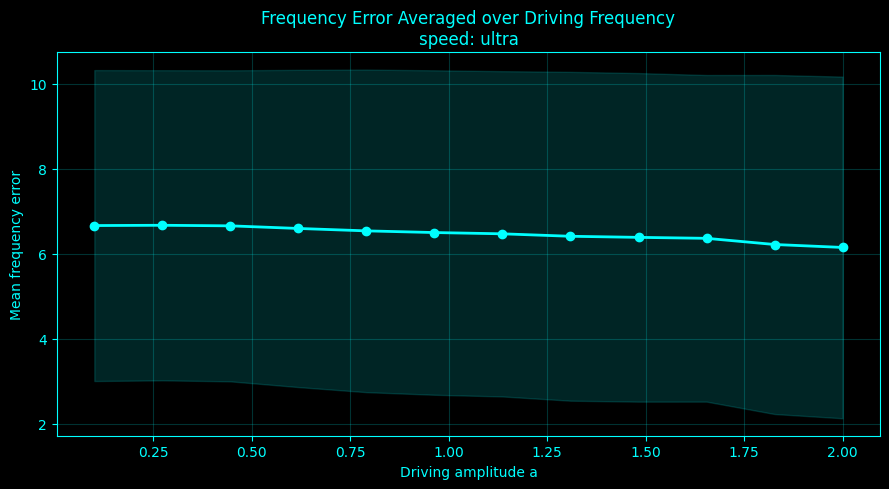

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots/frequency_error_vs_a.png

Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/arnold_tongues_results.npz
Saved grid CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/arnold_tongues_grid.csv
Saved omega CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/kuramoto_natural_frequencies.csv
Saved summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/arnold_tongues_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_kuramoto/ultra/plots
Speed mode used: ultra

Run examples:
  python your_script.py --speed ultra
  python your_script.py --speed fast
  python your_script.py --speed balanced
  python your_script.py --speed full


In [5]:
import os
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

SPEED_PROFILES = {
    "ultra": {
        "grid_n": 12,
        "t_end": 8.0,
        "n_t_eval": 120,
        "rtol": 1e-3,
        "atol": 1e-5,
        "solver_method": "RK45",
        "dpi": 140,
        "contours": False,
        "description": "Very fast preview.",
    },
    "fast": {
        "grid_n": 25,
        "t_end": 20.0,
        "n_t_eval": 250,
        "rtol": 3e-4,
        "atol": 1e-6,
        "solver_method": "RK45",
        "dpi": 170,
        "contours": False,
        "description": "Fast exploratory run.",
    },
    "balanced": {
        "grid_n": 40,
        "t_end": 40.0,
        "n_t_eval": 450,
        "rtol": 1e-4,
        "atol": 1e-7,
        "solver_method": "RK45",
        "dpi": 200,
        "contours": True,
        "description": "Good default run.",
    },
    "full": {
        "grid_n": 50,
        "t_end": 60.0,
        "n_t_eval": 600,
        "rtol": 1e-5,
        "atol": 1e-7,
        "solver_method": "RK45",
        "dpi": 220,
        "contours": True,
        "description": "Full-quality run.",
    },
}


def parse_speed_mode():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--speed",
        choices=list(SPEED_PROFILES.keys()),
        default="ultra",
        help="Choose simulation speed: ultra, fast, balanced, or full.",
    )
    args, _ = parser.parse_known_args()

    env_speed = os.environ.get("KURAMOTO_SPEED", "").strip().lower()
    if env_speed:
        if env_speed not in SPEED_PROFILES:
            raise ValueError(
                f"Invalid KURAMOTO_SPEED={env_speed!r}. "
                f"Choose one of: {list(SPEED_PROFILES.keys())}"
            )
        return env_speed

    return args.speed


speed_mode = parse_speed_mode()
speed_cfg = SPEED_PROFILES[speed_mode]

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "arnold_tongues_kuramoto", speed_mode)
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx = int(end_time * sampling_rate)

eeg_channels = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8",
    "FC5", "FC1", "FC2", "FC6", "M1", "T7", "C3", "Cz",
    "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

K = 1.0
rng_seed = 42
grid_n = speed_cfg["grid_n"]

a_values = np.linspace(0.1, 2.0, grid_n)
b_values = np.linspace(0.1, 2.0, grid_n)

t_start = 0.0
t_end = speed_cfg["t_end"]
n_t_eval = speed_cfg["n_t_eval"]
transient_fraction = 0.5
solver_method = speed_cfg["solver_method"]
rtol = speed_cfg["rtol"]
atol = speed_cfg["atol"]
plot_dpi = speed_cfg["dpi"]
plot_contours = speed_cfg["contours"]

freq_band = (1.0, 45.0)

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})


def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, alpha=0.20, color=ACCENT)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)

    label = cbar.ax.get_ylabel()
    if label:
        cbar.set_label(label, color=ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=None):
    if dpi is None:
        dpi = plot_dpi

    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path)


def robust_limits(
    arr,
    lower=2,
    upper=98,
    pad_fraction=0.08,
    min_span=1e-8,
    bounds=None,
):
    arr = np.asarray(arr, dtype=float)
    finite = arr[np.isfinite(arr)]

    if finite.size == 0:
        if bounds is not None:
            return bounds
        return 0.0, 1.0

    vmin, vmax = np.nanpercentile(finite, [lower, upper])

    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
        vmin = np.nanmin(finite)
        vmax = np.nanmax(finite)

    center = 0.5 * (vmin + vmax)
    span = vmax - vmin

    if not np.isfinite(span) or span < min_span:
        span = max(abs(center) * 1e-6, min_span)
        vmin = center - 0.5 * span
        vmax = center + 0.5 * span
    else:
        pad = pad_fraction * span
        vmin -= pad
        vmax += pad

    if bounds is not None:
        lo, hi = bounds
        vmin = max(lo, vmin)
        vmax = min(hi, vmax)

    if vmax <= vmin:
        delta = max(abs(center) * 1e-6, min_span)
        vmin = center - delta
        vmax = center + delta

        if bounds is not None:
            lo, hi = bounds
            vmin = max(lo, vmin)
            vmax = min(hi, vmax)

        if vmax <= vmin:
            if bounds is not None:
                return bounds
            return center - min_span, center + min_span

    return float(vmin), float(vmax)


def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")

    if x.shape[1] == n_channels_expected:
        return x

    if x.shape[0] == n_channels_expected:
        return x.T

    raise ValueError(f"Unexpected EEG shape: {x.shape}")


def estimate_dominant_frequencies(eeg_segment, fs, band=(1.0, 45.0)):
    eeg_segment = np.asarray(eeg_segment, dtype=float)
    n_samples, n_channels = eeg_segment.shape

    X = eeg_segment - np.mean(eeg_segment, axis=0, keepdims=True)
    fft_vals = np.fft.rfft(X, axis=0)
    freqs = np.fft.rfftfreq(n_samples, d=1.0 / fs)

    band_mask = (freqs >= band[0]) & (freqs <= band[1])
    if not np.any(band_mask):
        raise ValueError(f"No FFT frequencies found inside band {band}")

    band_freqs = freqs[band_mask]
    band_power = np.abs(fft_vals[band_mask, :])

    peak_idx = np.argmax(band_power, axis=0)
    dom_freqs = band_freqs[peak_idx]

    return dom_freqs


def build_natural_frequencies_from_eeg(eeg_segment, fs, band=(1.0, 45.0)):
    dom_freqs = estimate_dominant_frequencies(eeg_segment, fs, band=band)
    omega = (dom_freqs - np.mean(dom_freqs)) / (np.std(dom_freqs) + eps)
    return omega, dom_freqs


def kuramoto_rhs(t, theta, omega, K, a, b):
    z = np.mean(np.exp(1j * theta))
    r = np.abs(z)
    psi = np.angle(z)

    coupling = K * r * np.sin(psi - theta)

    drive_phase = 2.0 * np.pi * b * t
    drive = a * np.sin(drive_phase - theta)

    return omega + coupling + drive


def simulate_kuramoto(omega, K, a, b, theta0, t_span, t_eval):
    sol = solve_ivp(
        kuramoto_rhs,
        t_span=t_span,
        y0=theta0,
        t_eval=t_eval,
        args=(omega, K, a, b),
        method=solver_method,
        rtol=rtol,
        atol=atol,
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    theta = sol.y
    z = np.mean(np.exp(1j * theta), axis=0)
    r = np.abs(z)

    return sol.t, theta, r


def plot_heatmap(
    data,
    title,
    colorbar_label,
    out_name,
    cmap_name="viridis",
    vmin=None,
    vmax=None,
    robust=False,
    bounds=None,
    contour=False,
    contour_color=None,
):
    fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)
    style_ax(ax)

    arr = np.asarray(data, dtype=float)

    if robust:
        vmin, vmax = robust_limits(
            arr,
            lower=2,
            upper=98,
            pad_fraction=0.08,
            min_span=1e-8,
            bounds=bounds,
        )

    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad(BG)

    im = ax.imshow(
        np.ma.masked_invalid(arr),
        extent=[b_values.min(), b_values.max(), a_values.min(), a_values.max()],
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )

    if contour and plot_contours:
        try:
            finite = arr[np.isfinite(arr)]
            if finite.size > 0:
                cmin = np.nanmin(finite) if vmin is None else vmin
                cmax = np.nanmax(finite) if vmax is None else vmax
                if cmax > cmin:
                    B, A = np.meshgrid(b_values, a_values)
                    levels = np.linspace(cmin, cmax, 8)
                    ax.contour(
                        B,
                        A,
                        arr,
                        levels=levels,
                        colors=contour_color or ACCENT,
                        linewidths=0.45,
                        alpha=0.35,
                    )
        except Exception as e:
            print(f"Skipping contour overlay for {out_name}:", e)

    ax.set_title(title)
    ax.set_xlabel("Driving frequency parameter b")
    ax.set_ylabel("Driving amplitude a")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)
    style_colorbar(cbar)

    out_path = os.path.join(plots_dir, out_name)
    save_show_close(fig, out_path)

    return out_path, vmin, vmax


def plot_line_with_band(x, y, ystd, title, xlabel, ylabel, out_name, ylim_bounds=None):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
    style_ax(ax)

    ax.plot(
        x,
        y,
        color=ACCENT,
        marker="o",
        linewidth=2.0,
    )

    if ystd is not None:
        ax.fill_between(
            x,
            y - ystd,
            y + ystd,
            color=ACCENT,
            alpha=0.15,
        )

    if ylim_bounds is not None:
        ymin, ymax = robust_limits(
            y,
            lower=0,
            upper=100,
            pad_fraction=0.15,
            min_span=1e-8,
            bounds=ylim_bounds,
        )
        ax.set_ylim(ymin, ymax)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    out_path = os.path.join(plots_dir, out_name)
    save_show_close(fig, out_path)

    return out_path


print("\nKuramoto speed profile")
print("======================")
print(f"Selected speed: {speed_mode}")
print(speed_cfg["description"])
for key, value in speed_cfg.items():
    if key != "description":
        print(f"  {key}: {value}")

EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channels))
EEG_segment = EEG_data[start_idx:end_idx, :]

n_samples, N = EEG_segment.shape

print(f"\nLoaded EEG segment: {n_samples} samples x {N} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

omega, dominant_freqs_hz = build_natural_frequencies_from_eeg(
    EEG_segment,
    sampling_rate,
    band=freq_band,
)

print("\nEstimated dominant frequencies (Hz) per channel:")
for ch, fdom in zip(eeg_channels, dominant_freqs_hz):
    print(f"  {ch}: {fdom:.4f} Hz")

print("\nDimensionless natural frequencies used in Kuramoto model:")
for ch, om in zip(eeg_channels, omega):
    print(f"  {ch}: {om:.6f}")

rng = np.random.default_rng(rng_seed)
theta0 = rng.uniform(0.0, 2.0 * np.pi, N)

t_eval = np.linspace(t_start, t_end, n_t_eval)
t_span = (t_start, t_end)
transient_start_idx = int(transient_fraction * len(t_eval))

synchronization_array = np.zeros((len(a_values), len(b_values)), dtype=float)
sync_std_array = np.zeros((len(a_values), len(b_values)), dtype=float)
drive_lock_array = np.zeros((len(a_values), len(b_values)), dtype=float)
collective_drive_lock_array = np.zeros((len(a_values), len(b_values)), dtype=float)
freq_error_array = np.zeros((len(a_values), len(b_values)), dtype=float)

total_runs = len(a_values) * len(b_values)

print("\nStarting Arnold tongue grid")
print("===========================")
print(f"Grid: {len(a_values)} x {len(b_values)} = {total_runs} simulations")
print(f"Time span: [{t_start}, {t_end}]")
print(f"t_eval points: {n_t_eval}")
print(f"Solver: {solver_method}, rtol={rtol}, atol={atol}")
print("Model: phase-forced Kuramoto, drive = a * sin(2*pi*b*t - theta_i)")

run_counter = 0

for i, a in enumerate(a_values):
    print(f"Processing amplitude row {i + 1}/{len(a_values)} | a={a:.4f}")

    for j, b in enumerate(b_values):
        run_counter += 1

        t, theta, r = simulate_kuramoto(
            omega=omega,
            K=K,
            a=a,
            b=b,
            theta0=theta0,
            t_span=t_span,
            t_eval=t_eval,
        )

        r_ss = r[transient_start_idx:]
        theta_ss = theta[:, transient_start_idx:]
        t_ss = t[transient_start_idx:]

        synchronization_array[i, j] = np.mean(r_ss)
        sync_std_array[i, j] = np.std(r_ss)

        drive_phase = 2.0 * np.pi * b * t_ss
        relative_phase = np.exp(1j * (theta_ss - drive_phase[None, :]))

        per_oscillator_drive_lock = np.abs(np.mean(relative_phase, axis=1))
        drive_lock_array[i, j] = np.mean(per_oscillator_drive_lock)

        z_ss = np.mean(np.exp(1j * theta_ss), axis=0)
        collective_phase = np.angle(z_ss)
        collective_drive_lock_array[i, j] = np.abs(
            np.mean(np.exp(1j * (collective_phase - drive_phase)))
        )

        unwrapped_theta = np.unwrap(theta_ss, axis=1)

        if t_ss[-1] > t_ss[0]:
            observed_omega_each = (
                unwrapped_theta[:, -1] - unwrapped_theta[:, 0]
            ) / (t_ss[-1] - t_ss[0])
            drive_omega = 2.0 * np.pi * b
            freq_error_array[i, j] = np.mean(np.abs(observed_omega_each - drive_omega))
        else:
            freq_error_array[i, j] = np.nan

npz_path = os.path.join(out_dir, "arnold_tongues_results.npz")

np.savez_compressed(
    npz_path,
    synchronization_array=synchronization_array,
    sync_std_array=sync_std_array,
    drive_lock_array=drive_lock_array,
    collective_drive_lock_array=collective_drive_lock_array,
    freq_error_array=freq_error_array,
    a_values=a_values,
    b_values=b_values,
    omega=omega,
    dominant_freqs_hz=dominant_freqs_hz,
    eeg_channels=np.array(eeg_channels, dtype=object),
    K=K,
    t_eval=t_eval,
    transient_fraction=transient_fraction,
    sampling_rate=sampling_rate,
    start_time=start_time,
    end_time=end_time,
    speed_mode=speed_mode,
    speed_cfg=str(speed_cfg),
)

grid_rows = []

for i, a in enumerate(a_values):
    for j, b in enumerate(b_values):
        grid_rows.append({
            "speed_mode": speed_mode,
            "a": float(a),
            "b": float(b),
            "mean_sync": float(synchronization_array[i, j]),
            "std_sync": float(sync_std_array[i, j]),
            "drive_lock": float(drive_lock_array[i, j]),
            "collective_drive_lock": float(collective_drive_lock_array[i, j]),
            "frequency_error": float(freq_error_array[i, j]),
        })

grid_df = pd.DataFrame(grid_rows)
grid_csv = os.path.join(out_dir, "arnold_tongues_grid.csv")
grid_df.to_csv(grid_csv, index=False)

omega_df = pd.DataFrame({
    "channel": eeg_channels,
    "dominant_frequency_hz": dominant_freqs_hz,
    "omega_dimensionless": omega,
})

omega_csv = os.path.join(out_dir, "kuramoto_natural_frequencies.csv")
omega_df.to_csv(omega_csv, index=False)

summary_txt = os.path.join(out_dir, "arnold_tongues_summary.txt")

sync_min = float(np.nanmin(synchronization_array))
sync_max = float(np.nanmax(synchronization_array))
sync_mean = float(np.nanmean(synchronization_array))
sync_range = sync_max - sync_min

std_min = float(np.nanmin(sync_std_array))
std_max = float(np.nanmax(sync_std_array))
std_mean = float(np.nanmean(sync_std_array))
std_range = std_max - std_min

drive_lock_min = float(np.nanmin(drive_lock_array))
drive_lock_max = float(np.nanmax(drive_lock_array))
drive_lock_mean = float(np.nanmean(drive_lock_array))
drive_lock_range = drive_lock_max - drive_lock_min

collective_drive_lock_min = float(np.nanmin(collective_drive_lock_array))
collective_drive_lock_max = float(np.nanmax(collective_drive_lock_array))
collective_drive_lock_mean = float(np.nanmean(collective_drive_lock_array))
collective_drive_lock_range = collective_drive_lock_max - collective_drive_lock_min

freq_error_min = float(np.nanmin(freq_error_array))
freq_error_max = float(np.nanmax(freq_error_array))
freq_error_mean = float(np.nanmean(freq_error_array))
freq_error_range = freq_error_max - freq_error_min

with open(summary_txt, "w") as f:
    f.write("Arnold Tongues via Phase-Forced Kuramoto Model\n")
    f.write("=============================================\n\n")
    f.write(f"Speed mode: {speed_mode}\n")
    f.write(f"Speed description: {speed_cfg['description']}\n")
    f.write(f"Grid size: {grid_n} x {grid_n}\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Channels / oscillators: {N}\n")
    f.write(f"Coupling K: {K}\n")
    f.write(f"Drive amplitude range: [{a_values.min()}, {a_values.max()}]\n")
    f.write(f"Drive frequency range: [{b_values.min()}, {b_values.max()}]\n")
    f.write(f"Time span: [{t_start}, {t_end}]\n")
    f.write(f"t_eval points: {n_t_eval}\n")
    f.write(f"Transient fraction discarded: {transient_fraction}\n")
    f.write(f"Solver: {solver_method}\n")
    f.write(f"rtol: {rtol}\n")
    f.write(f"atol: {atol}\n")
    f.write(f"Frequency band for omega estimation: {freq_band}\n")
    f.write("External drive model: a * sin(2*pi*b*t - theta_i)\n\n")

    f.write("Diagnostics\n")
    f.write("-----------\n")
    f.write(f"mean_sync min                    = {sync_min:.10f}\n")
    f.write(f"mean_sync max                    = {sync_max:.10f}\n")
    f.write(f"mean_sync mean                   = {sync_mean:.10f}\n")
    f.write(f"mean_sync range                  = {sync_range:.10e}\n")
    f.write(f"std_sync min                     = {std_min:.10f}\n")
    f.write(f"std_sync max                     = {std_max:.10f}\n")
    f.write(f"std_sync mean                    = {std_mean:.10f}\n")
    f.write(f"std_sync range                   = {std_range:.10e}\n")
    f.write(f"drive_lock min                   = {drive_lock_min:.10f}\n")
    f.write(f"drive_lock max                   = {drive_lock_max:.10f}\n")
    f.write(f"drive_lock mean                  = {drive_lock_mean:.10f}\n")
    f.write(f"drive_lock range                 = {drive_lock_range:.10e}\n")
    f.write(f"collective_drive_lock min        = {collective_drive_lock_min:.10f}\n")
    f.write(f"collective_drive_lock max        = {collective_drive_lock_max:.10f}\n")
    f.write(f"collective_drive_lock mean       = {collective_drive_lock_mean:.10f}\n")
    f.write(f"collective_drive_lock range      = {collective_drive_lock_range:.10e}\n")
    f.write(f"frequency_error min              = {freq_error_min:.10f}\n")
    f.write(f"frequency_error max              = {freq_error_max:.10f}\n")
    f.write(f"frequency_error mean             = {freq_error_mean:.10f}\n")
    f.write(f"frequency_error range            = {freq_error_range:.10e}\n\n")

    f.write("Dominant frequencies and omega values\n")
    f.write("-------------------------------------\n")
    for ch, fdom, om in zip(eeg_channels, dominant_freqs_hz, omega):
        f.write(f"{ch}: dominant_freq={fdom:.6f} Hz | omega={om:.6f}\n")

print("\nSynchronization diagnostics:")
print(f"  mean_sync min   = {sync_min:.8f}")
print(f"  mean_sync max   = {sync_max:.8f}")
print(f"  mean_sync mean  = {sync_mean:.8f}")
print(f"  mean_sync range = {sync_range:.8e}")

print("\nDrive-locking diagnostics:")
print(f"  drive_lock min   = {drive_lock_min:.8f}")
print(f"  drive_lock max   = {drive_lock_max:.8f}")
print(f"  drive_lock mean  = {drive_lock_mean:.8f}")
print(f"  drive_lock range = {drive_lock_range:.8e}")

print("\nFrequency-error diagnostics:")
print(f"  freq_error min   = {freq_error_min:.8f}")
print(f"  freq_error max   = {freq_error_max:.8f}")
print(f"  freq_error mean  = {freq_error_mean:.8f}")
print(f"  freq_error range = {freq_error_range:.8e}")

sync_contrast = synchronization_array - sync_mean
std_contrast = sync_std_array - std_mean
drive_lock_contrast = drive_lock_array - drive_lock_mean
freq_error_contrast = freq_error_array - freq_error_mean

sync_contrast_abs = np.nanmax(np.abs(sync_contrast))
std_contrast_abs = np.nanmax(np.abs(std_contrast))
drive_lock_contrast_abs = np.nanmax(np.abs(drive_lock_contrast))
freq_error_contrast_abs = np.nanmax(np.abs(freq_error_contrast))

if sync_contrast_abs == 0 or not np.isfinite(sync_contrast_abs):
    sync_contrast_abs = 1e-12

if std_contrast_abs == 0 or not np.isfinite(std_contrast_abs):
    std_contrast_abs = 1e-12

if drive_lock_contrast_abs == 0 or not np.isfinite(drive_lock_contrast_abs):
    drive_lock_contrast_abs = 1e-12

if freq_error_contrast_abs == 0 or not np.isfinite(freq_error_contrast_abs):
    freq_error_contrast_abs = 1e-12

plot_heatmap(
    data=drive_lock_array,
    title=f"Drive-Locking Arnold Tongue\nspeed: {speed_mode}",
    colorbar_label="Mean oscillator-to-drive locking index",
    out_name="kuramoto_drive_locking_arnold_tongue.png",
    cmap_name="viridis",
    robust=True,
    bounds=(0.0, 1.0),
    contour=True,
)

plot_heatmap(
    data=collective_drive_lock_array,
    title=f"Collective Phase Drive Locking\nspeed: {speed_mode}",
    colorbar_label="Collective phase-to-drive locking index",
    out_name="kuramoto_collective_drive_locking.png",
    cmap_name="viridis",
    robust=True,
    bounds=(0.0, 1.0),
    contour=True,
)

plot_heatmap(
    data=freq_error_array,
    title=f"Frequency Error Relative to External Drive\nspeed: {speed_mode}",
    colorbar_label="Mean |observed omega - drive omega|",
    out_name="kuramoto_drive_frequency_error.png",
    cmap_name="magma_r",
    robust=True,
    bounds=None,
    contour=True,
)

plot_heatmap(
    data=synchronization_array,
    title=f"Kuramoto Mean Synchronization\nspeed: {speed_mode}",
    colorbar_label="Mean oscillator-to-oscillator synchronization r",
    out_name="kuramoto_mean_sync_visible_scale.png",
    cmap_name="viridis",
    robust=True,
    bounds=(0.0, 1.0),
    contour=True,
)

plot_heatmap(
    data=synchronization_array,
    title=f"Kuramoto Mean Synchronization, Honest 0-to-1 Scale\nspeed: {speed_mode}",
    colorbar_label="Mean synchronization r",
    out_name="kuramoto_mean_sync_honest_scale.png",
    cmap_name="viridis",
    vmin=0.0,
    vmax=1.0,
    robust=False,
    bounds=(0.0, 1.0),
    contour=False,
)

plot_heatmap(
    data=sync_contrast,
    title=f"Mean Synchronization Contrast\nspeed: {speed_mode}",
    colorbar_label="Mean sync minus global mean",
    out_name="kuramoto_mean_sync_contrast.png",
    cmap_name="coolwarm",
    vmin=-sync_contrast_abs,
    vmax=sync_contrast_abs,
    robust=False,
    contour=False,
)

plot_heatmap(
    data=sync_std_array,
    title=f"Synchronization Variability\nspeed: {speed_mode}",
    colorbar_label="Synchronization std",
    out_name="kuramoto_sync_std_heatmap.png",
    cmap_name="viridis",
    robust=True,
    bounds=(0.0, 1.0),
    contour=True,
)

plot_heatmap(
    data=std_contrast,
    title=f"Synchronization Variability Contrast\nspeed: {speed_mode}",
    colorbar_label="Std sync minus global mean std",
    out_name="kuramoto_sync_std_contrast.png",
    cmap_name="coolwarm",
    vmin=-std_contrast_abs,
    vmax=std_contrast_abs,
    robust=False,
    contour=False,
)

plot_heatmap(
    data=drive_lock_contrast,
    title=f"Drive-Locking Contrast\nspeed: {speed_mode}",
    colorbar_label="Drive lock minus global mean drive lock",
    out_name="kuramoto_drive_locking_contrast.png",
    cmap_name="coolwarm",
    vmin=-drive_lock_contrast_abs,
    vmax=drive_lock_contrast_abs,
    robust=False,
    contour=False,
)

plot_heatmap(
    data=freq_error_contrast,
    title=f"Frequency Error Contrast\nspeed: {speed_mode}",
    colorbar_label="Frequency error minus global mean frequency error",
    out_name="kuramoto_frequency_error_contrast.png",
    cmap_name="coolwarm",
    vmin=-freq_error_contrast_abs,
    vmax=freq_error_contrast_abs,
    robust=False,
    contour=False,
)

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
style_ax(ax)

order = np.argsort(dominant_freqs_hz)
ordered_channels = np.array(eeg_channels)[order]
ordered_freqs = dominant_freqs_hz[order]

ax.barh(
    ordered_channels,
    ordered_freqs,
    color=ACCENT,
    edgecolor=ACCENT,
)

ax.set_title("Dominant EEG Frequency by Channel")
ax.set_xlabel("Dominant frequency (Hz)")
ax.set_ylabel("Channel")

plot5_path = os.path.join(plots_dir, "dominant_eeg_frequencies_by_channel.png")
save_show_close(fig, plot5_path)

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
style_ax(ax)

order = np.argsort(omega)
ordered_channels = np.array(eeg_channels)[order]
ordered_omega = omega[order]

ax.barh(
    ordered_channels,
    ordered_omega,
    color=ACCENT,
    edgecolor=ACCENT,
)

ax.axvline(0.0, color=ACCENT, linestyle="--", linewidth=1.0, alpha=0.6)
ax.set_title("Kuramoto Natural Frequencies Derived from EEG")
ax.set_xlabel("Dimensionless omega")
ax.set_ylabel("Channel")

plot6_path = os.path.join(plots_dir, "kuramoto_omega_by_channel.png")
save_show_close(fig, plot6_path)

fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
style_ax(ax)

ax.scatter(
    dominant_freqs_hz,
    omega,
    color=ACCENT,
    edgecolor=ACCENT,
    s=60,
)

for ch, fdom, om in zip(eeg_channels, dominant_freqs_hz, omega):
    ax.text(
        fdom,
        om,
        ch,
        color=ACCENT,
        fontsize=8,
        alpha=0.75,
    )

ax.axhline(0.0, color=ACCENT, linestyle="--", alpha=0.5)
ax.axvline(np.mean(dominant_freqs_hz), color=ACCENT, linestyle="--", alpha=0.5)

ax.set_title("Dominant EEG Frequency vs Standardized Omega")
ax.set_xlabel("Dominant frequency (Hz)")
ax.set_ylabel("Dimensionless omega")

plot7_path = os.path.join(plots_dir, "dominant_frequency_vs_omega.png")
save_show_close(fig, plot7_path)

mean_sync_over_a = np.nanmean(synchronization_array, axis=0)
std_sync_over_a = np.nanstd(synchronization_array, axis=0)

plot_line_with_band(
    x=b_values,
    y=mean_sync_over_a,
    ystd=std_sync_over_a,
    title=f"Mean Synchronization Averaged over Amplitude\nspeed: {speed_mode}",
    xlabel="Driving frequency parameter b",
    ylabel="Mean synchronization r",
    out_name="mean_sync_vs_b.png",
    ylim_bounds=(0.0, 1.0),
)

mean_sync_over_b = np.nanmean(synchronization_array, axis=1)
std_sync_over_b = np.nanstd(synchronization_array, axis=1)

plot_line_with_band(
    x=a_values,
    y=mean_sync_over_b,
    ystd=std_sync_over_b,
    title=f"Mean Synchronization Averaged over Driving Frequency\nspeed: {speed_mode}",
    xlabel="Driving amplitude a",
    ylabel="Mean synchronization r",
    out_name="mean_sync_vs_a.png",
    ylim_bounds=(0.0, 1.0),
)

mean_drive_lock_over_a = np.nanmean(drive_lock_array, axis=0)
std_drive_lock_over_a = np.nanstd(drive_lock_array, axis=0)

plot_line_with_band(
    x=b_values,
    y=mean_drive_lock_over_a,
    ystd=std_drive_lock_over_a,
    title=f"Drive Locking Averaged over Amplitude\nspeed: {speed_mode}",
    xlabel="Driving frequency parameter b",
    ylabel="Drive-locking index",
    out_name="drive_lock_vs_b.png",
    ylim_bounds=(0.0, 1.0),
)

mean_drive_lock_over_b = np.nanmean(drive_lock_array, axis=1)
std_drive_lock_over_b = np.nanstd(drive_lock_array, axis=1)

plot_line_with_band(
    x=a_values,
    y=mean_drive_lock_over_b,
    ystd=std_drive_lock_over_b,
    title=f"Drive Locking Averaged over Driving Frequency\nspeed: {speed_mode}",
    xlabel="Driving amplitude a",
    ylabel="Drive-locking index",
    out_name="drive_lock_vs_a.png",
    ylim_bounds=(0.0, 1.0),
)

mean_freq_error_over_a = np.nanmean(freq_error_array, axis=0)
std_freq_error_over_a = np.nanstd(freq_error_array, axis=0)

plot_line_with_band(
    x=b_values,
    y=mean_freq_error_over_a,
    ystd=std_freq_error_over_a,
    title=f"Frequency Error Averaged over Amplitude\nspeed: {speed_mode}",
    xlabel="Driving frequency parameter b",
    ylabel="Mean frequency error",
    out_name="frequency_error_vs_b.png",
    ylim_bounds=None,
)

mean_freq_error_over_b = np.nanmean(freq_error_array, axis=1)
std_freq_error_over_b = np.nanstd(freq_error_array, axis=1)

plot_line_with_band(
    x=a_values,
    y=mean_freq_error_over_b,
    ystd=std_freq_error_over_b,
    title=f"Frequency Error Averaged over Driving Frequency\nspeed: {speed_mode}",
    xlabel="Driving amplitude a",
    ylabel="Mean frequency error",
    out_name="frequency_error_vs_a.png",
    ylim_bounds=None,
)

with open(summary_txt, "a") as f:
    f.write("\nPlot files\n")
    f.write("----------\n")
    for name in sorted(os.listdir(plots_dir)):
        f.write(f"{name}\n")
    f.write(
        "\nInterpretation note\n"
        "-------------------\n"
        "Mean synchronization r measures oscillator-to-oscillator coherence. "
        "Drive locking and frequency error measure entrainment to the external drive. "
        "For Arnold tongues, the drive-locking and frequency-error plots are usually "
        "more meaningful than mean synchronization alone.\n"
    )

print(f"\nSaved NPZ: {npz_path}")
print(f"Saved grid CSV: {grid_csv}")
print(f"Saved omega CSV: {omega_csv}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")
print(f"Speed mode used: {speed_mode}")
print("\nRun examples:")
print("  python your_script.py --speed ultra")
print("  python your_script.py --speed fast")
print("  python your_script.py --speed balanced")
print("  python your_script.py --speed full")

# Mode Locked

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>The provided code extends a comprehensive elucidation on the interaction between EEG data and the Circle Map, a simplified model to study synchronization and mode-locking phenomena. By utilizing the instantaneous phase of EEG data, the code endeavors to scrutinize the mode-locking behavior across a grid of parameters in the Circle Map.</p>
        <h2>Mathematical Foundations</h2>
        <p>The Circle Map is expressed as:</p>
        \[ \theta_{n+1} = \theta_n + \Omega - \frac{K}{2\pi} \sin(2\pi \theta_n) \]
        <p>where \( \theta_n \) is the phase, \( \Omega \) is the constant frequency, and \( K \) is the coupling strength. This map is employed to investigate the entrainment and mode-locking phenomena in dynamical systems.</p>
        <h2>EEG Data Processing</h2>
        <p>The EEG data is initially loaded and its instantaneous phase is calculated using the Hilbert Transform for each channel. Thereafter, the average phase across channels is computed for every time point, which serves as the input to the Circle Map.</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Mode-locking Analysis</h2>
        <p>The core focus is to ascertain the mode-locking behavior of the Circle Map with the EEG data. The code iterates through a grid of \( \Omega \) and \( K \) values, checking for mode-locking at each grid point. The degree of mode-locking is measured by the proportion of initial phases that lead to mode-locking.</p>
        <h2>Parallel Processing</h2>
        <p>To expedite the computation, the code employs parallel processing via Python's multiprocessing module. This parallelization significantly augments the speed of mode-locking checks across the grid of parameters.</p>
        <h2>Data Visualization</h2>
        <p>The results are visualized in an 'Arnold Tongues' plot, a quintessential representation of mode-locking regions in the parameter space of the Circle Map. This plot bestows a discerning insight into how the parameters \( \Omega \) and \( K \) influence mode-locking with the EEG data.</p>
        <h2>Conclusion</h2>
        <p>This code meticulously melds the realms of neurophysiological data analysis and nonlinear dynamics. By inspecting the mode-locking behavior in the Circle Map with EEG data, it unearths the complex interaction between neurophysiological processes and fundamental synchronization phenomena, potentially paving the way for deeper understanding of brain dynamics.</p>
    </div>
</div>


Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
Original phase samples: 106944
Using phase samples:    5000
Processed K row 1/150
Processed K row 10/150
Processed K row 20/150
Processed K row 30/150
Processed K row 40/150
Processed K row 50/150
Processed K row 60/150
Processed K row 70/150
Processed K row 80/150
Processed K row 90/150
Processed K row 100/150
Processed K row 110/150
Processed K row 120/150
Processed K row 130/150
Processed K row 140/150
Processed K row 150/150

Fixed-point locking diagnostics:
  locked min  = 0.000000
  locked max  = 1.000000
  locked mean = 0.114466

EEG-derived phase diagnostics:
  phase min   = 0.401419 cycles
  phase max   = 0.589126 cycles
  phase mean  = 0.500881 cycles
  phase std   = 0.048780 cycles

NOTE: These plots show fixed-point locking probability for the circle map. They do not estimate full p:q Arnold tongues via rotation numbers.


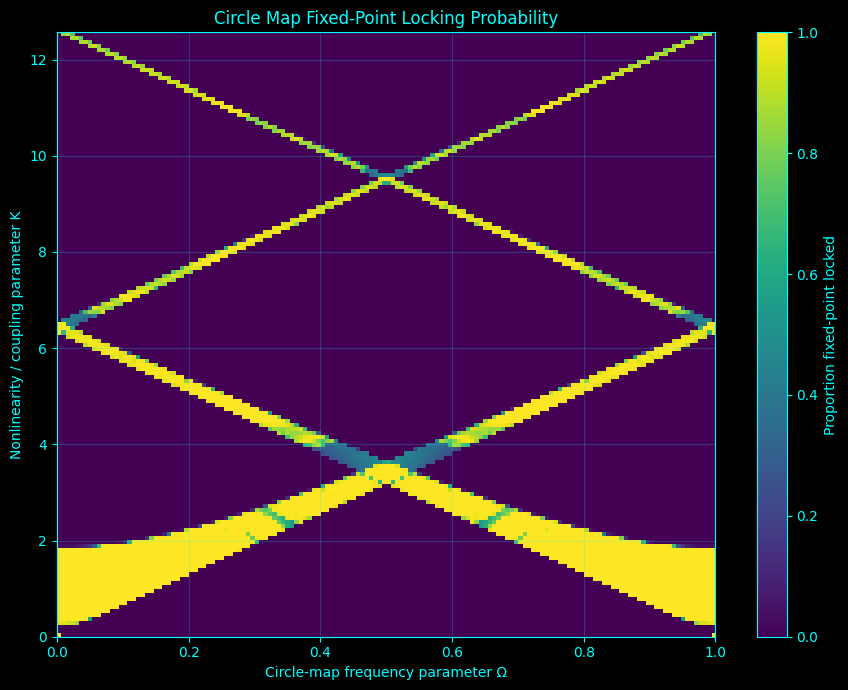

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_circle_map/plots/circle_map_fixed_point_locking_heatmap.png


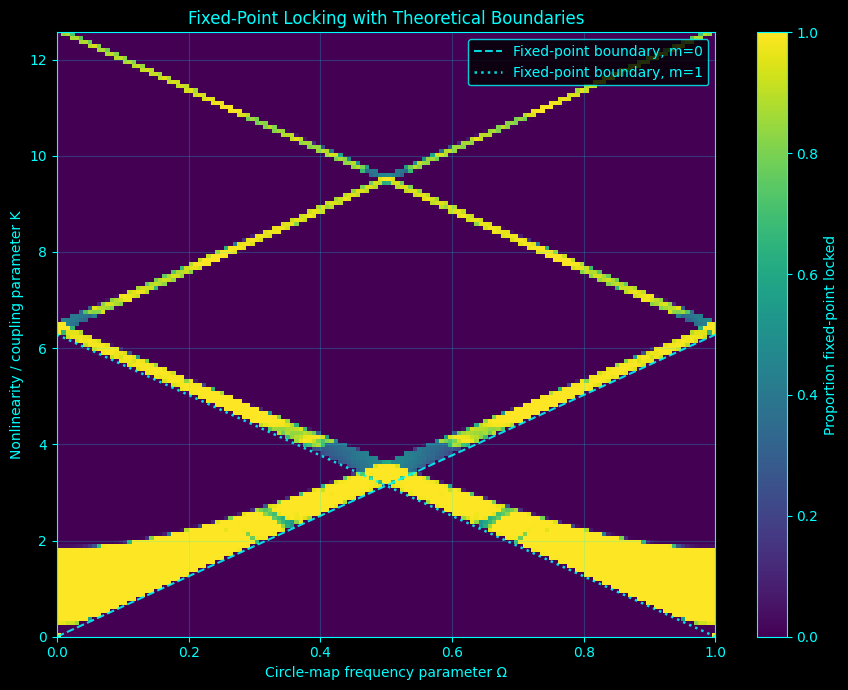

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_circle_map/plots/circle_map_fixed_point_locking_with_boundaries.png


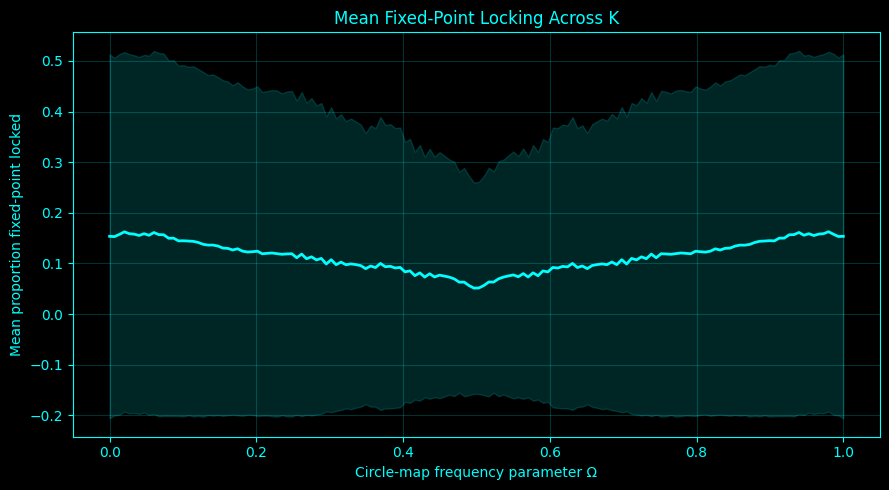

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_circle_map/plots/mean_fixed_point_locking_across_K.png


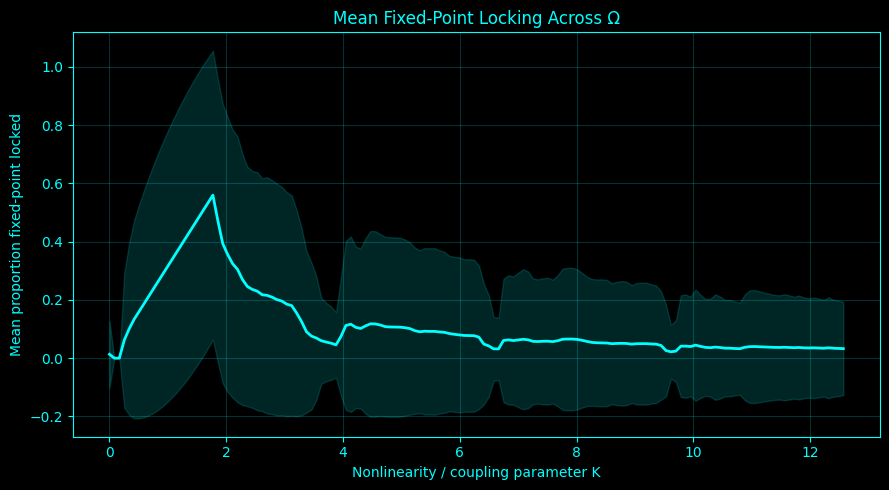

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_circle_map/plots/mean_fixed_point_locking_across_omega.png


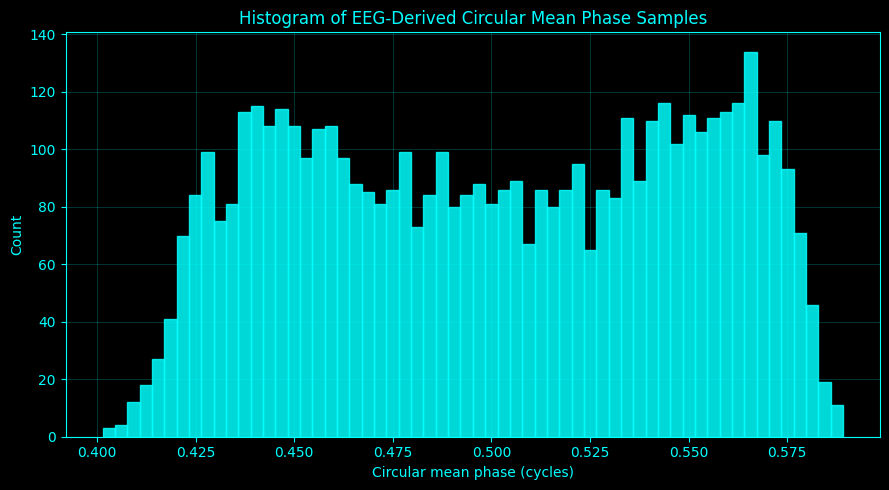

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_circle_map/plots/eeg_derived_mean_phase_histogram.png


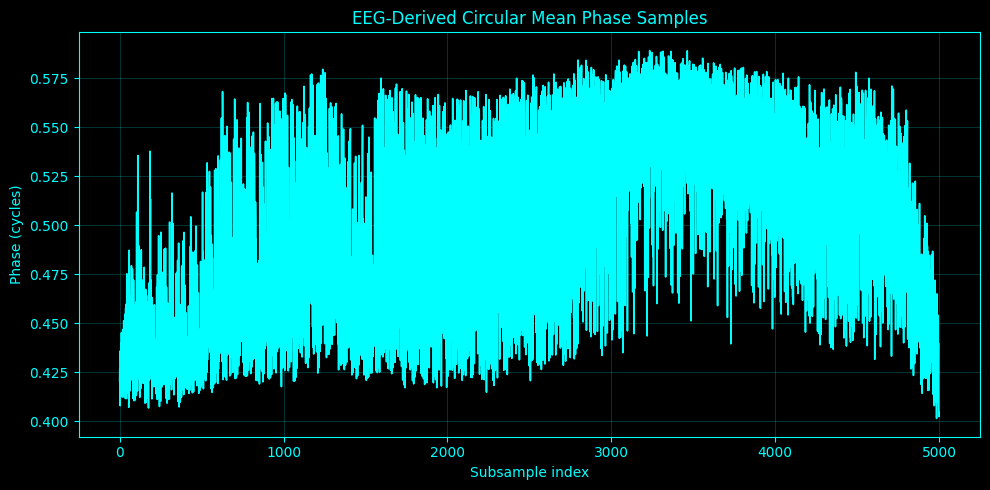

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_circle_map/plots/eeg_derived_mean_phase_samples.png


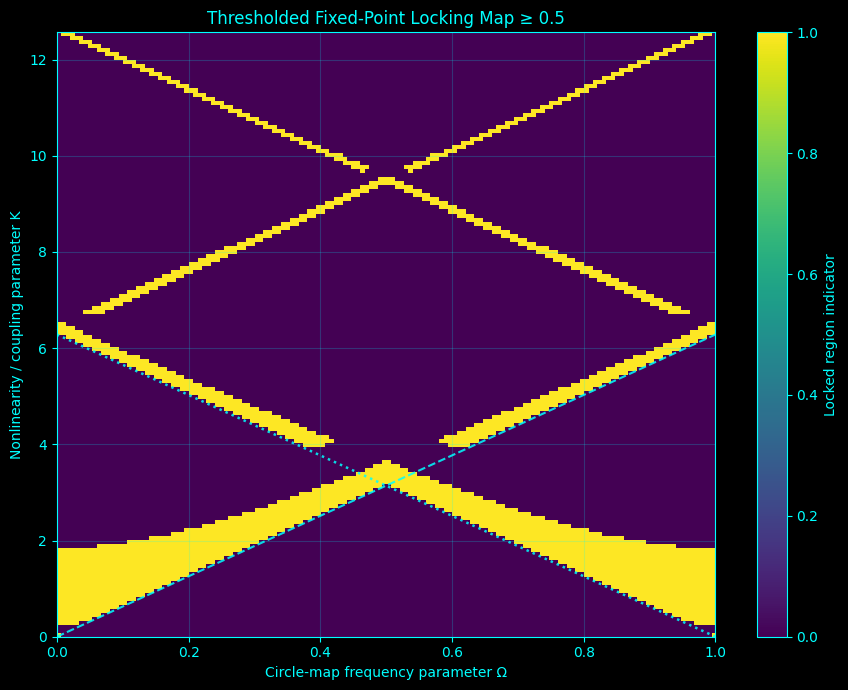

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_circle_map/plots/thresholded_fixed_point_locking_map.png

Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_circle_map/circle_map_fixed_point_locking_results.npz
Saved grid CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_circle_map/circle_map_fixed_point_locking_grid.csv
Saved summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_circle_map/circle_map_fixed_point_locking_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_circle_map/plots


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "arnold_tongues_circle_map")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Grid resolution
n_omega = 150
n_K = 150
omegas = np.linspace(0.0, 1.0, n_omega)
K_values = np.linspace(0.0, 4.0 * np.pi, n_K)

# Circle map iteration controls
iterations = 60
tol = 1e-6

# Phase subsampling for speed
# Increase max_phase_samples if you want higher fidelity and can afford more runtime.
max_phase_samples = 5000

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)

    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, alpha=0.20, color=ACCENT)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)

    cbar.ax.yaxis.label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=220):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")

    if x.shape[1] == n_channels_expected:
        return x

    if x.shape[0] == n_channels_expected:
        return x.T

    raise ValueError(f"Unexpected EEG shape: {x.shape}")


def to_cycle_phase(rad_phase):
    """
    Convert radians to phase on [0, 1).
    """
    return np.mod(rad_phase / (2.0 * np.pi), 1.0)


def circular_mean_phase(phases_rad, axis=1):
    """
    Circular mean phase in radians.
    """
    z = np.mean(np.exp(1j * phases_rad), axis=axis)
    return np.angle(z)


def uniform_subsample(x, max_n):
    x = np.asarray(x)

    if len(x) <= max_n:
        return x

    idx = np.linspace(0, len(x) - 1, max_n).astype(int)
    return x[idx]


def circle_map(theta, omega, K):
    """
    Standard circle map on phase cycles [0, 1).

    theta_{n+1} = theta_n + Omega - (K / 2pi) sin(2pi theta_n) mod 1
    """
    theta_next = theta + omega - (K / (2.0 * np.pi)) * np.sin(2.0 * np.pi * theta)
    return np.mod(theta_next, 1.0)


def wrapped_cycle_distance(a, b):
    """
    Shortest distance on the unit circle in cycle coordinates.
    """
    return np.abs(((a - b + 0.5) % 1.0) - 0.5)


def fixed_point_locked_proportion_row(K, omegas, phases, iterations=60, tol=1e-6):
    """
    Vectorized over all omegas for one fixed K.
    Also vectorized over all initial phases.

    This returns the proportion of EEG-derived initial phase samples that
    end near a fixed point according to the final one-step wrapped distance.

    This is fixed-point locking, not full p:q rotation-number Arnold tongues.

    Returns
    -------
    proportions : shape (n_omega,)
    """
    omegas = np.asarray(omegas, dtype=float)
    phases = np.asarray(phases, dtype=float)

    # theta shape: (n_omega, n_phase)
    theta = np.broadcast_to(phases[None, :], (len(omegas), len(phases))).copy()
    omega_col = omegas[:, None]

    for _ in range(iterations):
        theta_next = circle_map(theta, omega_col, K)
        theta = theta_next

    # Check final one-step movement
    theta_next = circle_map(theta, omega_col, K)
    final_delta = wrapped_cycle_distance(theta_next, theta)

    locked = final_delta < tol
    return locked.mean(axis=1)

# -------------------------------------------------------
# LOAD EEG SEGMENT
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channels))
EEG_segment = EEG_data[start_idx:end_idx, :]

n_samples, n_channels = EEG_segment.shape

print(f"Loaded EEG segment: {n_samples} samples x {n_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# -------------------------------------------------------
# PHASE EXTRACTION
# -------------------------------------------------------
analytic_signal = hilbert(EEG_segment, axis=0)
inst_phase_rad = np.angle(analytic_signal)

# Circular mean across channels
avg_phase_rad = circular_mean_phase(inst_phase_rad, axis=1)
avg_phase_cycles = to_cycle_phase(avg_phase_rad)

# Uniform subsample for speed
avg_phase_cycles_sub = uniform_subsample(avg_phase_cycles, max_phase_samples)

print(f"Original phase samples: {len(avg_phase_cycles)}")
print(f"Using phase samples:    {len(avg_phase_cycles_sub)}")

# -------------------------------------------------------
# FIXED-POINT LOCKING GRID COMPUTATION
# -------------------------------------------------------
locked = np.zeros((len(K_values), len(omegas)), dtype=float)

for i, K in enumerate(K_values):
    locked[i, :] = fixed_point_locked_proportion_row(
        K=K,
        omegas=omegas,
        phases=avg_phase_cycles_sub,
        iterations=iterations,
        tol=tol
    )

    if (i + 1) % 10 == 0 or i == 0 or i == len(K_values) - 1:
        print(f"Processed K row {i + 1}/{len(K_values)}")

# -------------------------------------------------------
# SAVE RESULTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "circle_map_fixed_point_locking_results.npz")

np.savez_compressed(
    npz_path,
    locked=locked,
    omegas=omegas,
    K_values=K_values,
    avg_phase_cycles_sub=avg_phase_cycles_sub,
    avg_phase_cycles_full=avg_phase_cycles,
    iterations=iterations,
    tol=tol,
    max_phase_samples=max_phase_samples,
    eeg_channels=np.array(eeg_channels, dtype=object),
    sampling_rate=sampling_rate,
    start_time=start_time,
    end_time=end_time,
)

grid_rows = []

for i, K in enumerate(K_values):
    for j, omega in enumerate(omegas):
        grid_rows.append({
            "Omega": float(omega),
            "K": float(K),
            "proportion_fixed_point_locked": float(locked[i, j]),
        })

grid_df = pd.DataFrame(grid_rows)
grid_csv = os.path.join(out_dir, "circle_map_fixed_point_locking_grid.csv")
grid_df.to_csv(grid_csv, index=False)

summary_txt = os.path.join(out_dir, "circle_map_fixed_point_locking_summary.txt")

with open(summary_txt, "w") as f:
    f.write("Circle Map Fixed-Point Locking Using EEG-Derived Mean Phase\n")
    f.write("==========================================================\n\n")
    f.write("Interpretation:\n")
    f.write("  This computes fixed-point locking probability for the circle map.\n")
    f.write("  It does not compute full p:q Arnold tongues via rotation numbers.\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Channels: {n_channels}\n")
    f.write(f"Omega range: [{omegas.min()}, {omegas.max()}] with {len(omegas)} points\n")
    f.write(f"K range: [{K_values.min()}, {K_values.max()}] with {len(K_values)} points\n")
    f.write(f"Iterations: {iterations}\n")
    f.write(f"Tolerance: {tol}\n")
    f.write(f"Original phase samples: {len(avg_phase_cycles)}\n")
    f.write(f"Used phase samples: {len(avg_phase_cycles_sub)}\n")

# -------------------------------------------------------
# DIAGNOSTICS
# -------------------------------------------------------
locked_min = float(np.nanmin(locked))
locked_max = float(np.nanmax(locked))
locked_mean = float(np.nanmean(locked))

phase_min = float(np.nanmin(avg_phase_cycles_sub))
phase_max = float(np.nanmax(avg_phase_cycles_sub))
phase_mean = float(np.nanmean(avg_phase_cycles_sub))
phase_std = float(np.nanstd(avg_phase_cycles_sub))

print("\nFixed-point locking diagnostics:")
print(f"  locked min  = {locked_min:.6f}")
print(f"  locked max  = {locked_max:.6f}")
print(f"  locked mean = {locked_mean:.6f}")

print("\nEEG-derived phase diagnostics:")
print(f"  phase min   = {phase_min:.6f} cycles")
print(f"  phase max   = {phase_max:.6f} cycles")
print(f"  phase mean  = {phase_mean:.6f} cycles")
print(f"  phase std   = {phase_std:.6f} cycles")

print(
    "\nNOTE: These plots show fixed-point locking probability for the circle map. "
    "They do not estimate full p:q Arnold tongues via rotation numbers."
)

# -------------------------------------------------------
# PLOT 1: FIXED-POINT LOCKING HEATMAP
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    locked,
    extent=[omegas.min(), omegas.max(), K_values.min(), K_values.max()],
    origin="lower",
    aspect="auto",
    vmin=0.0,
    vmax=1.0,
    interpolation="nearest"
)

ax.set_title("Circle Map Fixed-Point Locking Probability")
ax.set_xlabel("Circle-map frequency parameter Ω")
ax.set_ylabel("Nonlinearity / coupling parameter K")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Proportion fixed-point locked")
style_colorbar(cbar)

plot1_path = os.path.join(plots_dir, "circle_map_fixed_point_locking_heatmap.png")
save_show_close(fig, plot1_path)

# -------------------------------------------------------
# PLOT 2: THEORETICAL FIXED-POINT EXISTENCE OVERLAY
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    locked,
    extent=[omegas.min(), omegas.max(), K_values.min(), K_values.max()],
    origin="lower",
    aspect="auto",
    vmin=0.0,
    vmax=1.0,
    interpolation="nearest"
)

omega_line = np.linspace(omegas.min(), omegas.max(), 1000)

# For fixed points modulo 1:
# |Omega - m| <= K / (2pi)
# For Omega in [0, 1], main branches are m=0 and m=1.
K_boundary_m0 = 2.0 * np.pi * np.abs(omega_line - 0.0)
K_boundary_m1 = 2.0 * np.pi * np.abs(omega_line - 1.0)

ax.plot(
    omega_line,
    K_boundary_m0,
    color=ACCENT,
    linestyle="--",
    linewidth=1.5,
    alpha=0.85,
    label="Fixed-point boundary, m=0"
)

ax.plot(
    omega_line,
    K_boundary_m1,
    color=ACCENT,
    linestyle=":",
    linewidth=1.8,
    alpha=0.85,
    label="Fixed-point boundary, m=1"
)

ax.set_ylim(K_values.min(), K_values.max())

ax.set_title("Fixed-Point Locking with Theoretical Boundaries")
ax.set_xlabel("Circle-map frequency parameter Ω")
ax.set_ylabel("Nonlinearity / coupling parameter K")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT)

for text in leg.get_texts():
    text.set_color(ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Proportion fixed-point locked")
style_colorbar(cbar)

plot2_path = os.path.join(plots_dir, "circle_map_fixed_point_locking_with_boundaries.png")
save_show_close(fig, plot2_path)

# -------------------------------------------------------
# PLOT 3: MEAN FIXED-POINT LOCKING ACROSS K
# For each Ω, average over all K values.
# -------------------------------------------------------
mean_locked_over_K = np.nanmean(locked, axis=0)
std_locked_over_K = np.nanstd(locked, axis=0)

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    omegas,
    mean_locked_over_K,
    color=ACCENT,
    linewidth=2.0
)

ax.fill_between(
    omegas,
    mean_locked_over_K - std_locked_over_K,
    mean_locked_over_K + std_locked_over_K,
    color=ACCENT,
    alpha=0.15
)

ax.set_title("Mean Fixed-Point Locking Across K")
ax.set_xlabel("Circle-map frequency parameter Ω")
ax.set_ylabel("Mean proportion fixed-point locked")

plot3_path = os.path.join(plots_dir, "mean_fixed_point_locking_across_K.png")
save_show_close(fig, plot3_path)

# -------------------------------------------------------
# PLOT 4: MEAN FIXED-POINT LOCKING ACROSS OMEGA
# For each K, average over all Ω values.
# -------------------------------------------------------
mean_locked_over_omega = np.nanmean(locked, axis=1)
std_locked_over_omega = np.nanstd(locked, axis=1)

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    K_values,
    mean_locked_over_omega,
    color=ACCENT,
    linewidth=2.0
)

ax.fill_between(
    K_values,
    mean_locked_over_omega - std_locked_over_omega,
    mean_locked_over_omega + std_locked_over_omega,
    color=ACCENT,
    alpha=0.15
)

ax.set_title("Mean Fixed-Point Locking Across Ω")
ax.set_xlabel("Nonlinearity / coupling parameter K")
ax.set_ylabel("Mean proportion fixed-point locked")

plot4_path = os.path.join(plots_dir, "mean_fixed_point_locking_across_omega.png")
save_show_close(fig, plot4_path)

# -------------------------------------------------------
# PLOT 5: EEG-DERIVED MEAN PHASE HISTOGRAM
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
style_ax(ax)

ax.hist(
    avg_phase_cycles_sub,
    bins=60,
    color=ACCENT,
    edgecolor=ACCENT,
    alpha=0.85
)

ax.set_title("Histogram of EEG-Derived Circular Mean Phase Samples")
ax.set_xlabel("Circular mean phase (cycles)")
ax.set_ylabel("Count")

plot5_path = os.path.join(plots_dir, "eeg_derived_mean_phase_histogram.png")
save_show_close(fig, plot5_path)

# -------------------------------------------------------
# PLOT 6: EEG-DERIVED PHASE SAMPLES OVER SUBSAMPLE INDEX
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    np.arange(len(avg_phase_cycles_sub)),
    avg_phase_cycles_sub,
    color=ACCENT,
    linewidth=1.2
)

ax.set_title("EEG-Derived Circular Mean Phase Samples")
ax.set_xlabel("Subsample index")
ax.set_ylabel("Phase (cycles)")

plot6_path = os.path.join(plots_dir, "eeg_derived_mean_phase_samples.png")
save_show_close(fig, plot6_path)

# -------------------------------------------------------
# PLOT 7: THRESHOLDED LOCKING MAP
# -------------------------------------------------------
lock_threshold = 0.5
locked_binary = locked >= lock_threshold

fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    locked_binary.astype(float),
    extent=[omegas.min(), omegas.max(), K_values.min(), K_values.max()],
    origin="lower",
    aspect="auto",
    vmin=0.0,
    vmax=1.0,
    interpolation="nearest"
)

ax.plot(
    omega_line,
    K_boundary_m0,
    color=ACCENT,
    linestyle="--",
    linewidth=1.5,
    alpha=0.85
)

ax.plot(
    omega_line,
    K_boundary_m1,
    color=ACCENT,
    linestyle=":",
    linewidth=1.8,
    alpha=0.85
)

ax.set_ylim(K_values.min(), K_values.max())

ax.set_title(f"Thresholded Fixed-Point Locking Map ≥ {lock_threshold}")
ax.set_xlabel("Circle-map frequency parameter Ω")
ax.set_ylabel("Nonlinearity / coupling parameter K")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Locked region indicator")
style_colorbar(cbar)

plot7_path = os.path.join(plots_dir, "thresholded_fixed_point_locking_map.png")
save_show_close(fig, plot7_path)

# -------------------------------------------------------
# APPEND PLOTTING DIAGNOSTICS TO SUMMARY
# -------------------------------------------------------
with open(summary_txt, "a") as f:
    f.write("\n\nPlotting diagnostics\n")
    f.write("====================\n")
    f.write("Interpretation: fixed-point locking probability from the circle map.\n")
    f.write("This is not a full rotation-number Arnold tongue calculation.\n\n")
    f.write(f"locked min  = {locked_min:.10f}\n")
    f.write(f"locked max  = {locked_max:.10f}\n")
    f.write(f"locked mean = {locked_mean:.10f}\n")
    f.write(f"phase min   = {phase_min:.10f} cycles\n")
    f.write(f"phase max   = {phase_max:.10f} cycles\n")
    f.write(f"phase mean  = {phase_mean:.10f} cycles\n")
    f.write(f"phase std   = {phase_std:.10f} cycles\n")
    f.write(f"lock threshold for binary map = {lock_threshold:.4f}\n")

print(f"\nSaved NPZ: {npz_path}")
print(f"Saved grid CSV: {grid_csv}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

# Arnold tongues rotations

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>The given code explores the interaction between EEG data and a simplified dynamical system known as the Circle Map. The aim is to compute the average rotation numbers, which is a crucial parameter in understanding synchronization properties, for each EEG channel across a range of parameters in the Circle Map.</p>
        <h2>Circle Map</h2>
        <p>The Circle Map is defined as:</p>
        \[ \theta_{n+1} = \theta_n + \Omega - \frac{K}{2\pi} \sin(2\pi \theta_n) \]
        <p>where \( \theta_n \) is the phase, \( \Omega \) is the constant frequency, and \( K \) is the coupling strength. This map is utilized to model simple oscillatory systems and to analyze synchronization phenomena.</p>
        <h2>EEG Data Processing</h2>
        <p>The EEG data is loaded and organized into a dictionary for easier access. The initial phase for the Circle Map is determined from the mean value of the EEG data for each channel.</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Average Rotation Number Calculation</h2>
        <p>The average rotation number is a metric of the long-term behavior of the phase in the Circle Map. It is computed across all EEG channels for a grid of \( \Omega \) and \( K \) values, by iterating the Circle Map and averaging the differences in phase over a specified number of iterations, post a transient period.</p>
        <h2>Visualization of Results</h2>
        <p>The results are visualized in a grid of plots, one for each EEG channel. Each plot displays the average rotation number as a function of \( \Omega \) and \( K \), using a custom colormap to indicate the rotation number value. This visualization aids in understanding how the EEG data interacts with the Circle Map across different channels and parameters.</p>
        <h2>Conclusion</h2>
        <p>This code enables a comprehensive analysis of the synchronization properties of EEG data in relation to the Circle Map. By examining the average rotation number across a multitude of parameters and channels, it provides insights into the complex dynamics underlying the EEG data and its synchronization behavior in a simplified dynamical setting.</p>
    </div>
</div>


Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec

Initial circle-map phases per channel (from circular mean EEG phase):
   channel    theta0_rad  theta0_cycles
0      Fp1  3.141593e+00   5.000000e-01
1      Fpz -3.141593e+00   5.000000e-01
2      Fp2 -3.141593e+00   5.000000e-01
3       F7  6.995197e-09   1.113320e-09
4       F3 -1.649251e-02   9.973751e-01
5       Fz -3.141593e+00   5.000000e-01
6       F4 -3.141582e+00   5.000017e-01
7       F8 -2.258127e-08   1.000000e+00
8      FC5 -1.317014e-09   1.000000e+00
9      FC1 -1.340868e-08   1.000000e+00
10     FC2 -3.141593e+00   5.000000e-01
11     FC6 -1.424977e-08   1.000000e+00
12      M1 -3.141535e+00   5.000092e-01
13      T7 -3.141593e+00   5.000000e-01
14      C3  3.141587e+00   4.999991e-01
15      Cz -4.179260e-08   1.000000e+00
16      C4 -1.755949e-07   1.000000e+00
17      T8 -2.668272e-06   9.999996e-01
18      M2 -3.141593e+00   5.000000e-01
19     CP5 -6.191369e-08   1.000000e+00
20     C

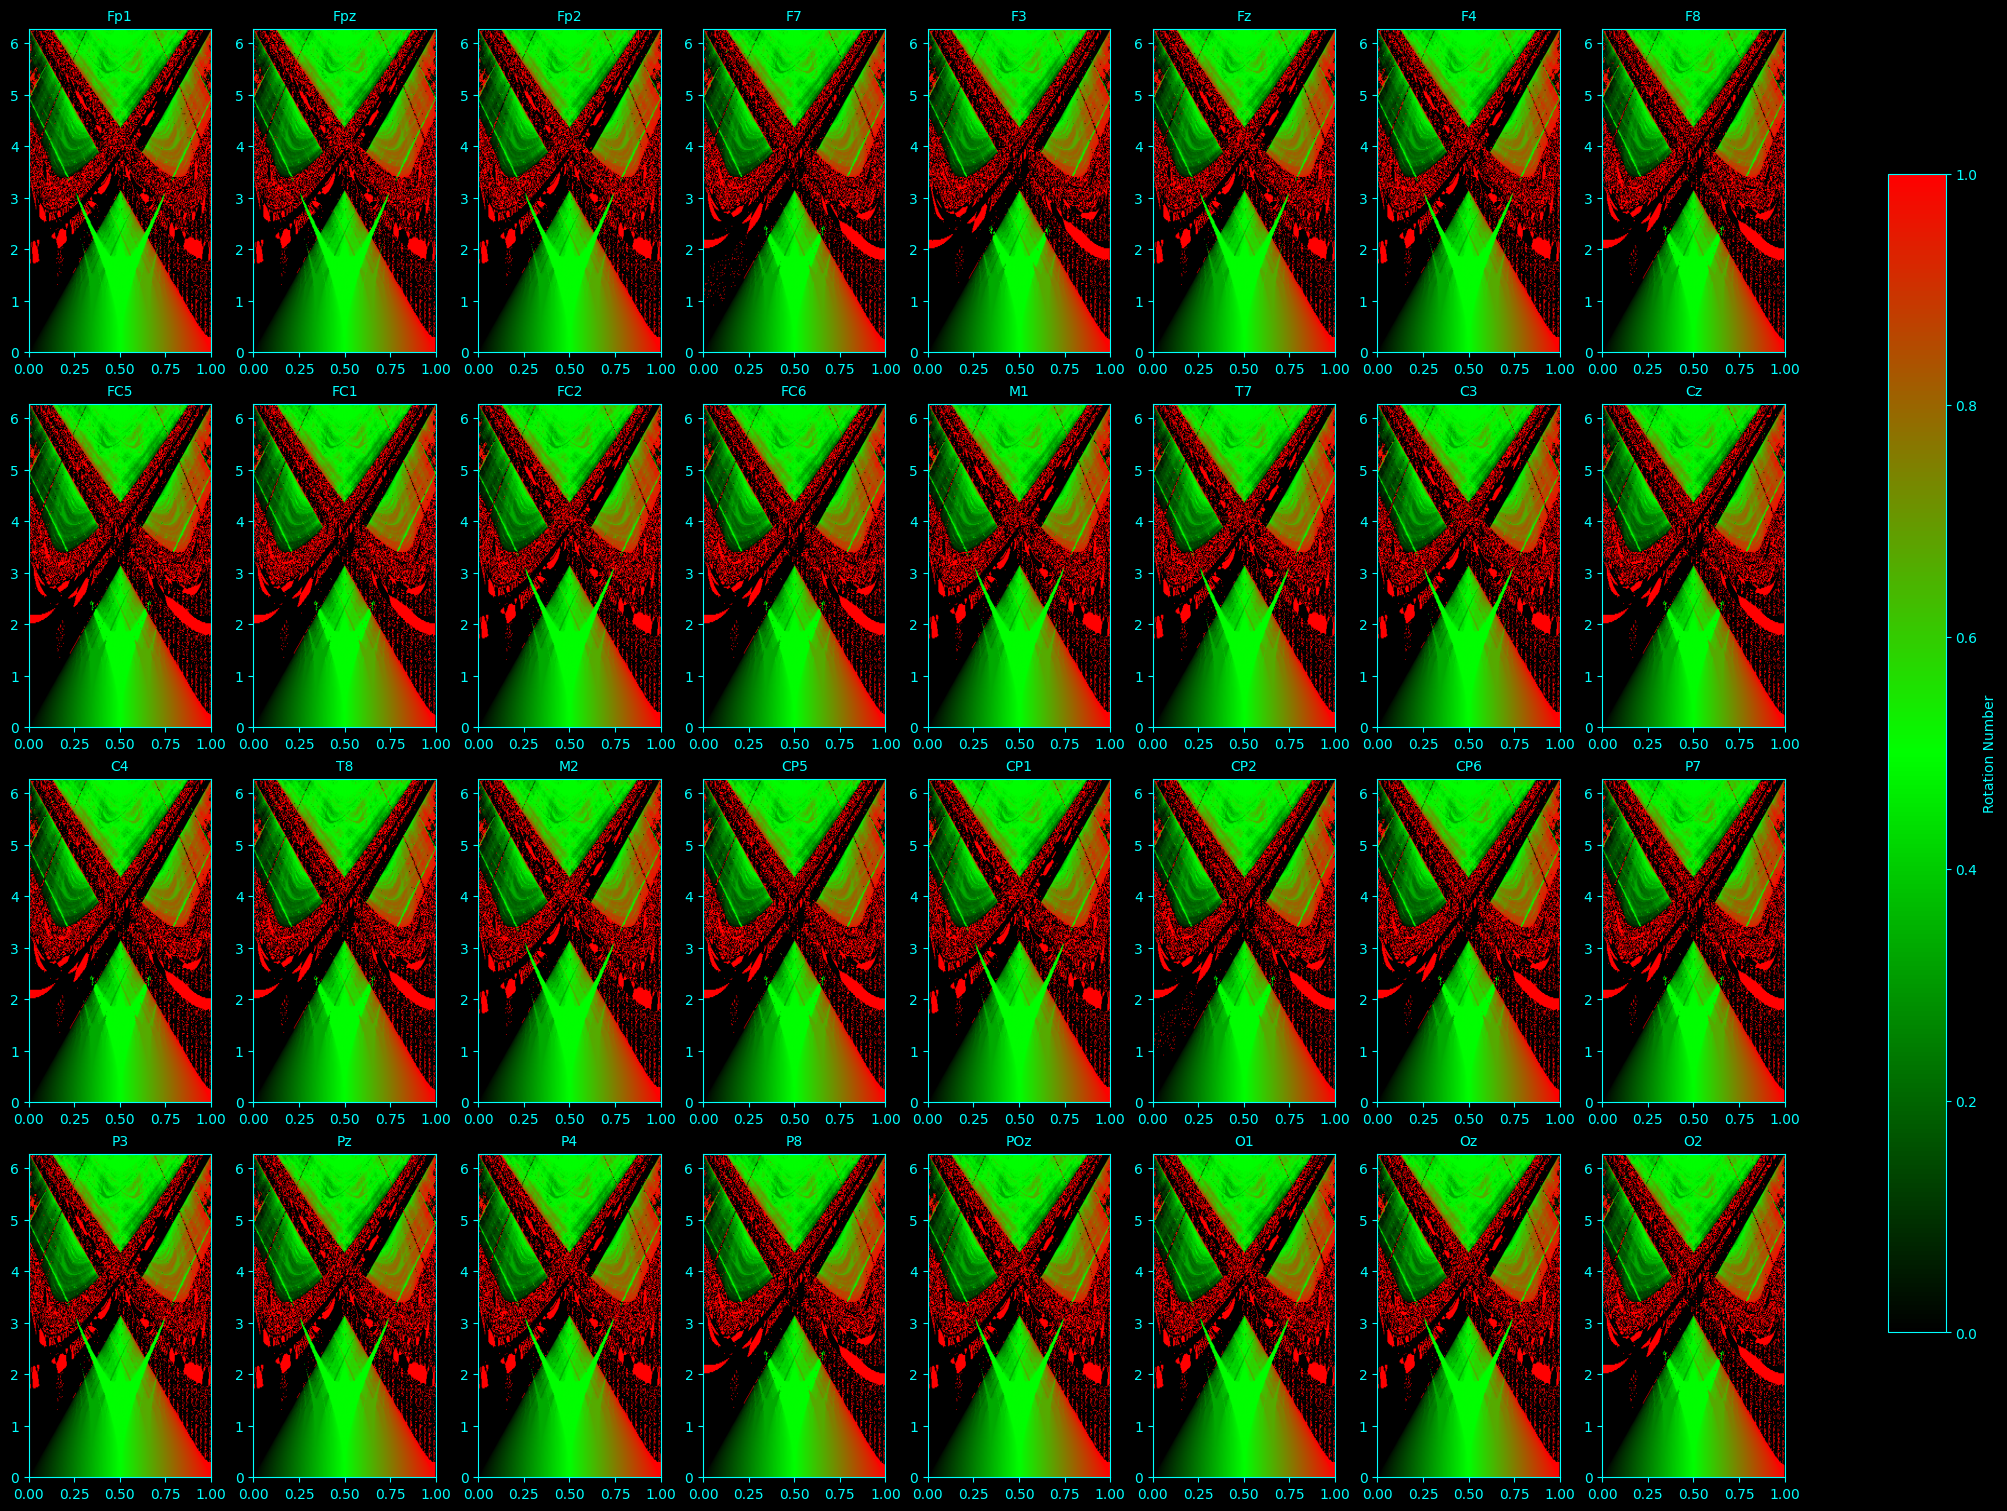

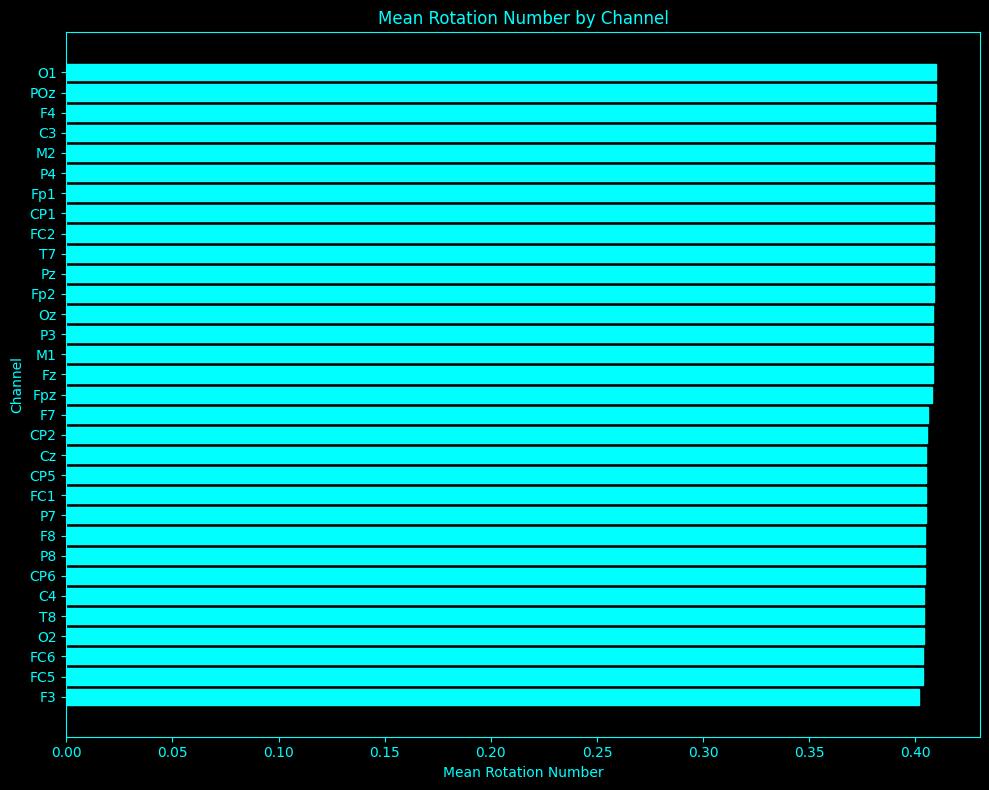

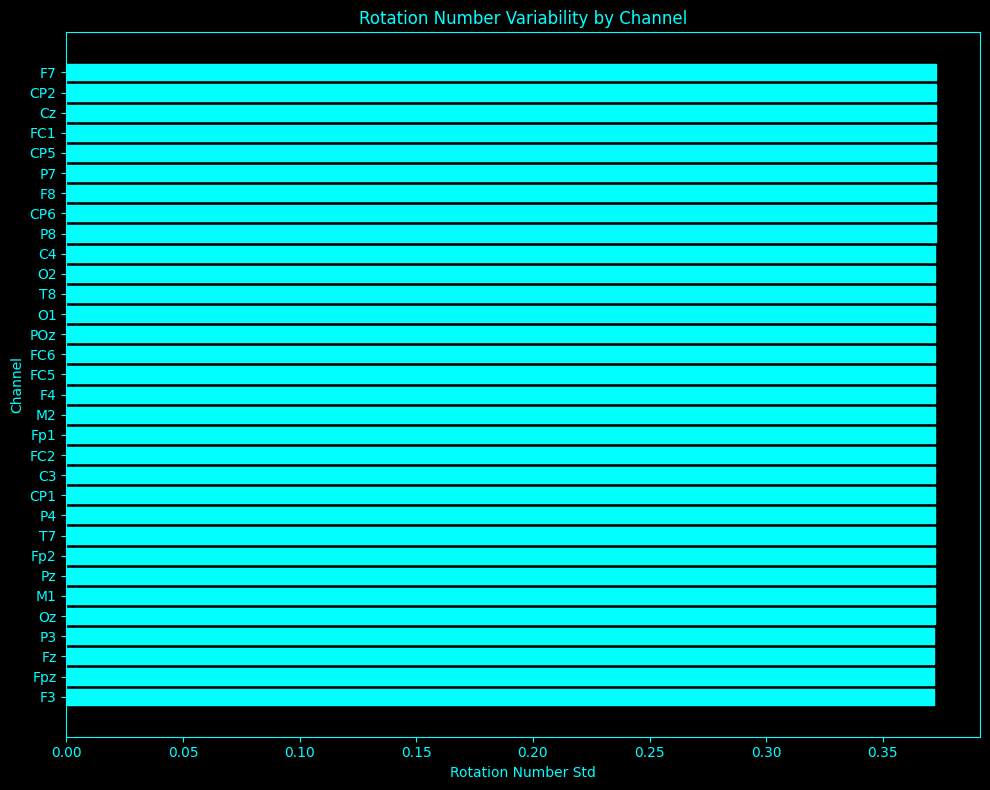

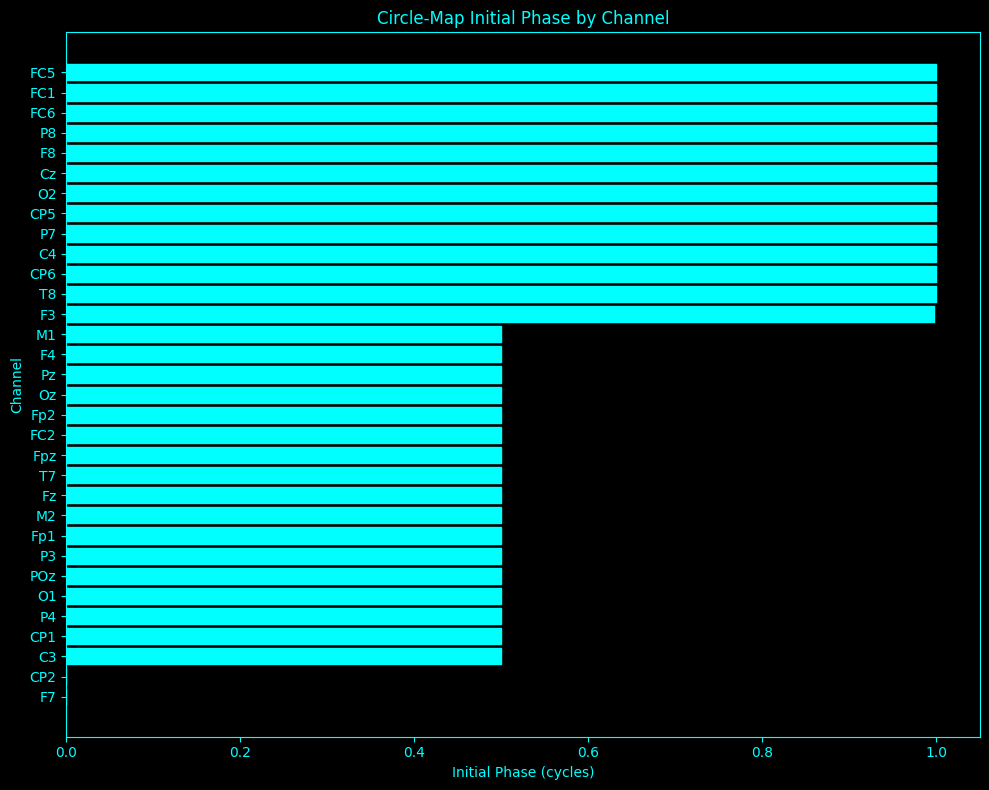


Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_rotation_numbers/rotation_numbers_results.npz
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_rotation_numbers/rotation_numbers_summary.csv
Saved theta0 CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_rotation_numbers/rotation_number_initial_conditions.csv
Saved summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_rotation_numbers/rotation_numbers_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_rotation_numbers/plots


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.signal import hilbert

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "arnold_tongues_rotation_numbers")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Grid
n_omega = 300
n_K = 300
omegas = np.linspace(0.0, 1.0, n_omega)
K_values = np.linspace(0.0, 2.0 * np.pi, n_K)

# Circle-map iteration controls
iterations = 1000
transient = 100

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")

    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T

    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def circular_mean_phase(phases_rad, axis=0):
    z = np.mean(np.exp(1j * phases_rad), axis=axis)
    return np.angle(z)

def to_cycle_phase(rad_phase):
    return np.mod(rad_phase / (2.0 * np.pi), 1.0)

def circle_map_lift(theta, omega, K):
    """
    Lifted circle map.
    Do NOT reduce modulo 1 here; rotation number needs the lifted increment.
    """
    return theta + omega - (K / (2.0 * np.pi)) * np.sin(2.0 * np.pi * theta)

def average_rotation_number_grid(omegas, K, theta0, iterations=1000, transient=100):
    """
    Vectorized over all omega values for one fixed K and one channel.
    Uses the lifted map and computes:
        rho = mean increment per iterate mod 1
            = ((theta_T - theta_0) / T) mod 1
    """
    omegas = np.asarray(omegas, dtype=float)
    theta = np.full_like(omegas, fill_value=float(theta0), dtype=float)

    # Transient
    for _ in range(transient):
        theta = circle_map_lift(theta, omegas, K)

    theta_start = theta.copy()

    # Measurement window
    for _ in range(iterations):
        theta = circle_map_lift(theta, omegas, K)

    rho = ((theta - theta_start) / max(iterations, 1)) % 1.0
    return rho

# -------------------------------------------------------
# LOAD EEG SEGMENT
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channels))
EEG_segment = EEG_data[start_idx:end_idx, :]

n_samples, n_channels = EEG_segment.shape
print(f"Loaded EEG segment: {n_samples} samples x {n_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# -------------------------------------------------------
# CHANNEL-WISE INITIAL CONDITIONS FROM EEG PHASE
# -------------------------------------------------------
# Better than mean amplitude: use channel-wise circular mean phase
analytic_signal = hilbert(EEG_segment, axis=0)
inst_phase_rad = np.angle(analytic_signal)
theta0_rad = circular_mean_phase(inst_phase_rad, axis=0)
theta0_cycles = to_cycle_phase(theta0_rad)

theta0_df = pd.DataFrame({
    "channel": eeg_channels,
    "theta0_rad": theta0_rad,
    "theta0_cycles": theta0_cycles
})

print("\nInitial circle-map phases per channel (from circular mean EEG phase):")
print(theta0_df)

# -------------------------------------------------------
# COMPUTE ROTATION NUMBERS
# -------------------------------------------------------
rotation_numbers_all = np.zeros((n_channels, len(K_values), len(omegas)), dtype=float)
summary_rows = []

for ch_idx, ch in enumerate(eeg_channels):
    theta0 = theta0_cycles[ch_idx]
    print(f"\nProcessing channel {ch_idx+1}/{n_channels}: {ch} | theta0={theta0:.6f}")

    channel_rho = np.zeros((len(K_values), len(omegas)), dtype=float)

    for i, K in enumerate(K_values):
        channel_rho[i, :] = average_rotation_number_grid(
            omegas=omegas,
            K=K,
            theta0=theta0,
            iterations=iterations,
            transient=transient
        )

        if (i + 1) % 50 == 0 or i == 0 or i == len(K_values) - 1:
            print(f"  K row {i+1}/{len(K_values)}")

    rotation_numbers_all[ch_idx] = channel_rho

    summary_rows.append({
        "channel": ch,
        "theta0_cycles": float(theta0),
        "rotation_mean": float(np.mean(channel_rho)),
        "rotation_std": float(np.std(channel_rho)),
        "rotation_min": float(np.min(channel_rho)),
        "rotation_max": float(np.max(channel_rho)),
    })

summary_df = pd.DataFrame(summary_rows)

# -------------------------------------------------------
# SAVE RESULTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "rotation_numbers_results.npz")
np.savez_compressed(
    npz_path,
    rotation_numbers_all=rotation_numbers_all,
    omegas=omegas,
    K_values=K_values,
    eeg_channels=np.array(eeg_channels, dtype=object),
    theta0_rad=theta0_rad,
    theta0_cycles=theta0_cycles,
    sampling_rate=sampling_rate,
    start_time=start_time,
    end_time=end_time,
    iterations=iterations,
    transient=transient,
)

summary_csv = os.path.join(out_dir, "rotation_numbers_summary.csv")
theta0_csv = os.path.join(out_dir, "rotation_number_initial_conditions.csv")
summary_df.to_csv(summary_csv, index=False)
theta0_df.to_csv(theta0_csv, index=False)

summary_txt = os.path.join(out_dir, "rotation_numbers_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Arnold Tongues Rotation Numbers from Circle Map\n")
    f.write("==============================================\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Channels: {n_channels}\n")
    f.write(f"Omega range: [{omegas.min()}, {omegas.max()}] with {len(omegas)} points\n")
    f.write(f"K range: [{K_values.min()}, {K_values.max()}] with {len(K_values)} points\n")
    f.write(f"Iterations: {iterations}\n")
    f.write(f"Transient: {transient}\n\n")
    f.write("Per-channel summary:\n")
    for _, row in summary_df.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"theta0_cycles={row['theta0_cycles']:.6f}, "
            f"mean={row['rotation_mean']:.6f}, "
            f"std={row['rotation_std']:.6f}, "
            f"min={row['rotation_min']:.6f}, "
            f"max={row['rotation_max']:.6f}\n"
        )

# -------------------------------------------------------
# COLORMAP
# -------------------------------------------------------
# Original spirit: black -> green -> red
cmap = mcolors.LinearSegmentedColormap.from_list(
    "rotation_cmap",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 0.0), (1.0, 0.0, 0.0)],
    N=256
)

# -------------------------------------------------------
# PLOT 1: CONTACT SHEET OF ALL CHANNELS
# -------------------------------------------------------
rows, cols = 4, 8
fig, axs = plt.subplots(rows, cols, figsize=(20, 15), constrained_layout=True, facecolor=BG)

for ax in axs.flat:
    style_ax(ax)

for ax, ch, rot in zip(axs.flat, eeg_channels, rotation_numbers_all):
    im = ax.imshow(
        rot,
        extent=(omegas.min(), omegas.max(), K_values.min(), K_values.max()),
        aspect="auto",
        origin="lower",
        cmap=cmap,
        vmin=0.0,
        vmax=1.0
    )
    ax.set_title(ch, fontsize=10, color=ACCENT)

for idx in range(len(eeg_channels), rows * cols):
    axs.flat[idx].axis("off")

cbar = fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.8)
cbar.set_label("Rotation Number", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot1_path = os.path.join(plots_dir, "rotation_numbers_all_channels_contact_sheet.png")
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: MEAN ROTATION NUMBER PER CHANNEL
# -------------------------------------------------------
plot_df = summary_df.sort_values("rotation_mean", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
style_ax(ax)

ax.barh(
    plot_df["channel"].values,
    plot_df["rotation_mean"].values,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Mean Rotation Number by Channel")
ax.set_xlabel("Mean Rotation Number")
ax.set_ylabel("Channel")

plot2_path = os.path.join(plots_dir, "mean_rotation_number_by_channel.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: ROTATION NUMBER VARIABILITY PER CHANNEL
# -------------------------------------------------------
plot_df = summary_df.sort_values("rotation_std", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
style_ax(ax)

ax.barh(
    plot_df["channel"].values,
    plot_df["rotation_std"].values,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Rotation Number Variability by Channel")
ax.set_xlabel("Rotation Number Std")
ax.set_ylabel("Channel")

plot3_path = os.path.join(plots_dir, "rotation_number_std_by_channel.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: INITIAL CONDITIONS BY CHANNEL
# -------------------------------------------------------
plot_df = theta0_df.sort_values("theta0_cycles", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
style_ax(ax)

ax.barh(
    plot_df["channel"].values,
    plot_df["theta0_cycles"].values,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Circle-Map Initial Phase by Channel")
ax.set_xlabel("Initial Phase (cycles)")
ax.set_ylabel("Channel")

plot4_path = os.path.join(plots_dir, "circle_map_initial_phase_by_channel.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved NPZ: {npz_path}")
print(f"Saved summary CSV: {summary_csv}")
print(f"Saved theta0 CSV: {theta0_csv}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
Bandpass filtering EEG before Hilbert phase: (1.0, 45.0) Hz

Processing channel 1/32: Fp1 | initial phase samples=5000

Processing channel 2/32: Fpz | initial phase samples=5000

Processing channel 3/32: Fp2 | initial phase samples=5000

Processing channel 4/32: F7 | initial phase samples=5000

Processing channel 5/32: F3 | initial phase samples=5000

Processing channel 6/32: Fz | initial phase samples=5000

Processing channel 7/32: F4 | initial phase samples=5000

Processing channel 8/32: F8 | initial phase samples=5000

Processing channel 9/32: FC5 | initial phase samples=5000

Processing channel 10/32: FC1 | initial phase samples=5000

Processing channel 11/32: FC2 | initial phase samples=5000

Processing channel 12/32: FC6 | initial phase samples=5000

Processing channel 13/32: M1 | initial phase samples=5000

Processing channel 14/32: T7 | initial phase samples=5000

Processing channel 15/32: C3 | ini

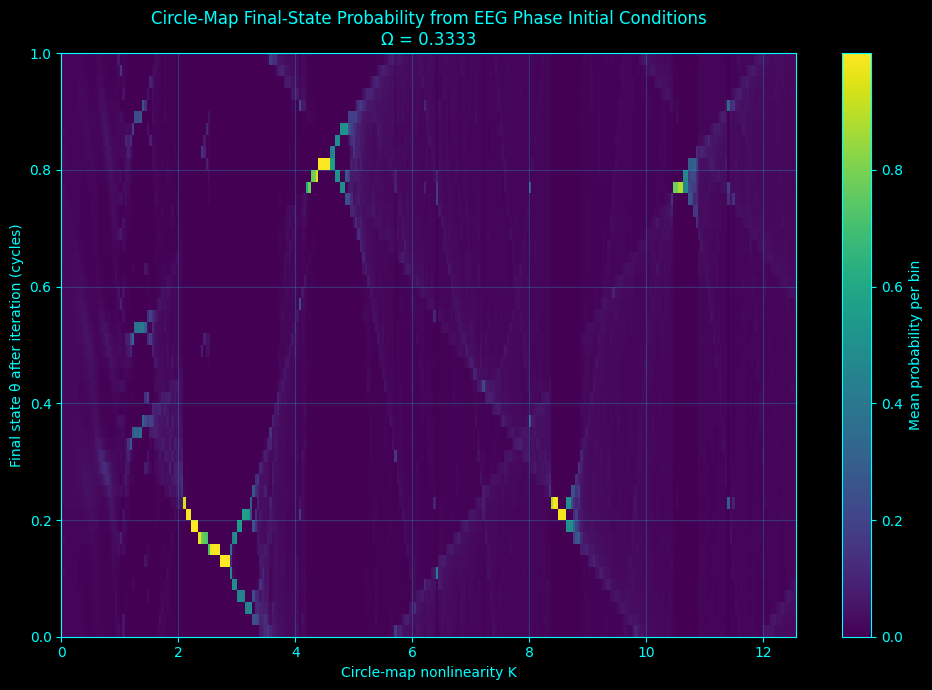

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_converged_density/plots/aggregate_final_state_probability_heatmap.png


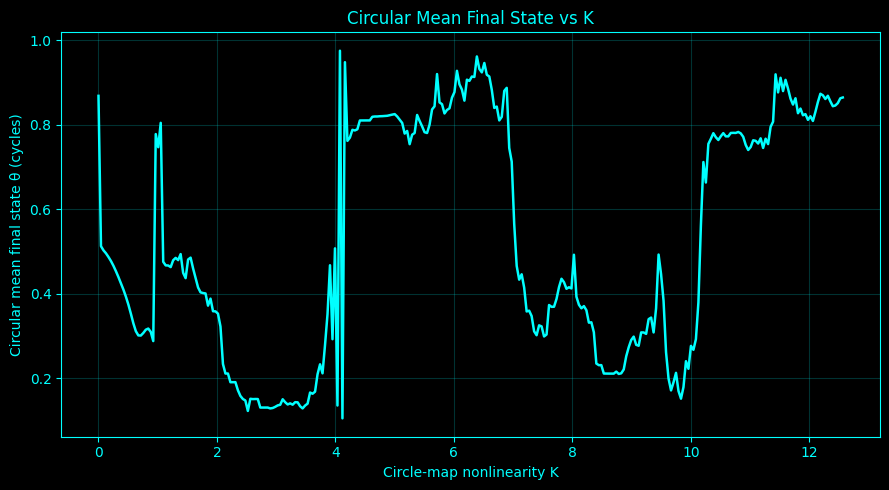

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_converged_density/plots/circular_mean_final_state_vs_K.png


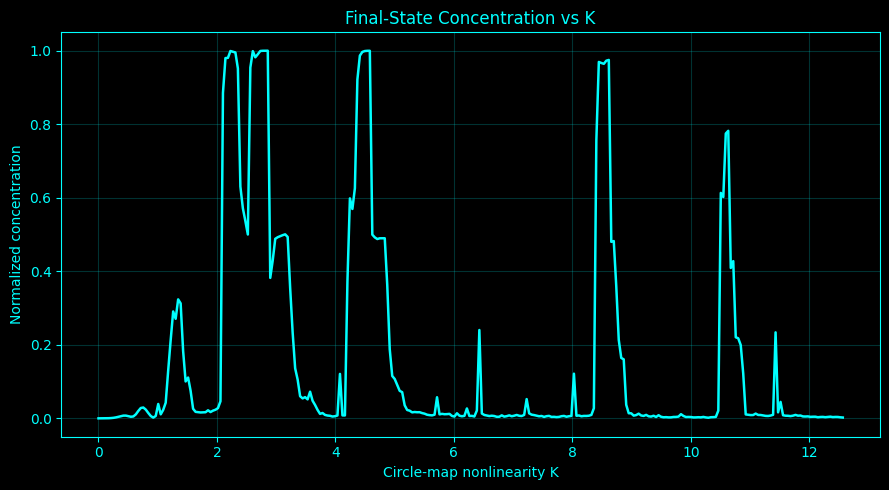

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_converged_density/plots/normalized_concentration_vs_K.png


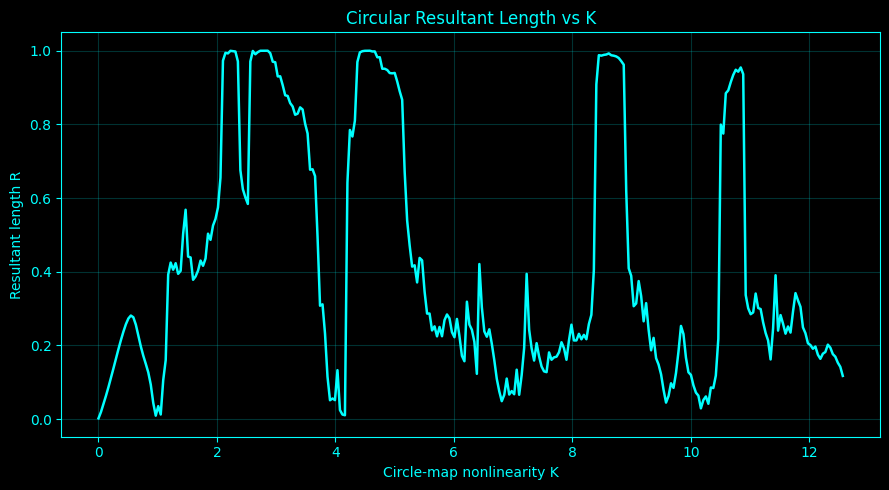

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_converged_density/plots/circular_resultant_length_vs_K.png


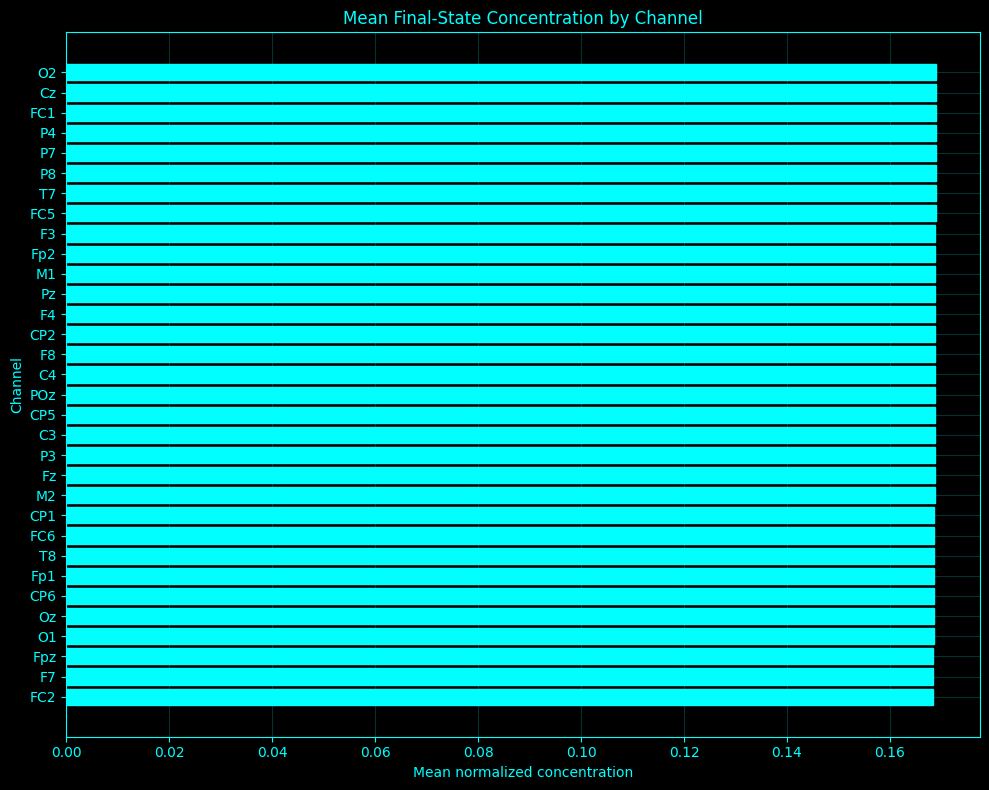

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_converged_density/plots/mean_final_state_concentration_by_channel.png


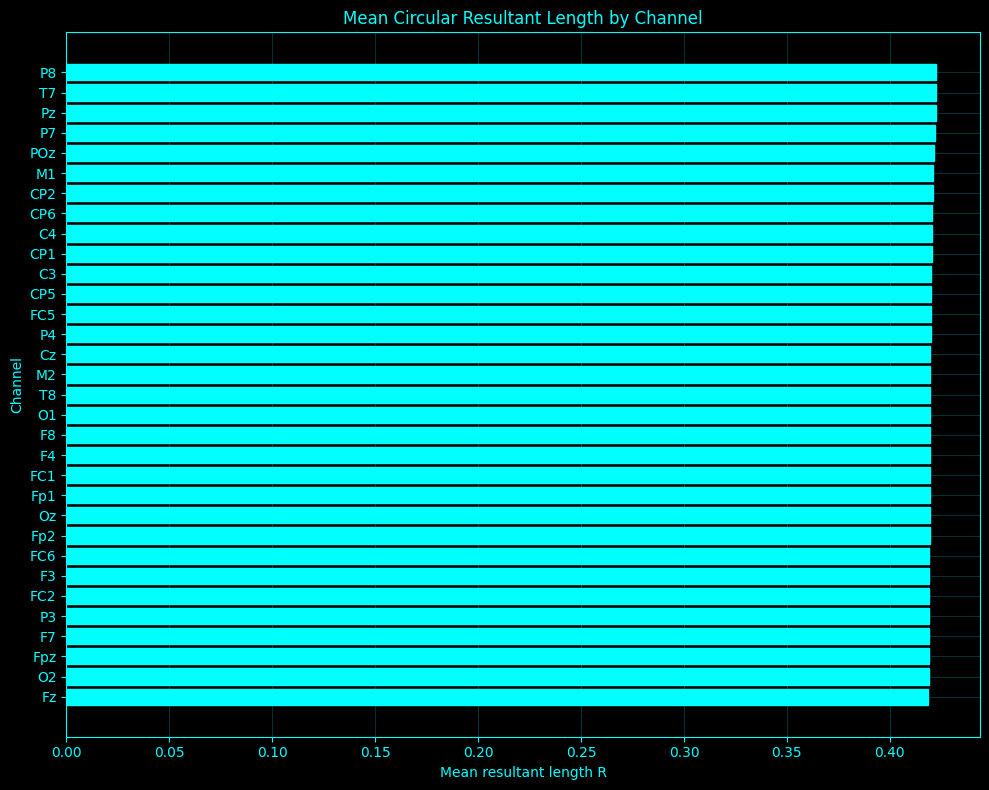

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_converged_density/plots/mean_resultant_length_by_channel.png


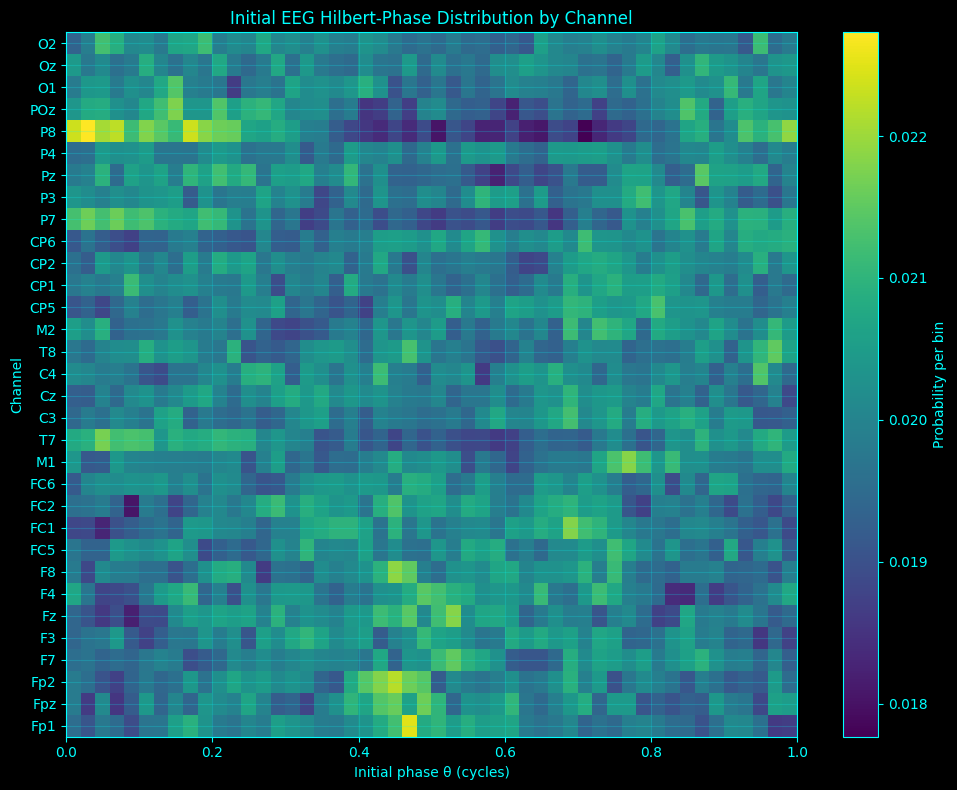

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_converged_density/plots/initial_eeg_phase_distribution_by_channel.png


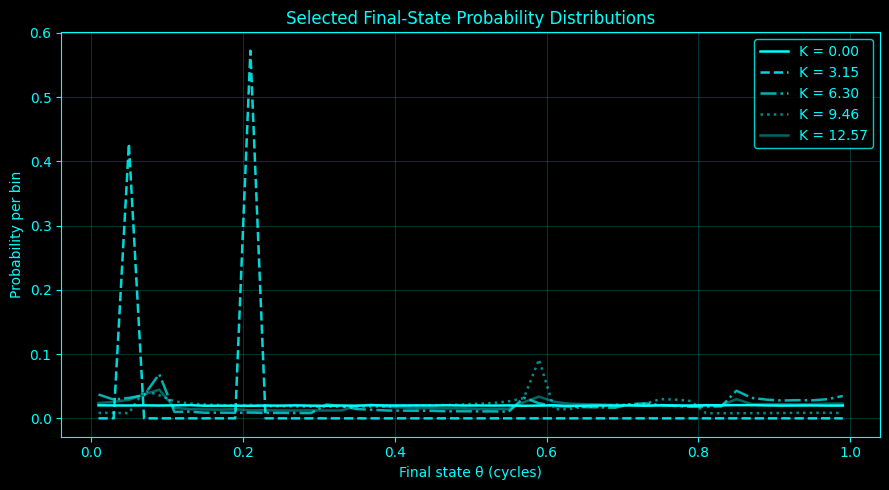

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_converged_density/plots/selected_final_state_distributions.png

Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_converged_density/converged_phase_probability_results.npz
Saved density CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_converged_density/avg_final_state_probability_grid.csv
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_converged_density/converged_phase_channel_summary.csv
Saved summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_converged_density/converged_phase_density_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/arnold_tongues_converged_density/plots


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, hilbert

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "arnold_tongues_converged_density")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# CIRCLE-MAP PARAMETERS
# -------------------------------------------------------
Omega = 1.0 / 3.0
K_values = np.linspace(0.0, 4.0 * np.pi, 300)
iterations = 50

# -------------------------------------------------------
# EEG PHASE EXTRACTION SETTINGS
# -------------------------------------------------------
# Hilbert phase is more meaningful after bandpass filtering.
USE_BANDPASS = True
phase_band = (1.0, 45.0)
filter_order = 4

# -------------------------------------------------------
# HISTOGRAM SETTINGS
# -------------------------------------------------------
n_bins = 50
bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Speed control
max_samples_per_channel = 5000
rng_seed = 42

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)

    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, alpha=0.20, color=ACCENT)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)

    cbar.ax.yaxis.label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=220):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path)

# -------------------------------------------------------
# DATA HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")

    if x.shape[1] == n_channels_expected:
        return x

    if x.shape[0] == n_channels_expected:
        return x.T

    raise ValueError(f"Unexpected EEG shape: {x.shape}")


def bandpass_filter_eeg(x, fs, band, order=4):
    x = np.asarray(x, dtype=float)

    low, high = band
    nyq = 0.5 * fs

    if low <= 0 and high >= nyq:
        return x

    if low <= 0:
        sos = butter(order, high / nyq, btype="lowpass", output="sos")
    elif high >= nyq:
        sos = butter(order, low / nyq, btype="highpass", output="sos")
    else:
        sos = butter(order, [low / nyq, high / nyq], btype="bandpass", output="sos")

    return sosfiltfilt(sos, x, axis=0)


def radians_to_cycles(rad_phase):
    return np.mod(rad_phase / (2.0 * np.pi), 1.0)


def uniform_subsample(x, max_n, rng=None):
    x = np.asarray(x)

    if len(x) <= max_n:
        return x

    if rng is None:
        idx = np.linspace(0, len(x) - 1, max_n).astype(int)
    else:
        idx = np.sort(rng.choice(len(x), size=max_n, replace=False))

    return x[idx]

# -------------------------------------------------------
# CIRCLE MAP HELPERS
# -------------------------------------------------------
def circle_map(theta, Omega, K):
    """
    Standard circle map on phase cycles [0, 1):

        theta_{n+1} = theta_n + Omega - (K / 2pi) sin(2pi theta_n) mod 1
    """
    theta_next = theta + Omega - (K / (2.0 * np.pi)) * np.sin(2.0 * np.pi * theta)
    return np.mod(theta_next, 1.0)


def circular_mean_cycles(values, weights=None):
    """
    Circular mean of values in cycle units [0, 1).
    Returns mean phase in cycles and resultant length R.
    """
    values = np.asarray(values, dtype=float)
    angles = 2.0 * np.pi * values

    if weights is None:
        weights = np.ones_like(values, dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)

    weights = weights / (np.sum(weights) + eps)

    z = np.sum(weights * np.exp(1j * angles))
    mean_cycles = np.mod(np.angle(z) / (2.0 * np.pi), 1.0)
    resultant_length = np.abs(z)

    return mean_cycles, resultant_length


def normalized_concentration_from_prob(prob):
    """
    Concentration from a probability vector.

    sum(p^2) ranges from:
      1/n_bins for uniform
      1.0 for all mass in one bin

    This returns normalized concentration in [0, 1].
    """
    prob = np.asarray(prob, dtype=float)

    raw = np.sum(prob ** 2, axis=-1)
    uniform_val = 1.0 / prob.shape[-1]

    norm = (raw - uniform_val) / (1.0 - uniform_val + eps)
    return np.clip(norm, 0.0, 1.0)


# -------------------------------------------------------
# LOAD EEG SEGMENT
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channels))
EEG_segment = EEG_data[start_idx:end_idx, :]

n_samples, n_channels = EEG_segment.shape

print(f"Loaded EEG segment: {n_samples} samples x {n_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# -------------------------------------------------------
# EXTRACT EEG PHASE PER CHANNEL
# -------------------------------------------------------
if USE_BANDPASS:
    print(f"Bandpass filtering EEG before Hilbert phase: {phase_band} Hz")
    EEG_for_phase = bandpass_filter_eeg(
        EEG_segment,
        fs=sampling_rate,
        band=phase_band,
        order=filter_order
    )
else:
    print("Using raw EEG for Hilbert phase. Bandpass filtering is disabled.")
    EEG_for_phase = EEG_segment.copy()

analytic_signal = hilbert(EEG_for_phase, axis=0)
inst_phase_rad = np.angle(analytic_signal)
inst_phase_cycles = radians_to_cycles(inst_phase_rad)

rng = np.random.default_rng(rng_seed)

# -------------------------------------------------------
# COMPUTE FINAL-STATE PROBABILITY DISTRIBUTIONS PER CHANNEL
# -------------------------------------------------------
all_hist_prob = np.zeros((n_channels, len(K_values), n_bins), dtype=float)
channel_summary_rows = []

for ch_idx, channel_name in enumerate(eeg_channels):
    theta_init = inst_phase_cycles[:, ch_idx]
    theta_init = uniform_subsample(theta_init, max_samples_per_channel, rng=rng)

    channel_hist_prob = np.zeros((len(K_values), n_bins), dtype=float)
    channel_circ_mean = np.zeros(len(K_values), dtype=float)
    channel_resultant = np.zeros(len(K_values), dtype=float)
    channel_concentration = np.zeros(len(K_values), dtype=float)

    print(
        f"\nProcessing channel {ch_idx + 1}/{n_channels}: "
        f"{channel_name} | initial phase samples={len(theta_init)}"
    )

    for i, K in enumerate(K_values):
        theta = theta_init.copy()

        for _ in range(iterations):
            theta = circle_map(theta, Omega, K)

        counts, _ = np.histogram(theta, bins=bin_edges, density=False)
        prob = counts.astype(float) / (np.sum(counts) + eps)

        channel_hist_prob[i, :] = prob

        cm, R = circular_mean_cycles(theta)
        channel_circ_mean[i] = cm
        channel_resultant[i] = R
        channel_concentration[i] = normalized_concentration_from_prob(prob)

    all_hist_prob[ch_idx] = channel_hist_prob

    channel_summary_rows.append({
        "channel": channel_name,
        "mean_normalized_concentration": float(np.mean(channel_concentration)),
        "max_normalized_concentration": float(np.max(channel_concentration)),
        "mean_resultant_length": float(np.mean(channel_resultant)),
        "max_resultant_length": float(np.max(channel_resultant)),
        "mean_circular_final_state": float(circular_mean_cycles(channel_circ_mean)[0]),
    })

# -------------------------------------------------------
# AGGREGATE ACROSS CHANNELS
# -------------------------------------------------------
avg_hist_prob = np.mean(all_hist_prob, axis=0)  # shape: (n_K, n_bins)

agg_concentration = normalized_concentration_from_prob(avg_hist_prob)

agg_circ_mean = np.zeros(len(K_values), dtype=float)
agg_resultant = np.zeros(len(K_values), dtype=float)

for i in range(len(K_values)):
    cm, R = circular_mean_cycles(bin_centers, weights=avg_hist_prob[i])
    agg_circ_mean[i] = cm
    agg_resultant[i] = R

summary_df = pd.DataFrame(channel_summary_rows)
summary_df = summary_df.sort_values("mean_normalized_concentration").reset_index(drop=True)

# Initial phase distribution per channel
initial_phase_hist_prob = np.zeros((n_channels, n_bins), dtype=float)

for ch_idx in range(n_channels):
    theta_init = inst_phase_cycles[:, ch_idx]
    counts, _ = np.histogram(theta_init, bins=bin_edges, density=False)
    initial_phase_hist_prob[ch_idx] = counts.astype(float) / (np.sum(counts) + eps)

# Long-form aggregate CSV
density_rows = []

for i, K in enumerate(K_values):
    for b, center in enumerate(bin_centers):
        density_rows.append({
            "K": float(K),
            "final_state_bin_center": float(center),
            "avg_probability": float(avg_hist_prob[i, b]),
        })

density_df = pd.DataFrame(density_rows)

# -------------------------------------------------------
# SAVE RESULTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "converged_phase_probability_results.npz")

np.savez_compressed(
    npz_path,
    all_hist_prob=all_hist_prob,
    avg_hist_prob=avg_hist_prob,
    initial_phase_hist_prob=initial_phase_hist_prob,
    K_values=K_values,
    bin_edges=bin_edges,
    bin_centers=bin_centers,
    Omega=Omega,
    iterations=iterations,
    max_samples_per_channel=max_samples_per_channel,
    eeg_channels=np.array(eeg_channels, dtype=object),
    sampling_rate=sampling_rate,
    start_time=start_time,
    end_time=end_time,
    USE_BANDPASS=USE_BANDPASS,
    phase_band=np.array(phase_band, dtype=float),
    filter_order=filter_order,
    agg_concentration=agg_concentration,
    agg_circ_mean=agg_circ_mean,
    agg_resultant=agg_resultant,
)

density_csv = os.path.join(out_dir, "avg_final_state_probability_grid.csv")
density_df.to_csv(density_csv, index=False)

summary_csv = os.path.join(out_dir, "converged_phase_channel_summary.csv")
summary_df.to_csv(summary_csv, index=False)

summary_txt = os.path.join(out_dir, "converged_phase_density_summary.txt")

with open(summary_txt, "w") as f:
    f.write("Circle-Map Final-State Probability from EEG Hilbert-Phase Initial Conditions\n")
    f.write("==========================================================================\n\n")
    f.write("Interpretation:\n")
    f.write("  EEG channel Hilbert phase is used as the initial theta distribution.\n")
    f.write("  The circle map is iterated for each K at fixed Omega.\n")
    f.write("  Final states are summarized as probability distributions on [0, 1).\n")
    f.write("  Concentration is normalized: 0 = uniform distribution, 1 = one-bin peak.\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Channels: {n_channels}\n")
    f.write(f"Omega: {Omega}\n")
    f.write(f"K range: [{K_values.min()}, {K_values.max()}] with {len(K_values)} points\n")
    f.write(f"Iterations: {iterations}\n")
    f.write(f"Histogram bins: {n_bins}\n")
    f.write(f"Max samples per channel: {max_samples_per_channel}\n")
    f.write(f"Use bandpass: {USE_BANDPASS}\n")
    f.write(f"Phase band: {phase_band}\n")
    f.write(f"Filter order: {filter_order}\n\n")

    f.write("Aggregate diagnostics:\n")
    f.write(f"  mean normalized concentration: {np.mean(agg_concentration):.8f}\n")
    f.write(f"  max normalized concentration:  {np.max(agg_concentration):.8f}\n")
    f.write(f"  mean resultant length:         {np.mean(agg_resultant):.8f}\n")
    f.write(f"  max resultant length:          {np.max(agg_resultant):.8f}\n\n")

    f.write("Per-channel summary:\n")
    for _, row in summary_df.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"mean_norm_concentration={row['mean_normalized_concentration']:.6f}, "
            f"max_norm_concentration={row['max_normalized_concentration']:.6f}, "
            f"mean_resultant_length={row['mean_resultant_length']:.6f}, "
            f"max_resultant_length={row['max_resultant_length']:.6f}\n"
        )

# -------------------------------------------------------
# PLOT 1: AGGREGATE FINAL-STATE PROBABILITY HEATMAP
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    avg_hist_prob.T,
    extent=(K_values.min(), K_values.max(), 0.0, 1.0),
    origin="lower",
    aspect="auto",
    interpolation="nearest"
)

ax.set_title(f"Circle-Map Final-State Probability from EEG Phase Initial Conditions\nΩ = {Omega:.4f}")
ax.set_xlabel("Circle-map nonlinearity K")
ax.set_ylabel("Final state θ after iteration (cycles)")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean probability per bin")
style_colorbar(cbar)

plot1_path = os.path.join(plots_dir, "aggregate_final_state_probability_heatmap.png")
save_show_close(fig, plot1_path)

# -------------------------------------------------------
# PLOT 2: CIRCULAR MEAN FINAL STATE VS K
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    K_values,
    agg_circ_mean,
    color=ACCENT,
    linewidth=1.8
)

ax.set_title("Circular Mean Final State vs K")
ax.set_xlabel("Circle-map nonlinearity K")
ax.set_ylabel("Circular mean final state θ (cycles)")

plot2_path = os.path.join(plots_dir, "circular_mean_final_state_vs_K.png")
save_show_close(fig, plot2_path)

# -------------------------------------------------------
# PLOT 3: NORMALIZED CONCENTRATION VS K
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    K_values,
    agg_concentration,
    color=ACCENT,
    linewidth=1.8
)

ax.set_title("Final-State Concentration vs K")
ax.set_xlabel("Circle-map nonlinearity K")
ax.set_ylabel("Normalized concentration")

plot3_path = os.path.join(plots_dir, "normalized_concentration_vs_K.png")
save_show_close(fig, plot3_path)

# -------------------------------------------------------
# PLOT 4: CIRCULAR RESULTANT LENGTH VS K
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    K_values,
    agg_resultant,
    color=ACCENT,
    linewidth=1.8
)

ax.set_title("Circular Resultant Length vs K")
ax.set_xlabel("Circle-map nonlinearity K")
ax.set_ylabel("Resultant length R")

plot4_path = os.path.join(plots_dir, "circular_resultant_length_vs_K.png")
save_show_close(fig, plot4_path)

# -------------------------------------------------------
# PLOT 5: CHANNEL-WISE CONCENTRATION SUMMARY
# -------------------------------------------------------
plot_df = summary_df.sort_values("mean_normalized_concentration", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
style_ax(ax)

ax.barh(
    plot_df["channel"].values,
    plot_df["mean_normalized_concentration"].values,
    color=ACCENT,
    edgecolor=ACCENT
)

ax.set_title("Mean Final-State Concentration by Channel")
ax.set_xlabel("Mean normalized concentration")
ax.set_ylabel("Channel")

plot5_path = os.path.join(plots_dir, "mean_final_state_concentration_by_channel.png")
save_show_close(fig, plot5_path)

# -------------------------------------------------------
# PLOT 6: CHANNEL-WISE RESULTANT LENGTH SUMMARY
# -------------------------------------------------------
plot_df = summary_df.sort_values("mean_resultant_length", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
style_ax(ax)

ax.barh(
    plot_df["channel"].values,
    plot_df["mean_resultant_length"].values,
    color=ACCENT,
    edgecolor=ACCENT
)

ax.set_title("Mean Circular Resultant Length by Channel")
ax.set_xlabel("Mean resultant length R")
ax.set_ylabel("Channel")

plot6_path = os.path.join(plots_dir, "mean_resultant_length_by_channel.png")
save_show_close(fig, plot6_path)

# -------------------------------------------------------
# PLOT 7: INITIAL EEG PHASE DISTRIBUTION BY CHANNEL
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    initial_phase_hist_prob,
    extent=(0.0, 1.0, -0.5, n_channels - 0.5),
    origin="lower",
    aspect="auto",
    interpolation="nearest"
)

ax.set_title("Initial EEG Hilbert-Phase Distribution by Channel")
ax.set_xlabel("Initial phase θ (cycles)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(n_channels))
ax.set_yticklabels(eeg_channels)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Probability per bin")
style_colorbar(cbar)

plot7_path = os.path.join(plots_dir, "initial_eeg_phase_distribution_by_channel.png")
save_show_close(fig, plot7_path)

# -------------------------------------------------------
# PLOT 8: SELECTED FINAL-STATE DISTRIBUTIONS
# -------------------------------------------------------
selected_K_values = [
    K_values[0],
    K_values[len(K_values) // 4],
    K_values[len(K_values) // 2],
    K_values[3 * len(K_values) // 4],
    K_values[-1],
]

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
style_ax(ax)

line_styles = ["-", "--", "-.", ":", "-"]
alphas = [1.0, 0.85, 0.7, 0.55, 0.4]

for idx, K_sel in enumerate(selected_K_values):
    k_idx = int(np.argmin(np.abs(K_values - K_sel)))

    ax.plot(
        bin_centers,
        avg_hist_prob[k_idx],
        color=ACCENT,
        linestyle=line_styles[idx % len(line_styles)],
        alpha=alphas[idx],
        linewidth=1.8,
        label=f"K = {K_values[k_idx]:.2f}"
    )

ax.set_title("Selected Final-State Probability Distributions")
ax.set_xlabel("Final state θ (cycles)")
ax.set_ylabel("Probability per bin")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT)

for text in leg.get_texts():
    text.set_color(ACCENT)

plot8_path = os.path.join(plots_dir, "selected_final_state_distributions.png")
save_show_close(fig, plot8_path)

# -------------------------------------------------------
# FINAL PRINTS
# -------------------------------------------------------
print(f"\nSaved NPZ: {npz_path}")
print(f"Saved density CSV: {density_csv}")
print(f"Saved summary CSV: {summary_csv}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import entropy

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
embedding_dir = os.path.join(base_dir, "embedding_data")
VERBOSE = False

results_dir = os.path.join(base_dir, "results", "ks_metric")
os.makedirs(results_dir, exist_ok=True)

OUT_CSV = os.path.join(results_dir, "ks_metric_results.csv")

# Parameters
embedding_dimension = 3
time_delay = 1

# Limit points for speed/memory.
# Set to None if you really want to use all points.
MAX_POINTS = 20000

# -------------------------------------------------------
# FIND FILES
# -------------------------------------------------------
file_paths = sorted(
    f for f in glob.glob(os.path.join(embedding_dir, "**", "*.npy"), recursive=True)
    if not os.path.basename(f).startswith("taus_")
)

if len(file_paths) == 0:
    raise FileNotFoundError(f"No usable .npy files found under: {embedding_dir}")

print(f"Found {len(file_paths)} usable .npy files.")

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def load_npy_safely(file_path):
    """
    Loads .npy files that may contain normal arrays or object arrays.
    Only use allow_pickle=True for files you trust.
    """
    arr = np.load(file_path, allow_pickle=True)

    # If it is a scalar object array, unwrap it.
    if arr.dtype == object and arr.shape == ():
        arr = arr.item()

    # If it is a dict-like saved object, try to extract the first ndarray.
    if isinstance(arr, dict):
        arrays = [v for v in arr.values() if isinstance(v, np.ndarray)]
        if len(arrays) == 0:
            raise ValueError("Loaded object is a dict but contains no ndarray values.")
        arr = arrays[0]

    # If it is an object array containing arrays/lists, try to stack/convert.
    if isinstance(arr, np.ndarray) and arr.dtype == object:
        try:
            arr = np.asarray(arr.tolist(), dtype=float)
        except Exception:
            arr = np.asarray(arr, dtype=float)

    arr = np.asarray(arr, dtype=float)
    arr = np.squeeze(arr)

    if arr.size == 0:
        raise ValueError("Loaded array is empty.")

    return arr


def delay_embedding_1d(series, dimension, delay):
    """
    Delay-embed a 1D time series into shape (n_vectors, dimension).
    """
    series = np.asarray(series, dtype=float).reshape(-1)
    n = len(series)

    n_vectors = n - (dimension - 1) * delay

    if n_vectors <= 1:
        raise ValueError(
            f"Time series too short for dimension={dimension}, delay={delay}. "
            f"Length was {n}."
        )

    embedded = np.column_stack([
        series[i * delay : i * delay + n_vectors]
        for i in range(dimension)
    ])

    return embedded


def prepare_data_for_ks(data, embedding_dimension, time_delay):
    """
    If data is 1D, delay-embed it.
    If data is already 2D, use it as an existing embedding.
    """
    data = np.asarray(data, dtype=float)
    data = np.squeeze(data)

    # Remove NaN/inf
    if data.ndim == 1:
        data = data[np.isfinite(data)]
        X = delay_embedding_1d(data, embedding_dimension, time_delay)

    elif data.ndim == 2:
        # Assume already embedded: rows=samples, cols=features.
        # Remove rows with NaN/inf.
        mask = np.all(np.isfinite(data), axis=1)
        X = data[mask]

        if X.shape[0] <= 1:
            raise ValueError("Not enough valid rows after removing NaN/inf.")

    else:
        # Flatten higher-dimensional data as a fallback.
        flat = data.reshape(-1)
        flat = flat[np.isfinite(flat)]
        X = delay_embedding_1d(flat, embedding_dimension, time_delay)

    return X

def nearest_neighbor_distances_fast(X):
    """
    Fast nearest-neighbor distances using cKDTree.
    Query k=2 because the nearest neighbor is the point itself.
    """
    X = np.asarray(X, dtype=float)

    tree = cKDTree(X)

    try:
        dists, idx = tree.query(X, k=2, workers=-1)
    except TypeError:
        # Older scipy versions may not support workers
        dists, idx = tree.query(X, k=2)

    nearest = dists[:, 1]
    nearest = nearest[np.isfinite(nearest)]
    nearest = nearest[nearest > 0]

    return nearest


def entropy_of_nearest_neighbor_distances(nearest_distances, n_bins=80):
    """
    Entropy of the nearest-neighbor distance distribution.

    This is a KS-like / entropy-like metric, not a rigorous
    Kolmogorov-Sinai entropy estimator.
    """
    nearest_distances = np.asarray(nearest_distances, dtype=float)
    nearest_distances = nearest_distances[np.isfinite(nearest_distances)]
    nearest_distances = nearest_distances[nearest_distances > 0]

    if nearest_distances.size == 0:
        raise ValueError("No valid positive nearest-neighbor distances found.")

    counts, edges = np.histogram(nearest_distances, bins=n_bins, density=False)
    prob = counts.astype(float) / max(np.sum(counts), 1)

    prob = prob[prob > 0]

    return float(entropy(prob, base=2))
    
def calculate_ks_metric(data, embedding_dimension=3, time_delay=1, max_points=20000):
    """
    Approximate entropy-like metric from nearest-neighbor distances.

    Note:
    This is not a rigorous Kolmogorov-Sinai entropy estimator.
    It is an entropy of the nearest-neighbor distance distribution.
    """
    X = prepare_data_for_ks(data, embedding_dimension, time_delay)

    # Optional subsampling for speed
    if max_points is not None and X.shape[0] > max_points:
        idx = np.linspace(0, X.shape[0] - 1, max_points).astype(int)
        X = X[idx]

    if X.shape[0] < 3:
        raise ValueError("Need at least 3 embedded points.")

    nearest = nearest_neighbor_distances_fast(X)

    if nearest.size == 0:
        raise ValueError("No nearest-neighbor distances found.")

    ks_metric = entropy_of_nearest_neighbor_distances(nearest)

    # Return 4 values because the batch loop expects 4
    return float(ks_metric), int(X.shape[0]), int(X.shape[1]), nearest


# -------------------------------------------------------
# RUN BATCH
# -------------------------------------------------------
records = []
nearest_distance_examples = {}

for i, file_path in enumerate(file_paths, start=1):
    if VERBOSE:
        print(f"\n[{i}/{len(file_paths)}] Processing: {file_path}")

    rec = {
        "file": os.path.basename(file_path),
        "path": file_path,
        "source_dir": os.path.basename(os.path.dirname(file_path)),
        "status": "ok",
        "error": "",
        "ks_metric": np.nan,
        "n_points_used": np.nan,
        "state_dim": np.nan,
        "nearest_distance_mean": np.nan,
        "nearest_distance_std": np.nan,
        "nearest_distance_min": np.nan,
        "nearest_distance_max": np.nan,
    }

    try:
        data = load_npy_safely(file_path)

        ks_metric, n_points_used, state_dim, nearest = calculate_ks_metric(
            data,
            embedding_dimension=embedding_dimension,
            time_delay=time_delay,
            max_points=MAX_POINTS
        )

        rec["ks_metric"] = ks_metric
        rec["n_points_used"] = n_points_used
        rec["state_dim"] = state_dim
        rec["nearest_distance_mean"] = float(np.mean(nearest))
        rec["nearest_distance_std"] = float(np.std(nearest))
        rec["nearest_distance_min"] = float(np.min(nearest))
        rec["nearest_distance_max"] = float(np.max(nearest))

        if len(nearest_distance_examples) < 6:
            nearest_distance_examples[rec["file"]] = nearest

        if VERBOSE:
            print(f"Prepared data shape: ({n_points_used}, {state_dim})")
            print("KS Metric:", ks_metric)

    except Exception as e:
        rec["status"] = "error"
        rec["error"] = f"{type(e).__name__}: {e}"

        # Still print errors, even when VERBOSE is False
        print(f"ERROR in {os.path.basename(file_path)}:", rec["error"])

    records.append(rec)

    # Quiet progress update every 50 files
    if (not VERBOSE) and ((i % 50 == 0) or (i == len(file_paths))):
        print(f"Completed {i}/{len(file_paths)} files")
# -------------------------------------------------------
# OUTPUT DIRECTORIES
# -------------------------------------------------------
plots_dir = os.path.join(results_dir, "plots_expert_fixed")
os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

OUT_CSV = os.path.join(results_dir, "ks_metric_results.csv")
ENRICHED_CSV = os.path.join(results_dir, "ks_metric_results_enriched.csv")

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)

    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT, labelcolor=ACCENT)
    cbar.ax.yaxis.label.set_color(ACCENT)

    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)


def save_show_close(fig, out_path, dpi=240):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path)


# -------------------------------------------------------
# BUILD DATAFRAME
# -------------------------------------------------------
df = pd.DataFrame(records)
df.to_csv(OUT_CSV, index=False)
print("\nSaved raw CSV:", OUT_CSV)

df_ok = df[df["status"] == "ok"].copy()

if len(df_ok) == 0:
    raise ValueError("No successful KS-like metric rows to plot.")

# -------------------------------------------------------
# METADATA PARSING
# -------------------------------------------------------
def infer_embedding_family(row):
    file_name = str(row["file"]).lower()
    source_dir = str(row.get("source_dir", "")).lower()

    if "tsne" in file_name or "tsne" in source_dir:
        return "t-SNE"

    if "umap" in file_name or "umap" in source_dir:
        return "UMAP"

    if re.match(r"^\d+dembedded_", file_name):
        return "Delay embedding"

    return str(row.get("source_dir", "Unknown"))


def infer_embedding_dimension(row):
    file_name = str(row["file"])

    m = re.match(r"^(\d+)dembedded_", file_name)
    if m:
        return int(m.group(1))

    # t-SNE and UMAP outputs are usually 2D here.
    return int(row["state_dim"])


def infer_channel(row):
    file_name = str(row["file"])
    stem = os.path.splitext(file_name)[0]

    if "dembedded_" in stem:
        return stem.split("dembedded_", 1)[1]

    prefixes = [
        "tsne_embedding_",
        "umap_embedding_",
        "umap_m10_",
        "umap_m9_",
        "umap_m8_",
        "umap_m7_",
        "umap_m6_",
        "umap_m5_",
        "umap_m4_",
        "umap_m3_",
        "umap_m2_",
        "umap_",
        "tsne_",
    ]

    for prefix in prefixes:
        if stem.startswith(prefix):
            return stem.replace(prefix, "", 1)

    return stem


df_ok["embedding_family"] = df_ok.apply(infer_embedding_family, axis=1)
df_ok["embedding_dimension"] = df_ok.apply(infer_embedding_dimension, axis=1)
df_ok["channel"] = df_ok.apply(infer_channel, axis=1)

numeric_cols = [
    "ks_metric",
    "nearest_distance_mean",
    "nearest_distance_std",
    "nearest_distance_min",
    "nearest_distance_max",
    "n_points_used",
    "state_dim",
]

for col in numeric_cols:
    df_ok[col] = pd.to_numeric(df_ok[col], errors="coerce")

df_ok = df_ok[np.isfinite(df_ok["ks_metric"])].copy()

df_ok["nn_cv"] = df_ok["nearest_distance_std"] / (df_ok["nearest_distance_mean"] + 1e-12)
df_ok["log10_nn_mean"] = np.log10(df_ok["nearest_distance_mean"] + 1e-12)

delay_df = df_ok[df_ok["embedding_family"] == "Delay embedding"].copy()
non_delay_df = df_ok[df_ok["embedding_family"] != "Delay embedding"].copy()

df_ok.to_csv(ENRICHED_CSV, index=False)
print("Saved enriched CSV:", ENRICHED_CSV)

print("\nSuccessful files:", len(df_ok))
print("\nCounts by embedding family:")
print(df_ok.groupby("embedding_family").size())

if len(delay_df) > 0:
    print("\nDelay-embedding counts by dimension:")
    print(delay_df.groupby("embedding_dimension").size())


# -------------------------------------------------------
# PLOT 1: DELAY-ONLY KS-LIKE METRIC BY EMBEDDING DIMENSION
# This fixes the old issue where 2D mixed delay, UMAP, and t-SNE.
# -------------------------------------------------------
if len(delay_df) > 0:
    dim_values = sorted(delay_df["embedding_dimension"].dropna().unique())

    data_by_dim = [
        delay_df[delay_df["embedding_dimension"] == dim]["ks_metric"].to_numpy(dtype=float)
        for dim in dim_values
    ]

    fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG)
    style_ax(ax)

    bp = ax.boxplot(
        data_by_dim,
        positions=np.arange(len(dim_values)),
        widths=0.55,
        patch_artist=True,
        showfliers=False
    )

    for box in bp["boxes"]:
        box.set(facecolor=BG, edgecolor=ACCENT, linewidth=1.5)

    for whisker in bp["whiskers"]:
        whisker.set(color=ACCENT, linewidth=1.2)

    for cap in bp["caps"]:
        cap.set(color=ACCENT, linewidth=1.2)

    for median in bp["medians"]:
        median.set(color=ACCENT, linewidth=2.2)

    rng = np.random.default_rng(42)

    for i, vals in enumerate(data_by_dim):
        jitter = rng.normal(0, 0.055, size=len(vals))
        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            color=ACCENT,
            alpha=0.28,
            s=18,
            edgecolor="none"
        )

    ax.set_xticks(np.arange(len(dim_values)))
    ax.set_xticklabels([str(int(d)) for d in dim_values])

    ax.set_title("Delay Embeddings Only: KS-like Metric by Embedding Dimension")
    ax.set_xlabel("Delay embedding dimension")
    ax.set_ylabel("Entropy of nearest-neighbor distance distribution")

    plot_path = os.path.join(plots_dir, "01_delay_only_ks_metric_by_dimension.png")
    save_show_close(fig, plot_path)


# -------------------------------------------------------
# PLOT 2: EMBEDDING FAMILY COMPARISON
# Kept separate from dimension analysis.
# -------------------------------------------------------
family_summary = (
    df_ok
    .groupby("embedding_family")["ks_metric"]
    .agg(["mean", "std", "median", "count"])
    .reset_index()
    .sort_values("mean")
)

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
style_ax(ax)

ax.barh(
    family_summary["embedding_family"],
    family_summary["mean"],
    xerr=family_summary["std"].fillna(0),
    color=ACCENT,
    edgecolor=ACCENT,
    alpha=0.85
)

for y, row in enumerate(family_summary.itertuples()):
    ax.text(
        row.mean,
        y,
        f"  n={row.count}",
        color=ACCENT,
        va="center",
        fontsize=9
    )

ax.set_title("Embedding Geometry Comparison: Mean KS-like Metric by Family")
ax.set_xlabel("Mean KS-like entropy metric")
ax.set_ylabel("Embedding family")

plot_path = os.path.join(plots_dir, "02_mean_ks_metric_by_embedding_family.png")
save_show_close(fig, plot_path)


# -------------------------------------------------------
# PLOT 3: CHANNEL × DIMENSION RAW HEATMAP
# -------------------------------------------------------
if len(delay_df) > 0:
    pivot = delay_df.pivot_table(
        index="channel",
        columns="embedding_dimension",
        values="ks_metric",
        aggfunc="mean"
    )

    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]

    fig, ax = plt.subplots(figsize=(11, 10), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(
        pivot.to_numpy(dtype=float),
        aspect="auto",
        origin="lower",
        interpolation="nearest"
    )

    ax.set_title("Delay Embeddings: Channel × Dimension KS-like Metric")
    ax.set_xlabel("Embedding dimension")
    ax.set_ylabel("Channel")

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([str(int(c)) for c in pivot.columns])

    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("KS-like entropy metric")
    style_colorbar(cbar)

    plot_path = os.path.join(plots_dir, "03_delay_channel_by_dimension_ks_heatmap.png")
    save_show_close(fig, plot_path)


# -------------------------------------------------------
# PLOT 4: WITHIN-DIMENSION Z-SCORE HEATMAP
# Controls for the strong dimension effect.
# -------------------------------------------------------
if len(delay_df) > 0:
    z_df = delay_df.copy()

    z_df["ks_z_within_dim"] = z_df.groupby("embedding_dimension")["ks_metric"].transform(
        lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-12)
    )

    z_pivot = z_df.pivot_table(
        index="channel",
        columns="embedding_dimension",
        values="ks_z_within_dim",
        aggfunc="mean"
    )

    z_pivot = z_pivot.loc[z_pivot.mean(axis=1).sort_values().index]

    vmax = np.nanmax(np.abs(z_pivot.to_numpy(dtype=float)))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    fig, ax = plt.subplots(figsize=(11, 10), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(
        z_pivot.to_numpy(dtype=float),
        aspect="auto",
        origin="lower",
        interpolation="nearest",
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax
    )

    ax.set_title("Delay Embeddings: Channel Z-Score Within Each Dimension")
    ax.set_xlabel("Embedding dimension")
    ax.set_ylabel("Channel")

    ax.set_xticks(np.arange(len(z_pivot.columns)))
    ax.set_xticklabels([str(int(c)) for c in z_pivot.columns])

    ax.set_yticks(np.arange(len(z_pivot.index)))
    ax.set_yticklabels(z_pivot.index)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Z-score within embedding dimension")
    style_colorbar(cbar)

    plot_path = os.path.join(plots_dir, "04_delay_channel_by_dimension_zscore_heatmap.png")
    save_show_close(fig, plot_path)


# -------------------------------------------------------
# PLOT 5: TRAJECTORIES ACROSS DELAY EMBEDDING DIMENSION
# -------------------------------------------------------
if len(delay_df) > 0:
    pivot = delay_df.pivot_table(
        index="channel",
        columns="embedding_dimension",
        values="ks_metric",
        aggfunc="mean"
    )

    fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG)
    style_ax(ax)

    for channel in pivot.index:
        y = pivot.loc[channel].to_numpy(dtype=float)
        x = pivot.columns.to_numpy(dtype=float)

        ax.plot(
            x,
            y,
            color=ACCENT,
            alpha=0.25,
            linewidth=1.1
        )

    mean_by_dim = pivot.mean(axis=0).to_numpy(dtype=float)
    std_by_dim = pivot.std(axis=0).to_numpy(dtype=float)
    x = pivot.columns.to_numpy(dtype=float)

    ax.plot(
        x,
        mean_by_dim,
        color=ACCENT,
        linewidth=3.0,
        marker="o",
        label="Across-channel mean"
    )

    ax.fill_between(
        x,
        mean_by_dim - std_by_dim,
        mean_by_dim + std_by_dim,
        color=ACCENT,
        alpha=0.12,
        label="±1 std across channels"
    )

    ax.set_title("Delay Embeddings: KS-like Metric Trajectories Across Dimension")
    ax.set_xlabel("Embedding dimension")
    ax.set_ylabel("KS-like entropy metric")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    plot_path = os.path.join(plots_dir, "05_delay_ks_trajectories_across_dimension.png")
    save_show_close(fig, plot_path)


# -------------------------------------------------------
# PLOT 6: CHANNEL RANKING WITHIN DELAY EMBEDDINGS
# -------------------------------------------------------
if len(delay_df) > 0:
    channel_summary = (
        delay_df
        .groupby("channel")["ks_metric"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("mean")
    )

    fig, ax = plt.subplots(figsize=(10, 9), facecolor=BG)
    style_ax(ax)

    ax.barh(
        channel_summary["channel"],
        channel_summary["mean"],
        xerr=channel_summary["std"].fillna(0),
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.85
    )

    ax.set_title("Delay Embeddings: Mean KS-like Metric by Channel")
    ax.set_xlabel("Mean KS-like entropy metric across dimensions")
    ax.set_ylabel("Channel")

    plot_path = os.path.join(plots_dir, "06_delay_channel_ranking_mean_ks.png")
    save_show_close(fig, plot_path)


# -------------------------------------------------------
# PLOT 7: KS-LIKE ENTROPY VS MEAN NEAREST-NEIGHBOR SCALE
# Uses different markers so groups are visible while keeping cyan style.
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

marker_map = {
    "Delay embedding": "o",
    "UMAP": "s",
    "t-SNE": "^",
}

for family in sorted(df_ok["embedding_family"].dropna().unique()):
    sub = df_ok[df_ok["embedding_family"] == family]
    marker = marker_map.get(family, "x")

    ax.scatter(
        sub["log10_nn_mean"],
        sub["ks_metric"],
        color=ACCENT,
        alpha=0.42,
        s=42,
        marker=marker,
        edgecolor=ACCENT,
        linewidth=0.4,
        label=family
    )

ax.set_title("KS-like Entropy vs Mean Nearest-Neighbor Scale")
ax.set_xlabel("log10 mean nearest-neighbor distance")
ax.set_ylabel("KS-like entropy metric")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, "07_ks_metric_vs_log_nn_scale_markers.png")
save_show_close(fig, plot_path)


# -------------------------------------------------------
# PLOT 8: KS-LIKE ENTROPY VS NEAREST-NEIGHBOR VARIABILITY
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

for family in sorted(df_ok["embedding_family"].dropna().unique()):
    sub = df_ok[df_ok["embedding_family"] == family]
    marker = marker_map.get(family, "x")

    ax.scatter(
        sub["nn_cv"],
        sub["ks_metric"],
        color=ACCENT,
        alpha=0.42,
        s=42,
        marker=marker,
        edgecolor=ACCENT,
        linewidth=0.4,
        label=family
    )

ax.set_title("KS-like Entropy vs Nearest-Neighbor Distance Variability")
ax.set_xlabel("Nearest-neighbor coefficient of variation")
ax.set_ylabel("KS-like entropy metric")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, "08_ks_metric_vs_nn_cv_markers.png")
save_show_close(fig, plot_path)


# -------------------------------------------------------
# PLOT 9: HIGH AND LOW OUTLIERS SEPARATELY
# Fixes the previous plot where mostly negative outliers dominated.
# -------------------------------------------------------
outlier_df = df_ok.copy()

group_cols = ["embedding_family", "embedding_dimension"]

def robust_z(x):
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med)) + 1e-12
    return 0.6745 * (x - med) / mad

outlier_df["robust_z"] = outlier_df.groupby(group_cols)["ks_metric"].transform(robust_z)

outlier_df["label"] = (
    outlier_df["channel"].astype(str)
    + " | "
    + outlier_df["embedding_family"].astype(str)
    + " | d="
    + outlier_df["embedding_dimension"].astype(str)
)

top_high = outlier_df.sort_values("robust_z", ascending=False).head(10).copy()
top_low = outlier_df.sort_values("robust_z", ascending=True).head(10).copy()

outlier_plot_df = pd.concat([top_low, top_high], axis=0)
outlier_plot_df = outlier_plot_df.sort_values("robust_z")

fig, ax = plt.subplots(figsize=(12, 9), facecolor=BG)
style_ax(ax)

ax.barh(
    outlier_plot_df["label"],
    outlier_plot_df["robust_z"],
    color=ACCENT,
    edgecolor=ACCENT,
    alpha=0.85
)

ax.axvline(0, color=ACCENT, linestyle="--", alpha=0.55)

ax.set_title("Strongest Low and High KS-like Outliers Within Comparable Groups")
ax.set_xlabel("Robust z-score within embedding family/dimension")
ax.set_ylabel("File group")

plot_path = os.path.join(plots_dir, "09_high_low_ks_outliers_robust_zscore.png")
save_show_close(fig, plot_path)


# -------------------------------------------------------
# PLOT 10: SAMPLE COUNT / DIMENSION SANITY CHECK
# Kept as a diagnostic, not a main result.
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

for family in sorted(df_ok["embedding_family"].dropna().unique()):
    sub = df_ok[df_ok["embedding_family"] == family]
    marker = marker_map.get(family, "x")

    ax.scatter(
        sub["n_points_used"],
        sub["state_dim"],
        s=42,
        color=ACCENT,
        alpha=0.45,
        marker=marker,
        edgecolor=ACCENT,
        linewidth=0.4,
        label=family
    )

ax.set_title("Diagnostic: Points Used vs State Dimension")
ax.set_xlabel("Number of points used")
ax.set_ylabel("State dimension")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT, fontsize=8)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, "10_diagnostic_points_used_vs_state_dimension.png")
save_show_close(fig, plot_path)


# -------------------------------------------------------
# SAVE SUMMARIES
# -------------------------------------------------------
expert_summary_csv = os.path.join(results_dir, "ks_metric_expert_group_summary_fixed.csv")

expert_summary = (
    df_ok
    .groupby(["embedding_family", "embedding_dimension"])["ks_metric"]
    .agg(["mean", "std", "median", "min", "max", "count"])
    .reset_index()
)

expert_summary.to_csv(expert_summary_csv, index=False)

outlier_csv = os.path.join(results_dir, "ks_metric_high_low_outliers_fixed.csv")
outlier_plot_df.to_csv(outlier_csv, index=False)

if len(delay_df) > 0:
    delay_channel_summary_csv = os.path.join(results_dir, "ks_metric_delay_channel_summary_fixed.csv")

    delay_channel_summary = (
        delay_df
        .groupby("channel")["ks_metric"]
        .agg(["mean", "std", "median", "min", "max", "count"])
        .reset_index()
        .sort_values("mean")
    )

    delay_channel_summary.to_csv(delay_channel_summary_csv, index=False)
    print("Saved delay channel summary:", delay_channel_summary_csv)

print("\nSaved expert group summary:", expert_summary_csv)
print("Saved high/low outliers:", outlier_csv)
print("Saved fixed expert plots to:", plots_dir)

NameError: name 'glob' is not defined

### Pyragas method

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis involves estimating the delay in EEG signals using mutual information and applying Pyragas control to stabilize the signals. Pyragas control is a method used in chaos control to stabilize periodic orbits in chaotic systems.</p>
        <h2>Data Preparation</h2>
        <p>The EEG data is segmented to exclude periods of stimulation, ensuring the analysis focuses on natural brain activity.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{Segment indices} = \left[ \text{start\_index}, \text{end\_index} \right]
        \]
        where \(\text{start\_index} = \text{start\_time} \times \text{sampling\_rate}\) and \(\text{end\_index} = \text{end\_time} \times \text{sampling\_rate}\).</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Delay Estimation</h2>
        <p>Mutual information is used to estimate the delay in the EEG signal, which is crucial for applying Pyragas control.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{MI}(X; Y) = \sum_{x \in X} \sum_{y \in Y} p(x, y) \log \left( \frac{p(x, y)}{p(x) p(y)} \right)
        \]
        where \(X\) and \(Y\) are the original and delayed signals, respectively, and \(p\) represents the probability distribution.</p>
        <h2>Pyragas Control</h2>
        <p>Pyragas control stabilizes the EEG signal by using the estimated delay to adjust the signal with a feedback loop.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{Controlled Signal} = X(t) + \text{gain} \cdot (X(t) - X(t - \tau))
        \]
        where \(X(t)\) is the original signal, \(\tau\) is the delay, and \(\text{gain}\) is the control parameter.</p>
        <h2>Visualization</h2>
        <p>The original and controlled EEG signals are plotted to visualize the effect of Pyragas control.</p>
        <p><strong>Steps:</strong></p>
        <ul>
            <li>Estimate the delay in the EEG signal using mutual information.</li>
            <li>Apply Pyragas control to the EEG signal using the estimated delay.</li>
            <li>Plot the original and controlled EEG signals for comparison.</li>
        </ul>
        <h2>Conclusion</h2>
        <p>This methodology provides a detailed analysis of EEG data by estimating delays and applying Pyragas control, which stabilizes the EEG signals and offers insights into the dynamics of brain activity.</p>
    </div>
</div>


Loading EEG data...
Loaded EEG from: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
Original EEG shape: (4227788, 32)
Final EEG shape: (4227788, 32)
Segment shape: (106944, 32)
Estimating delay from selected EEG channel...
Preparing signal for mutual information delay estimate...
MI working samples: 21389 | decimation factor: 5 | effective fs: 200.000 Hz
Searching lags from 20 ms to 1000 ms (197 lag values)
Starting mutual information loop...
Still running MI... 171/197 | lag=174 work samples | elapsed=10.0s
Finished mutual information loop.
Delay selection method: first local minimum after minimum lag
Estimated delay: 0.025000 seconds
Estimated delay: 25 original samples
Applying Pyragas control to all channels...
Finished applying Pyragas control.
Controlled EEG shape: (106944, 32)
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/pyragas_control/pyragas_control_results.npz


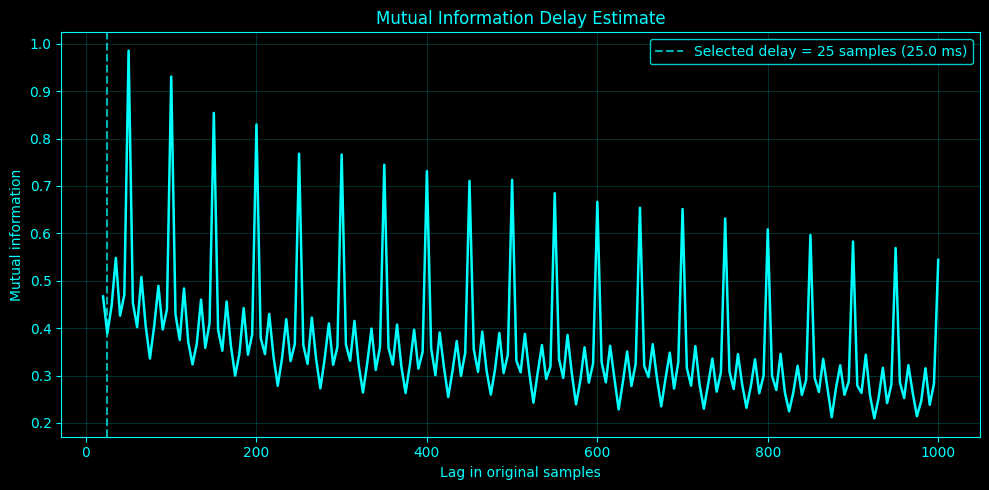

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/pyragas_control/plots/mutual_information_delay_estimate.png


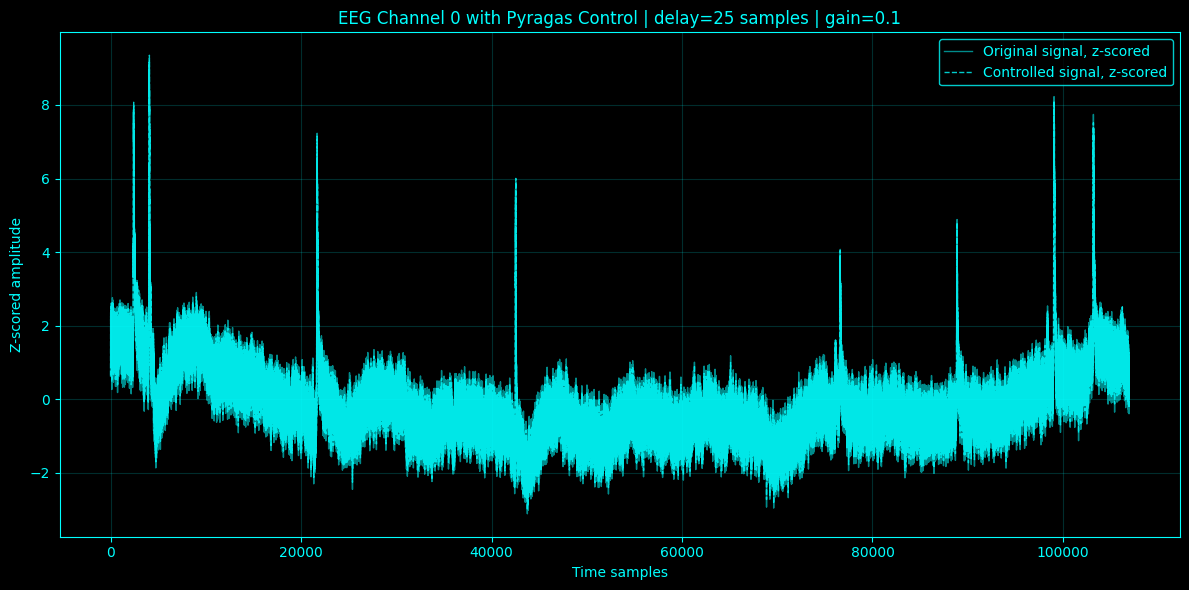

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/pyragas_control/plots/original_vs_controlled_full_zscored.png


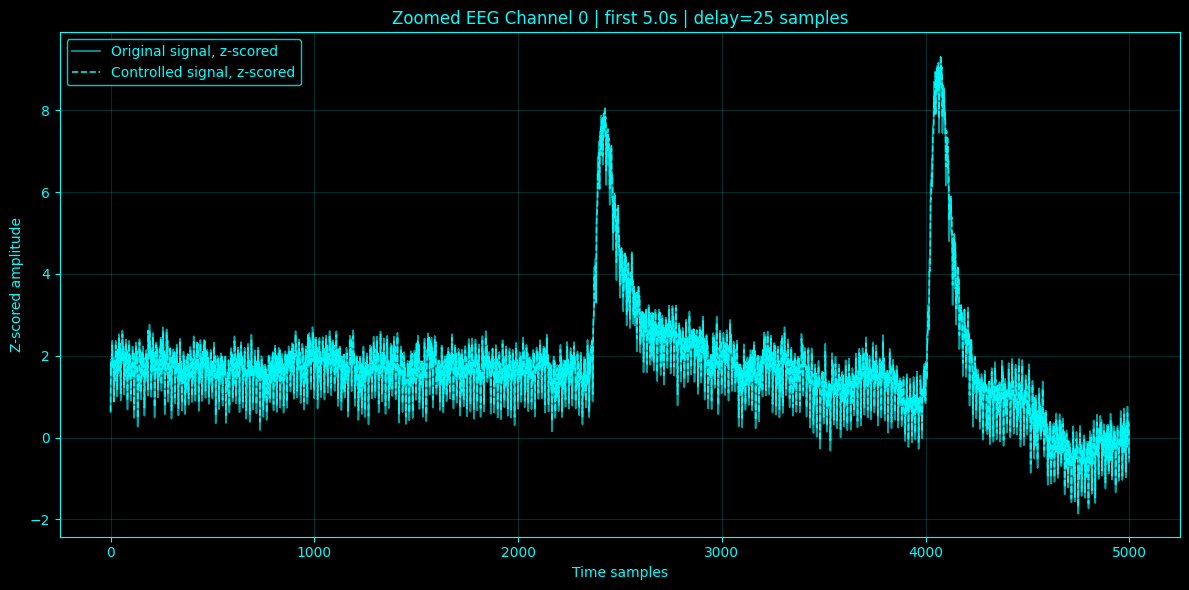

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/pyragas_control/plots/original_vs_controlled_zoom_zscored.png


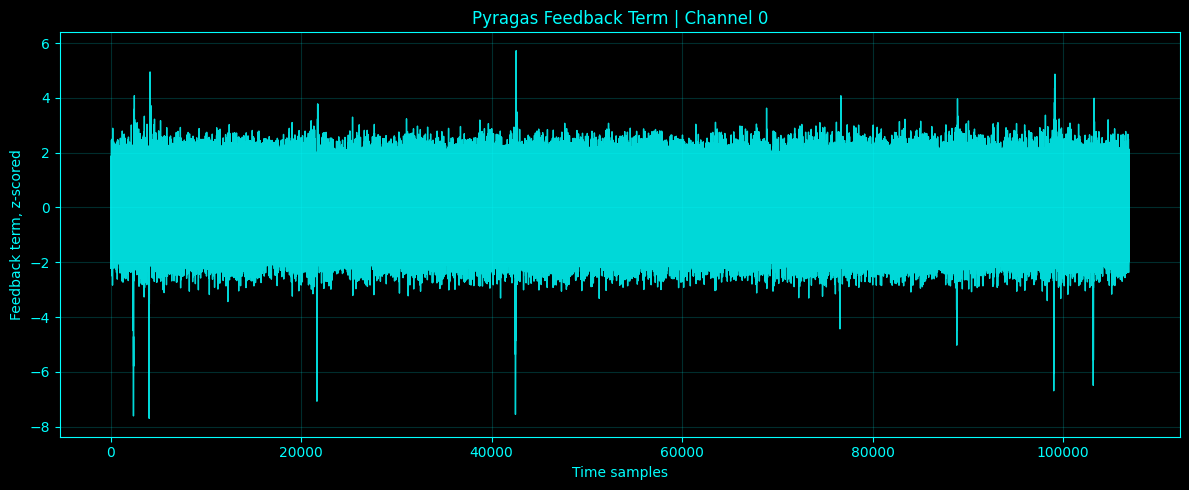

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/pyragas_control/plots/pyragas_feedback_term_zscored.png


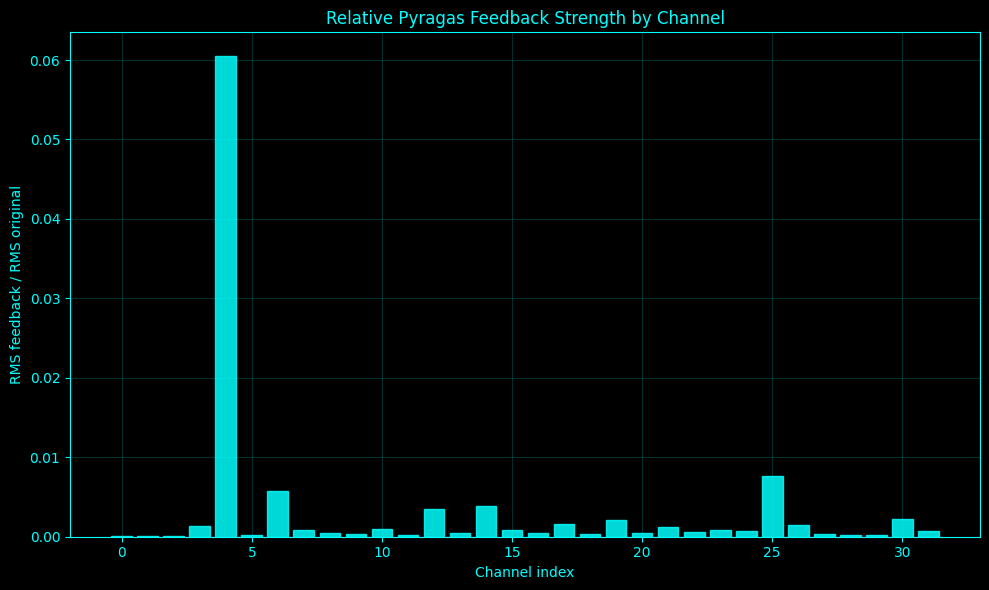

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/pyragas_control/plots/relative_feedback_strength_by_channel.png
All done.


In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

results_dir = os.path.join(base_dir, "results", "pyragas_control")
plots_dir = os.path.join(results_dir, "plots")
os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000

start_time, end_time = 814.571, 921.515
start_index = int(start_time * sampling_rate)
end_index = int(end_time * sampling_rate)

# Channel to estimate delay from and plot
channel_index = 0

# Pyragas control gain
gain = 0.1

# Mutual-information delay search
# Avoid tiny lags like 1-2 samples because those mostly reflect autocorrelation/noise.
min_lag_ms = 20       # ignore lags below 20 ms
max_lag_ms = 1000     # search up to 1000 ms

# Speed control for mutual information.
# The code uses integer decimation so lag units remain correct.
max_mi_samples = 25000

# Heartbeat
HEARTBEAT_EVERY_SEC = 10

# Plot zoom
zoom_seconds = 5.0

# -------------------------------------------------------
# STYLE: black background + cyan
# -------------------------------------------------------
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)

    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

    ax.grid(True, color=ACCENT, alpha=0.18)


def save_show_close(fig, out_path, dpi=220):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)


# -------------------------------------------------------
# HEARTBEAT HELPER
# -------------------------------------------------------
last_heartbeat = time.time()

def heartbeat(message, every_sec=10, force=False):
    global last_heartbeat
    now = time.time()

    if force or (now - last_heartbeat >= every_sec):
        print(message, flush=True)
        last_heartbeat = now


# -------------------------------------------------------
# BASIC HELPERS
# -------------------------------------------------------
def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmean(x)) / (np.nanstd(x) + 1e-12)


def demean(x):
    x = np.asarray(x, dtype=float)
    return x - np.nanmean(x)


def safe_decimate_for_mi(signal, fs, max_samples=25000):
    """
    Decimate by an integer factor so lag timing remains interpretable.

    Returns
    -------
    signal_work : ndarray
    fs_work : float
    decimation_factor : int
    """
    signal = np.asarray(signal, dtype=float).reshape(-1)

    if max_samples is None or len(signal) <= max_samples:
        return signal, float(fs), 1

    decimation_factor = int(np.ceil(len(signal) / max_samples))
    signal_work = signal[::decimation_factor]
    fs_work = fs / decimation_factor

    return signal_work, fs_work, decimation_factor


# -------------------------------------------------------
# LOAD EEG DATA
# -------------------------------------------------------
heartbeat("Loading EEG data...", force=True)

EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = np.asarray(EEG_data, dtype=float)

print("Loaded EEG from:", eeg_path, flush=True)
print("Original EEG shape:", EEG_data.shape, flush=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG data, got shape {EEG_data.shape}")

# Expected shape: time x channels.
# If shape is channels x time, transpose it.
if EEG_data.shape[0] == 32 and EEG_data.shape[1] != 32:
    EEG_data = EEG_data.T

if end_index > EEG_data.shape[0]:
    raise ValueError(
        f"Requested end_index={end_index}, but EEG only has "
        f"{EEG_data.shape[0]} samples."
    )

EEG_segment = EEG_data[start_index:end_index, :]

print("Final EEG shape:", EEG_data.shape, flush=True)
print("Segment shape:", EEG_segment.shape, flush=True)


# -------------------------------------------------------
# MUTUAL INFORMATION DELAY ESTIMATION
# -------------------------------------------------------
def estimate_delay_mutual_information(
    signal,
    sampling_rate,
    min_lag_ms=20,
    max_lag_ms=1000,
    max_samples=25000,
):
    """
    Estimate delay using mutual information.

    Fixes:
    - ignores tiny lags below min_lag_ms
    - uses integer decimation so lag timing remains valid
    - returns lag in original sample units
    """
    heartbeat("Preparing signal for mutual information delay estimate...", force=True)

    signal = np.asarray(signal, dtype=float).reshape(-1)
    signal = signal[np.isfinite(signal)]

    # Demean/z-score for MI stability
    signal = zscore(signal)

    signal_work, fs_work, decimation_factor = safe_decimate_for_mi(
        signal,
        sampling_rate,
        max_samples=max_samples
    )

    min_lag_work = max(1, int(round((min_lag_ms / 1000.0) * fs_work)))
    max_lag_work = max(min_lag_work + 1, int(round((max_lag_ms / 1000.0) * fs_work)))
    max_lag_work = min(max_lag_work, len(signal_work) // 3)

    if max_lag_work <= min_lag_work:
        raise ValueError(
            f"Signal too short after decimation for lag range. "
            f"min_lag_work={min_lag_work}, max_lag_work={max_lag_work}"
        )

    lags_work = np.arange(min_lag_work, max_lag_work + 1)
    mi_values = np.zeros(len(lags_work), dtype=float)

    print(
        f"MI working samples: {len(signal_work)} | "
        f"decimation factor: {decimation_factor} | "
        f"effective fs: {fs_work:.3f} Hz",
        flush=True
    )

    print(
        f"Searching lags from {min_lag_ms} ms to {max_lag_ms} ms "
        f"({len(lags_work)} lag values)",
        flush=True
    )

    heartbeat("Starting mutual information loop...", force=True)
    start = time.time()

    for idx, lag in enumerate(lags_work):
        heartbeat(
            f"Still running MI... {idx + 1}/{len(lags_work)} "
            f"| lag={lag} work samples "
            f"| elapsed={time.time() - start:.1f}s",
            every_sec=HEARTBEAT_EVERY_SEC
        )

        x = signal_work[:-lag].reshape(-1, 1)
        y = signal_work[lag:]

        mi_values[idx] = mutual_info_regression(
            x,
            y,
            discrete_features=False,
            random_state=42
        )[0]

    heartbeat("Finished mutual information loop.", force=True)

    # First local minimum after min_lag
    local_minima = np.where(
        (mi_values[1:-1] < mi_values[:-2]) &
        (mi_values[1:-1] < mi_values[2:])
    )[0] + 1

    if len(local_minima) > 0:
        best_idx = int(local_minima[0])
        selection_method = "first local minimum after minimum lag"
    else:
        best_idx = int(np.argmin(mi_values))
        selection_method = "global minimum in allowed lag range"

    delay_work_samples = int(lags_work[best_idx])
    delay_seconds = delay_work_samples / fs_work
    delay_samples_original = int(round(delay_seconds * sampling_rate))

    lags_seconds = lags_work / fs_work
    lags_original_samples = np.round(lags_seconds * sampling_rate).astype(int)

    print("Delay selection method:", selection_method, flush=True)

    return {
        "delay_seconds": float(delay_seconds),
        "delay_samples": int(delay_samples_original),
        "lags_seconds": lags_seconds,
        "lags_original_samples": lags_original_samples,
        "mi_values": mi_values,
        "selection_method": selection_method,
        "decimation_factor": int(decimation_factor),
        "fs_work": float(fs_work),
    }


# -------------------------------------------------------
# PYRAGAS CONTROL
# -------------------------------------------------------
def apply_pyragas_control(signal, delay_samples, gain=0.1, sign="stabilizing"):
    """
    Apply simple Pyragas-style delayed feedback.

    Stabilizing version:
        controlled = signal + gain * (delayed - signal)

    This is usually more sensible than adding signal - delayed, which can
    amplify high-frequency differences.
    """
    signal = np.asarray(signal, dtype=float).reshape(-1)

    if delay_samples <= 0:
        raise ValueError("delay_samples must be positive.")

    if delay_samples >= len(signal):
        raise ValueError("delay_samples must be smaller than signal length.")

    delayed_signal = np.empty_like(signal)
    delayed_signal[:delay_samples] = signal[0]
    delayed_signal[delay_samples:] = signal[:-delay_samples]

    if sign == "stabilizing":
        feedback = gain * (delayed_signal - signal)
    elif sign == "destabilizing":
        feedback = gain * (signal - delayed_signal)
    else:
        raise ValueError("sign must be 'stabilizing' or 'destabilizing'.")

    controlled_signal = signal + feedback

    return controlled_signal, feedback, delayed_signal


# -------------------------------------------------------
# ESTIMATE DELAY
# -------------------------------------------------------
heartbeat("Estimating delay from selected EEG channel...", force=True)

delay_result = estimate_delay_mutual_information(
    EEG_segment[:, channel_index],
    sampling_rate=sampling_rate,
    min_lag_ms=min_lag_ms,
    max_lag_ms=max_lag_ms,
    max_samples=max_mi_samples
)

delay_seconds = delay_result["delay_seconds"]
delay_samples = delay_result["delay_samples"]
lags_seconds = delay_result["lags_seconds"]
lags_original_samples = delay_result["lags_original_samples"]
mi_values = delay_result["mi_values"]

print(f"Estimated delay: {delay_seconds:.6f} seconds", flush=True)
print(f"Estimated delay: {delay_samples} original samples", flush=True)


# -------------------------------------------------------
# APPLY PYRAGAS CONTROL TO EACH CHANNEL
# -------------------------------------------------------
heartbeat("Applying Pyragas control to all channels...", force=True)

controlled_EEG_data = np.zeros_like(EEG_segment)
feedback_EEG_data = np.zeros_like(EEG_segment)

control_start = time.time()

for ch in range(EEG_segment.shape[1]):
    heartbeat(
        f"Applying Pyragas control... channel {ch + 1}/{EEG_segment.shape[1]} "
        f"| elapsed={time.time() - control_start:.1f}s",
        every_sec=5
    )

    controlled, feedback, delayed = apply_pyragas_control(
        EEG_segment[:, ch],
        delay_samples=delay_samples,
        gain=gain,
        sign="stabilizing"
    )

    controlled_EEG_data[:, ch] = controlled
    feedback_EEG_data[:, ch] = feedback

heartbeat("Finished applying Pyragas control.", force=True)

print("Controlled EEG shape:", controlled_EEG_data.shape, flush=True)


# -------------------------------------------------------
# SAVE NUMERICAL OUTPUTS
# -------------------------------------------------------
out_npz = os.path.join(results_dir, "pyragas_control_results.npz")

np.savez_compressed(
    out_npz,
    EEG_segment=EEG_segment,
    controlled_EEG_data=controlled_EEG_data,
    feedback_EEG_data=feedback_EEG_data,
    delay_seconds=delay_seconds,
    delay_samples=delay_samples,
    gain=gain,
    channel_index=channel_index,
    lags_seconds=lags_seconds,
    lags_original_samples=lags_original_samples,
    mi_values=mi_values,
    start_time=start_time,
    end_time=end_time,
    sampling_rate=sampling_rate,
)

print("Saved NPZ:", out_npz, flush=True)


# -------------------------------------------------------
# PLOT 1: MUTUAL INFORMATION VS LAG
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    lags_original_samples,
    mi_values,
    color=ACCENT,
    linewidth=1.8
)

ax.axvline(
    delay_samples,
    color=ACCENT,
    linestyle="--",
    alpha=0.7,
    label=f"Selected delay = {delay_samples} samples ({1000 * delay_seconds:.1f} ms)"
)

ax.set_title("Mutual Information Delay Estimate")
ax.set_xlabel("Lag in original samples")
ax.set_ylabel("Mutual information")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, "mutual_information_delay_estimate.png")
save_show_close(fig, plot_path)


# -------------------------------------------------------
# PLOT 2: ORIGINAL VS CONTROLLED, FULL SEGMENT, Z-SCORED
# -------------------------------------------------------
orig = zscore(EEG_segment[:, channel_index])
ctrl = zscore(controlled_EEG_data[:, channel_index])
feedback = feedback_EEG_data[:, channel_index]

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
style_ax(ax)

ax.plot(
    orig,
    alpha=0.55,
    color=ACCENT,
    linewidth=1.0,
    label="Original signal, z-scored"
)

ax.plot(
    ctrl,
    alpha=0.80,
    color=ACCENT,
    linewidth=1.0,
    linestyle="--",
    label="Controlled signal, z-scored"
)

ax.set_title(
    f"EEG Channel {channel_index} with Pyragas Control | "
    f"delay={delay_samples} samples | gain={gain}"
)
ax.set_xlabel("Time samples")
ax.set_ylabel("Z-scored amplitude")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, "original_vs_controlled_full_zscored.png")
save_show_close(fig, plot_path)


# -------------------------------------------------------
# PLOT 3: ZOOMED ORIGINAL VS CONTROLLED
# -------------------------------------------------------
zoom_n = int(zoom_seconds * sampling_rate)
zoom_n = min(zoom_n, len(orig))

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
style_ax(ax)

ax.plot(
    orig[:zoom_n],
    alpha=0.65,
    color=ACCENT,
    linewidth=1.2,
    label="Original signal, z-scored"
)

ax.plot(
    ctrl[:zoom_n],
    alpha=0.90,
    color=ACCENT,
    linewidth=1.2,
    linestyle="--",
    label="Controlled signal, z-scored"
)

ax.set_title(
    f"Zoomed EEG Channel {channel_index} | first {zoom_seconds:.1f}s | "
    f"delay={delay_samples} samples"
)
ax.set_xlabel("Time samples")
ax.set_ylabel("Z-scored amplitude")

leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot_path = os.path.join(plots_dir, "original_vs_controlled_zoom_zscored.png")
save_show_close(fig, plot_path)


# -------------------------------------------------------
# PLOT 4: FEEDBACK TERM
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    zscore(feedback),
    color=ACCENT,
    linewidth=1.0,
    alpha=0.85
)

ax.set_title(f"Pyragas Feedback Term | Channel {channel_index}")
ax.set_xlabel("Time samples")
ax.set_ylabel("Feedback term, z-scored")

plot_path = os.path.join(plots_dir, "pyragas_feedback_term_zscored.png")
save_show_close(fig, plot_path)


# -------------------------------------------------------
# PLOT 5: CONTROL EFFECT MAGNITUDE BY CHANNEL
# -------------------------------------------------------
rms_original = np.sqrt(np.mean(EEG_segment ** 2, axis=0))
rms_feedback = np.sqrt(np.mean(feedback_EEG_data ** 2, axis=0))
relative_feedback = rms_feedback / (rms_original + 1e-12)

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
style_ax(ax)

ax.bar(
    np.arange(EEG_segment.shape[1]),
    relative_feedback,
    color=ACCENT,
    edgecolor=ACCENT,
    alpha=0.85
)

ax.set_title("Relative Pyragas Feedback Strength by Channel")
ax.set_xlabel("Channel index")
ax.set_ylabel("RMS feedback / RMS original")

plot_path = os.path.join(plots_dir, "relative_feedback_strength_by_channel.png")
save_show_close(fig, plot_path)


heartbeat("All done.", force=True)

### Kakutani's theorem

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis involves visualizing EEG data, generating 3D embeddings, and constructing recurrence plots to examine the dynamic behavior of the signals. Kakutani's theorem is employed to ensure the fixed points identified are accurately represented. We will detail the reasoning, methods, and formulas used in this process.</p>
        <h2>Data Preparation and Visualization</h2>
        <p>EEG data is segmented to exclude periods of stimulation, ensuring the focus is on natural brain activity. The data is then visualized with adjusted offsets for clarity.</p>
        <p><strong>Formulas:</strong></p>
        \[
        \text{Segment indices} = [\text{start\_index}, \text{end\_index}]
        \]
        where \(\text{start\_index} = \text{start\_time} \times \text{sampling\_rate}\) and \(\text{end\_index} = \text{end\_time} \times \text{sampling\_rate}\).</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>3D Embedding Visualization</h2>
        <p>We visualize the 3D embeddings of the EEG data, which reveal the structure of the signals in a higher-dimensional space. This helps in understanding the complex, high-dimensional relationships in the data.</p>
        <p><strong>Steps:</strong></p>
        <ul>
            <li>Load the 3D embedding data for each EEG channel.</li>
            <li>Plot the 3D embeddings to visualize the structure.</li>
        </ul>
        <h2>Recurrence Plots</h2>
        <p>Recurrence plots are used to visualize times at which the system's state recurs. This technique highlights patterns and structures within the EEG data.</p>
        <p><strong>Formula:</strong></p>
        \[
        R_{ij} = \Theta(\epsilon - \| \mathbf{x}_i - \mathbf{x}_j \|)
        \]
        where \(R_{ij}\) is the recurrence matrix, \(\Theta\) is the Heaviside step function, \(\epsilon\) is a threshold, and \(\mathbf{x}_i\) and \(\mathbf{x}_j\) are state vectors.</p>
        <h2>Fixed Point Analysis and Kakutani's Theorem</h2>
        <p>We analyze fixed points in the EEG data, which correspond to stable states in the signal. Kakutani's theorem ensures that the fixed points identified are valid in the context of the embeddings and recurrence plots.</p>
        <p><strong>Kakutani's Theorem:</strong> This theorem states that in a convex and compact space, a continuous mapping has a fixed point. This is crucial in validating the fixed points found in the EEG data.</p>
        <p><strong>Steps:</strong></p>
        <ul>
            <li>Extract and plot the first dimension of the 3D embedding data.</li>
            <li>Identify and analyze fixed points in the time series.</li>
            <li>Apply Kakutani's theorem to confirm the fixed points.</li>
        </ul>
        <h2>Visualization</h2>
        <p>Visualizing the EEG data, 3D embeddings, and recurrence plots provides a comprehensive view of the dynamic activity within the signals.</p>
        <h2>Conclusion</h2>
        <p>This methodology provides a detailed analysis of EEG data by examining 3D embeddings, recurrence plots, and fixed points, with the assurance of Kakutani's theorem, offering insights into the complex dynamics of the signals.</p>
    </div>
</div>
